# Section 4: NK-cell contact histories

This notebook is plotting-only. Run `section_4/scripts/run_analysis_1_inference.py` to fit the Section 4 SMC models and save posterior/evidence files, then use this notebook to inspect empirical histories, cached evidence, and posterior plots.


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Sequence

os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(os.environ.get("TMPDIR", "/tmp")) / "orca_matplotlib"),
)

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import MaxNLocator, MultipleLocator, NullLocator
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


try:
    import scienceplots  # noqa: F401

    plt.style.use("science")
except Exception:
    pass


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "section_4" / "src" / "inference.py").exists() and (
            candidate / "data"
        ).exists():
            return candidate

    raise RuntimeError("Could not find project root containing section_4/src/inference.py and data/.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"
RESULT_ROOT = PROJECT_ROOT / "section_4" / "results" / "analysis_2"
FIGURE_ROOT = PROJECT_ROOT / "section_4" / "figures" / "analysis_2"

CONDITIONS = {
    "no_treatment": {
        "label": "No treatment",
        "path": DATA_ROOT / "NT-No Treatment.csv",
    },
    "rituximab": {
        "label": "Rituximab",
        "path": DATA_ROOT / "RTX-Rituximab.csv",
    },
    "bispecific_ab": {
        "label": "Bispecific Ab",
        "path": DATA_ROOT / "Bispecific-Bispecific.csv",
    },
}

CONDITION_ORDER = ["No treatment", "Rituximab", "Bispecific Ab"]
MODEL_ORDER = [
    "homogeneous_history_independent",
    "homogeneous_history_dependent",
    "heterogeneous_history_independent",
    "heterogeneous_history_dependent",
]

MODEL_DISPLAY = {
    "homogeneous_history_independent": "homogeneous\nhistory-independent",
    "homogeneous_history_dependent": "homogeneous\nhistory-dependent",
    "heterogeneous_history_independent": "heterogeneous\nhistory-independent",
    "heterogeneous_history_dependent": "heterogeneous\nhistory-dependent",
}

MODEL_SHORT_DISPLAY = {
    "homogeneous_history_independent": "Hom-HI",
    "homogeneous_history_dependent": "Hom-HD",
    "heterogeneous_history_independent": "Het-HI",
    "heterogeneous_history_dependent": "Het-HD",
}

MODEL_COLORS = {
    "homogeneous_history_independent": "#b1ceb5",
    "homogeneous_history_dependent": "#7db2ac",
    "heterogeneous_history_independent": "#5494a1",
    "heterogeneous_history_dependent": "#566f94",
}

CONDITION_COLORS = {
    "No treatment": "#85a993",
    "Rituximab": "#f7c435",
    "Bispecific Ab": "#c75a1b",
}

PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "mu_eta": r"$\mu_\eta$",
    "mu_p0": r"$\mu_{p0}$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_f$",
    "beta_y": r"$\beta_s$",
}

FULL_MODEL = "heterogeneous_history_dependent"

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)
print("FIGURE_ROOT:", FIGURE_ROOT)


Matplotlib is building the font cache; this may take a moment.


PROJECT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca
DATA_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/data
RESULT_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_4/results/analysis_2
FIGURE_ROOT: /Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2


In [3]:
def slug(text: str) -> str:
    return str(text).lower().replace(" ", "_").replace("-", "_")


def _normalise_history_row(row: pd.Series) -> tuple[int, ...]:
    values = []

    for value in row.dropna().to_numpy():
        numeric = float(value)

        if not numeric.is_integer():
            raise ValueError("Each contact-history value must be 0 or 1.")

        z = int(numeric)

        if z not in (0, 1):
            raise ValueError("Each contact-history value must be 0 or 1.")

        values.append(z)

    return tuple(values)


def load_history_table(path: Path, condition: str, label: str) -> pd.DataFrame:
    raw = pd.read_csv(path)
    history = raw.drop(columns="Cell", errors="ignore").apply(pd.to_numeric, errors="coerce")
    history = history.loc[:, history.notna().any()]
    histories = [_normalise_history_row(row) for _, row in history.iterrows()]
    cell = raw["Cell"] if "Cell" in raw else np.arange(len(raw))

    return pd.DataFrame(
        {
            "Cell": cell,
            "condition": condition,
            "condition_label": label,
            "history": histories,
            "history_string": ["".join(map(str, h)) for h in histories],
            "contact_count": [len(h) for h in histories],
            "kill_count": [sum(h) for h in histories],
        }
    )


def load_all_conditions(conditions: dict = CONDITIONS) -> pd.DataFrame:
    return pd.concat(
        [
            load_history_table(
                path=Path(meta["path"]),
                condition=condition,
                label=str(meta["label"]),
            )
            for condition, meta in conditions.items()
        ],
        ignore_index=True,
    )


def save_cell_histories(cells: pd.DataFrame, result_root: Path = RESULT_ROOT) -> Path:
    result_root.mkdir(parents=True, exist_ok=True)
    out = result_root / "cell_histories.csv"
    cells.drop(columns="history").to_csv(out, index=False)
    return out


def counts_by_condition(cells: pd.DataFrame) -> dict[str, dict[str, np.ndarray]]:
    return {
        label: {
            "contact_counts": group["contact_count"].to_numpy(dtype=int),
            "kill_counts": group["kill_count"].to_numpy(dtype=int),
        }
        for label, group in cells.groupby("condition_label", sort=False)
    }


def plot_count_distribution(
    datasets: Sequence[np.ndarray],
    labels: Sequence[str],
    xlabel: str,
    colors: dict[str, str],
    *,
    save_dir: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path:
    max_count = max(int(np.max(data)) for data in datasets if len(data))
    bins = np.arange(-0.5, max_count + 1.5, 1)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=350)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    for data, label in zip(datasets, labels):
        color = colors[label]
        legend_label = f"{label} (n={len(data)})"
        ax.hist(data, bins=bins, density=True, histtype="stepfilled", alpha=0.25, color=color)
        ax.hist(data, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=legend_label)

    ax.set_xlim(-0.8, max_count + 0.8)
    ax.set_xticks(np.arange(0, max_count + 1, 1))
    ax.tick_params(axis="both", labelsize=22)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_xlabel(xlabel, fontsize=28)
    ax.set_ylabel("Density", fontsize=28)
    ax.legend(frameon=True, fontsize=20)
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"{xlabel.replace(' ', '_').lower()}.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def plot_empirical_count_distributions(
    cells: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> list[Path]:
    grouped = counts_by_condition(cells)
    contact_datasets = [grouped[label]["contact_counts"] for label in CONDITION_ORDER]
    kill_datasets = [grouped[label]["kill_counts"] for label in CONDITION_ORDER]

    return [
        plot_count_distribution(
            contact_datasets,
            CONDITION_ORDER,
            "Contacts per NK cell",
            CONDITION_COLORS,
            save_dir=figure_root,
            show=show,
        ),
        plot_count_distribution(
            kill_datasets,
            CONDITION_ORDER,
            "Kills per NK cell",
            CONDITION_COLORS,
            save_dir=figure_root,
            show=show,
        ),
    ]


def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": int(z),
                }
            )

            if int(z) == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def plot_lethal_probability_by_contact_index(
    cells: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path | None:
    events = event_history_frame(cells)

    if events.empty:
        return None

    plot_df = (
        events.groupby(["condition_label", "event_index"], as_index=False)
        .agg(lethal_probability=("z", "mean"), n=("z", "size"))
        .sort_values(["condition_label", "event_index"])
    )

    fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=350)

    for condition in CONDITION_ORDER:
        sub = plot_df[plot_df["condition_label"] == condition]

        if sub.empty:
            continue

        ax.plot(sub["event_index"], sub["lethal_probability"], color=CONDITION_COLORS[condition], linewidth=2.2, label=condition)
        ax.scatter(
            sub["event_index"],
            sub["lethal_probability"],
            s=np.clip(sub["n"].to_numpy(dtype=float), 20, 180),
            color=CONDITION_COLORS[condition],
            edgecolor="black",
            linewidth=0.7,
            alpha=0.85,
        )

    ax.set_xlabel("Contact index", fontsize=26)
    ax.set_ylabel("Lethal-contact probability", fontsize=26)
    ax.tick_params(axis="both", labelsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylim(-0.04, 1.04)
    ax.legend(frameon=True, fontsize=18)
    ax.grid(alpha=0.2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    fig.tight_layout()
    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "lethal_probability_by_contact_index.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def history_to_path(history):
    history = np.asarray(history, dtype=int)
    path = np.zeros((history.size + 1, 2), dtype=float)

    for i, z in enumerate(history, start=1):
        path[i] = path[i - 1]

        if z == 1:
            path[i, 1] += 1
        else:
            path[i, 0] += 1

    return path


def histories_from_df(df):
    if "history" not in df:
        raise ValueError("df must contain a 'history' column.")

    return [tuple(h) for h in df["history"]]


def final_counts(data):
    if isinstance(data, pd.DataFrame):
        if "history" in data:
            histories = histories_from_df(data)
            cell_ids = data["Cell"].to_numpy() if "Cell" in data else np.arange(len(data))
        elif {"n_nonlethal", "n_lethal", "n_contact"}.issubset(data.columns):
            out = data.copy()
            if "cell_id" not in out:
                out["cell_id"] = np.arange(len(out))
            if "history" not in out:
                out["history"] = [tuple()] * len(out)
            return out
        else:
            raise ValueError("data must contain a 'history' column or final-count columns.")
    else:
        histories = [tuple(h) for h in data]
        cell_ids = np.arange(len(histories))

    rows = []

    for cell_id, history in zip(cell_ids, histories):
        history = np.asarray(history, dtype=int)
        n_lethal = int(history.sum())
        n_nonlethal = int(history.size - n_lethal)
        rows.append(
            {
                "cell_id": cell_id,
                "history": tuple(history),
                "n_nonlethal": n_nonlethal,
                "n_lethal": n_lethal,
                "n_contact": n_nonlethal + n_lethal,
            }
        )

    return pd.DataFrame(rows)


def summarise_histories(data):
    df = final_counts(data)

    return {
        "n_cells": int(len(df)),
        "mean_contacts": float(df["n_contact"].mean()),
        "mean_kills": float(df["n_lethal"].mean()),
        "mean_nonlethal": float(df["n_nonlethal"].mean()),
        "fraction_no_contact": float((df["n_contact"] == 0).mean()),
        "fraction_no_kill": float((df["n_lethal"] == 0).mean()),
    }


def plot_decision_map(
    data,
    *,
    figsize=(6.2, 6.2),
    dpi=300,
    color="#2F80ED",
    alpha=0.35,
    lw=1.2,
    s=14,
    jitter=0.04,
    ax=None,
):
    histories = histories_from_df(data) if isinstance(data, pd.DataFrame) else [tuple(h) for h in data]

    if ax is None:
        _, ax = plt.subplots(figsize=figsize, dpi=dpi)

    n = len(histories)

    for i, history in enumerate(histories):
        path = history_to_path(history)
        shift = (i - n / 2) * jitter / max(n, 1)
        path = path + shift
        ax.plot(path[:, 0], path[:, 1], color=color, alpha=alpha, lw=lw)
        ax.scatter(path[-1, 0], path[-1, 1], s=s, color=color, edgecolor="black", linewidth=0.3, zorder=5)

    ax.set_xlabel("Non lethal contacts")
    ax.set_ylabel("Lethal contacts")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

    return ax


def plot_decision_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> Path:
    fig, axes = plt.subplots(1, len(conditions), figsize=(5.2 * len(conditions), 5.1), dpi=300, sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    max_count = int(cells["contact_count"].max()) if len(cells) else 0

    for ax, condition in zip(axes, conditions):
        sub = cells[cells["condition_label"] == condition]
        plot_decision_map(sub, color=colors.get(condition, "#2F80ED"), alpha=0.32, lw=1.1, s=13, ax=ax)
        ax.set_title(f"{condition} (n={len(sub)})", fontsize=18)
        ax.set_xlim(-0.25, max_count + 0.5)
        ax.set_ylim(-0.25, max_count + 0.5)
        ax.tick_params(axis="both", labelsize=14)

    fig.tight_layout()
    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "decision_trajectories_by_condition.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


def plot_traj_heatmap(
    data,
    *,
    mode="density",
    figsize=(7.2, 6.4),
    dpi=300,
    cmap="coolwarm",
    color="0",
    title=None,
):
    df = final_counts(data)
    x = df["n_nonlethal"].to_numpy(int)
    y = df["n_lethal"].to_numpy(int)
    max_value = int(max(np.max(x, initial=0), np.max(y, initial=0)))
    x_edges = np.arange(-0.5, max_value + 1.5, 1)
    y_edges = np.arange(-0.5, max_value + 1.5, 1)

    if mode == "count":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        hist_kwargs = {"density": False}
        cbar_label = "Count"
    elif mode == "frequency":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        H = H / H.sum() if H.sum() > 0 else H
        weights = np.ones_like(x, dtype=float) / len(x) if len(x) else np.array([], dtype=float)
        hist_kwargs = {"weights": weights, "density": False}
        cbar_label = "Frequency"
    elif mode == "density":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], density=True)
        hist_kwargs = {"density": True}
        cbar_label = "Density"
    else:
        raise ValueError("mode must be 'frequency', 'count', or 'density'.")

    H = H.T
    H_masked = np.ma.masked_where(~np.isfinite(H) | (H == 0), H)
    fig, ax_main = plt.subplots(figsize=figsize, dpi=dpi)
    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size="28%", pad=0.2, sharex=ax_main)
    ax_right = divider.append_axes("right", size="28%", pad=0.2, sharey=ax_main)

    im = ax_main.imshow(
        H_masked,
        origin="lower",
        cmap=cmap,
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        interpolation="nearest",
        aspect="equal",
    )

    cax = inset_axes(
        ax_main,
        width="45%",
        height="4%",
        loc="upper right",
        bbox_to_anchor=(-0.005, -0.02, 1, 1),
        bbox_transform=ax_main.transAxes,
        borderpad=1.2,
    )
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.ax.set_title(cbar_label, fontsize=14, pad=2)
    cbar.ax.tick_params(labelsize=12, length=2, pad=1)

    ax_top.hist(x, bins=x_edges, color="black", histtype="step", **hist_kwargs)
    ax_top.hist(x, bins=x_edges, color=color, alpha=0.35, histtype="stepfilled", **hist_kwargs)
    ax_right.hist(y, bins=y_edges, orientation="horizontal", color="black", histtype="step", **hist_kwargs)
    ax_right.hist(y, bins=y_edges, orientation="horizontal", color=color, alpha=0.35, **hist_kwargs)

    ax_main.set_xlim(-0.5, max_value + 0.5)
    ax_main.set_ylim(-0.5, max_value + 0.5)
    ax_main.set_xlabel("Non lethal contacts per killer cell", fontsize=20)
    ax_main.set_ylabel("Lethal contacts per killer cell", fontsize=20)
    ax_top.set_ylabel(cbar_label, fontsize=20)
    ax_right.set_xlabel(cbar_label, fontsize=20)
    ax_main.xaxis.set_major_locator(MultipleLocator(1))
    ax_main.yaxis.set_major_locator(MultipleLocator(1))

    for ax in [ax_main, ax_top, ax_right]:
        ax.tick_params(axis="both", labelsize=16)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(which="minor", bottom=False, left=False, top=False, right=False)

    for ax in [ax_top, ax_right]:
        ax.grid(True, alpha=0.2)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)

    if title:
        ax_top.set_title(title, fontsize=18)

    stats = {
        "x_mean": float(np.mean(x)) if len(x) else np.nan,
        "y_mean": float(np.mean(y)) if len(y) else np.nan,
    }

    return fig, (ax_main, ax_top, ax_right), stats


def plot_traj_heatmaps_by_condition(
    cells: pd.DataFrame,
    *,
    mode: str = "density",
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> tuple[list[Path], pd.DataFrame]:
    paths = []
    rows = []
    figure_root.mkdir(parents=True, exist_ok=True)

    for condition in conditions:
        sub = cells[cells["condition_label"] == condition]
        fig, _, stats = plot_traj_heatmap(sub, mode=mode, color=colors.get(condition, "0"), title=f"{condition} (n={len(sub)})")
        out_path = figure_root / f"trajectory_heatmap_{slug(condition)}_{mode}.svg"
        fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)
        paths.append(out_path)
        rows.append({"condition": condition, **stats})

        if show:
            plt.show()
        else:
            plt.close(fig)

    return paths, pd.DataFrame(rows)

## Load the data

Each row is one NK cell. The full ordered sequence of 0/1 contact outcomes is retained in `history`.


In [4]:
cells = load_all_conditions()
save_cell_histories(cells)
cells

,Cell,condition,condition_label,history,history_string,contact_count,kill_count
0,0,no_treatment,No treatment,"(0, 0, 0, 0)",0000,4,0
1,1,no_treatment,No treatment,"(0, 0, 0)",000,3,0
2,2,no_treatment,No treatment,"(1,)",1,1,1
3,3,no_treatment,No treatment,"(0, 0)",00,2,0
4,4,no_treatment,No treatment,"(1, 0)",10,2,1
...,...,...,...,...,...,...,...
1637,504,bispecific_ab,Bispecific Ab,"(1, 0)",10,2,1
1638,505,bispecific_ab,Bispecific Ab,"(1, 0)",10,2,1
1639,506,bispecific_ab,Bispecific Ab,(),,0,0
1640,507,bispecific_ab,Bispecific Ab,"(1, 0, 0)",100,3,1


In [5]:
condition_counts = counts_by_condition(cells)
event_records = event_history_frame(cells)
summary_by_condition = pd.DataFrame(
    [
        {"condition": condition, **summarise_histories(group)}
        for condition, group in cells.groupby("condition_label", sort=False)
    ]
)

display(summary_by_condition)
event_records.head()

,condition,n_cells,mean_contacts,mean_kills,mean_nonlethal,fraction_no_contact,fraction_no_kill
0,No treatment,594,2.882155,1.456229,1.425926,0.067340,0.304714
1,Rituximab,539,3.204082,2.070501,1.133581,0.063080,0.187384
2,Bispecific Ab,509,3.180747,1.807466,1.373281,0.033399,0.186640


,condition,condition_label,Cell,event_index,x_before,y_before,z
0,no_treatment,No treatment,0,1,0,0,0
1,no_treatment,No treatment,0,2,1,0,0
2,no_treatment,No treatment,0,3,2,0,0
3,no_treatment,No treatment,0,4,3,0,0
4,no_treatment,No treatment,1,1,0,0,0


## Empirical contact, kill, and history summaries


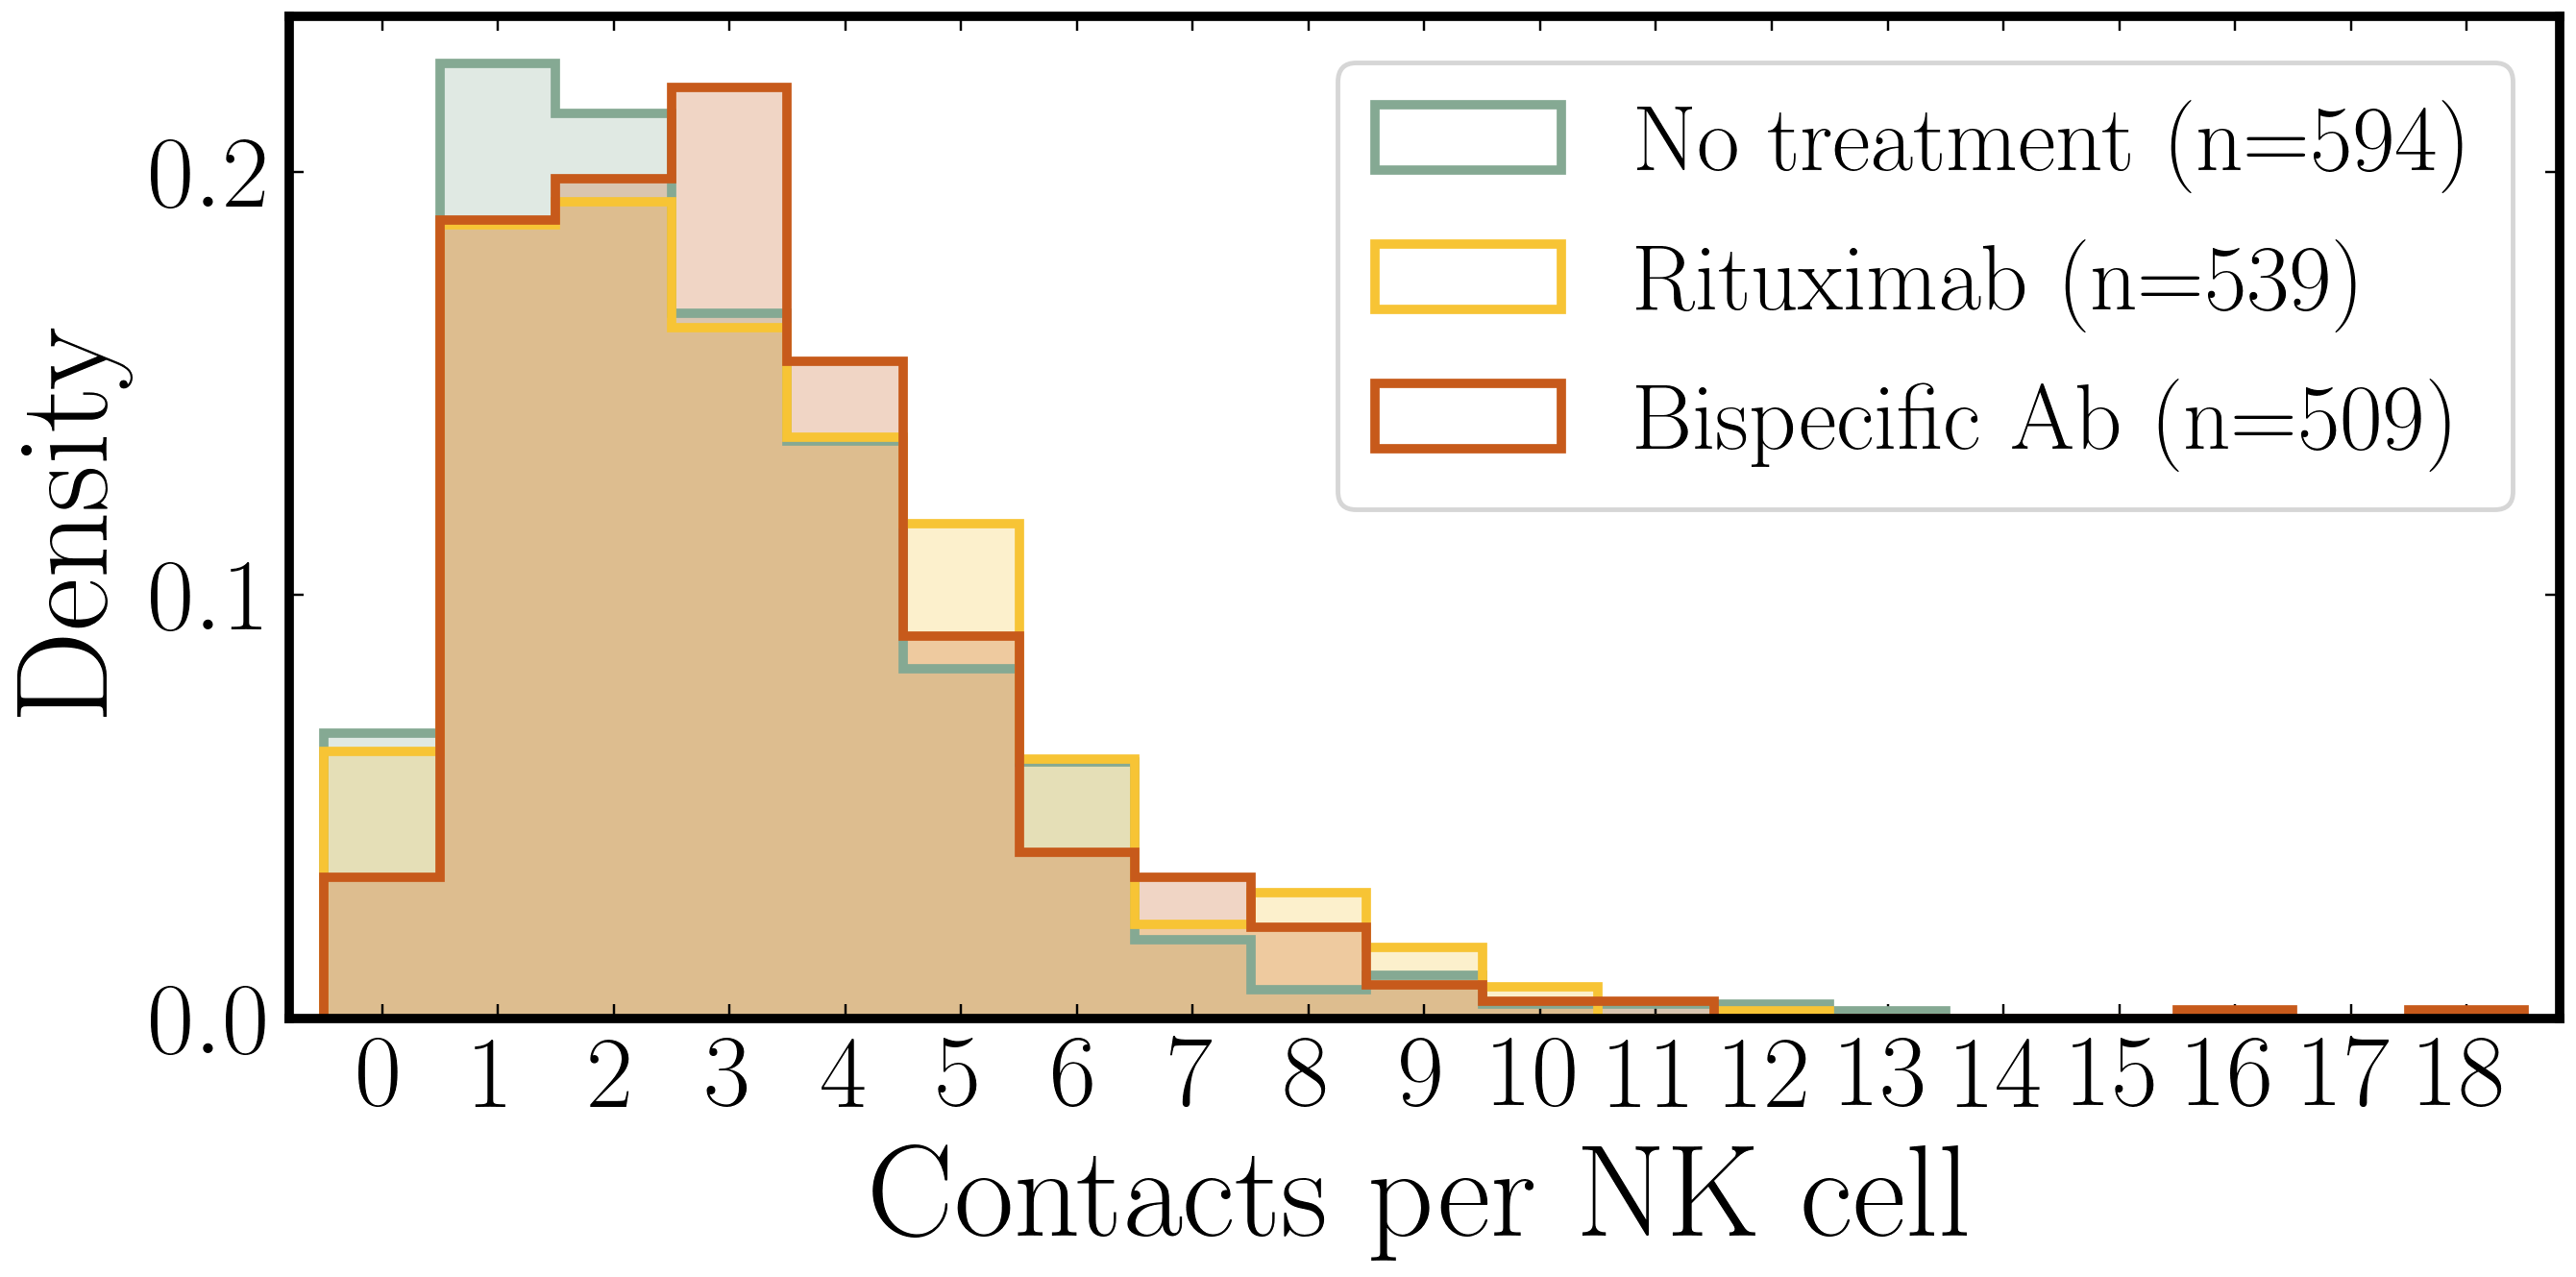

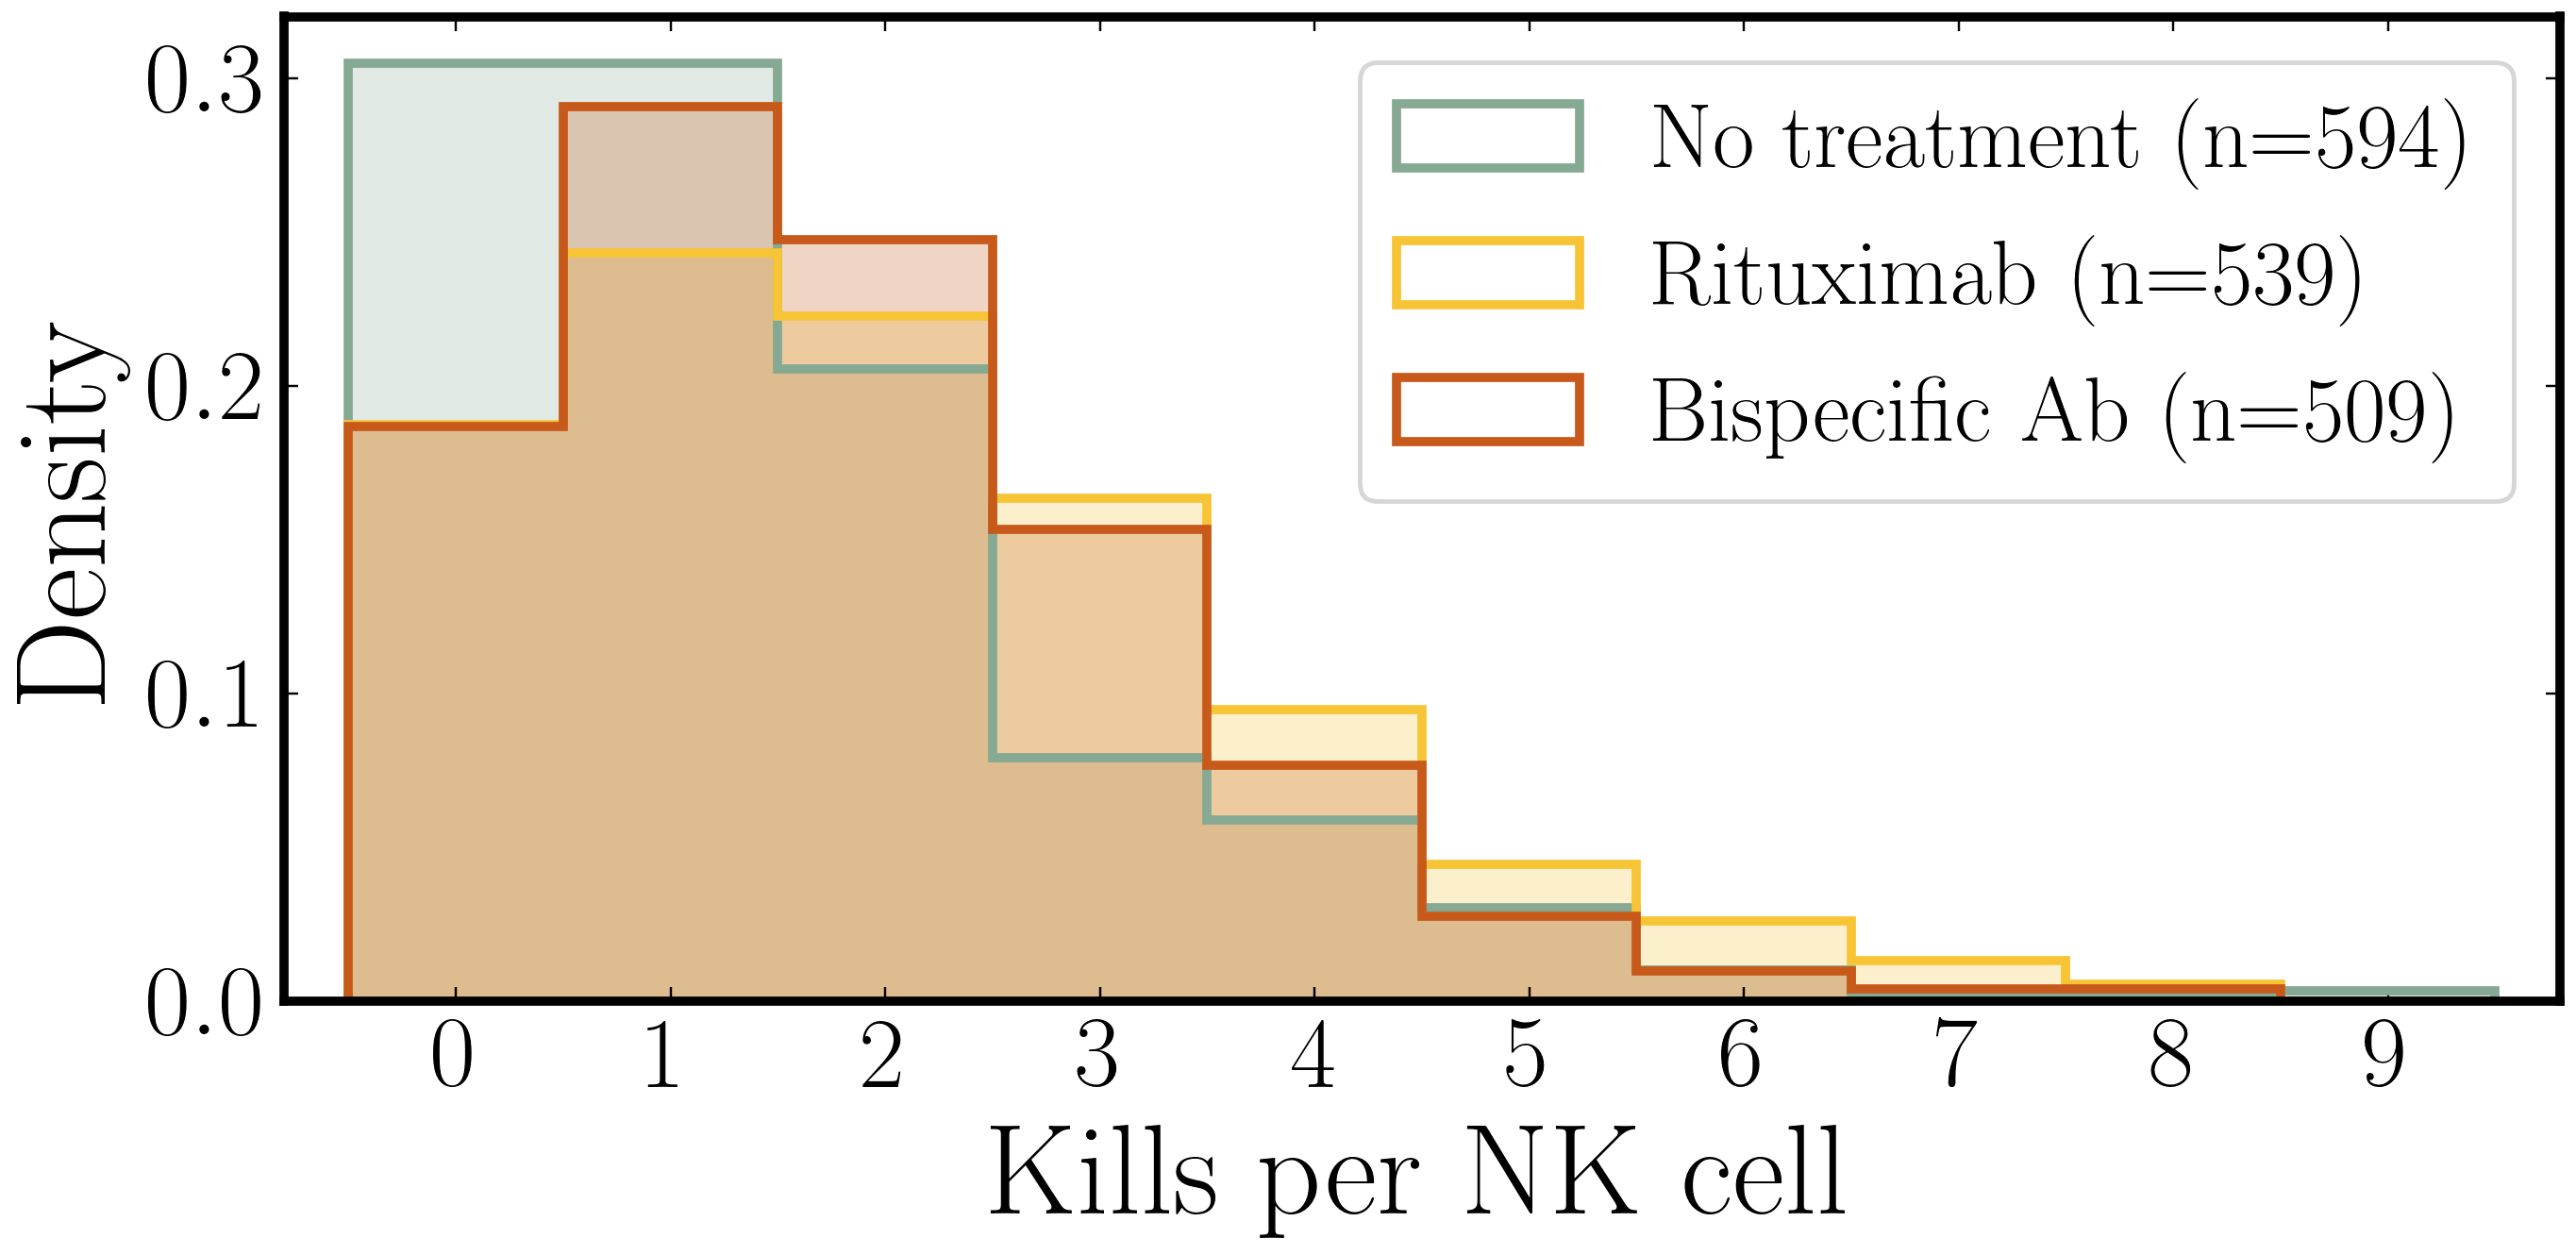

[PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/contacts_per_nk_cell.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/kills_per_nk_cell.svg')]

In [6]:
plot_empirical_count_distributions(cells, show=True)

## Decision trajectories and final-count heatmaps


In [7]:
# trajectory_path = plot_decision_maps_by_condition(cells, show=True)
# heatmap_paths, heatmap_stats = plot_traj_heatmaps_by_condition(cells, mode="density", show=True)

# display(heatmap_stats)
# trajectory_path, heatmap_paths


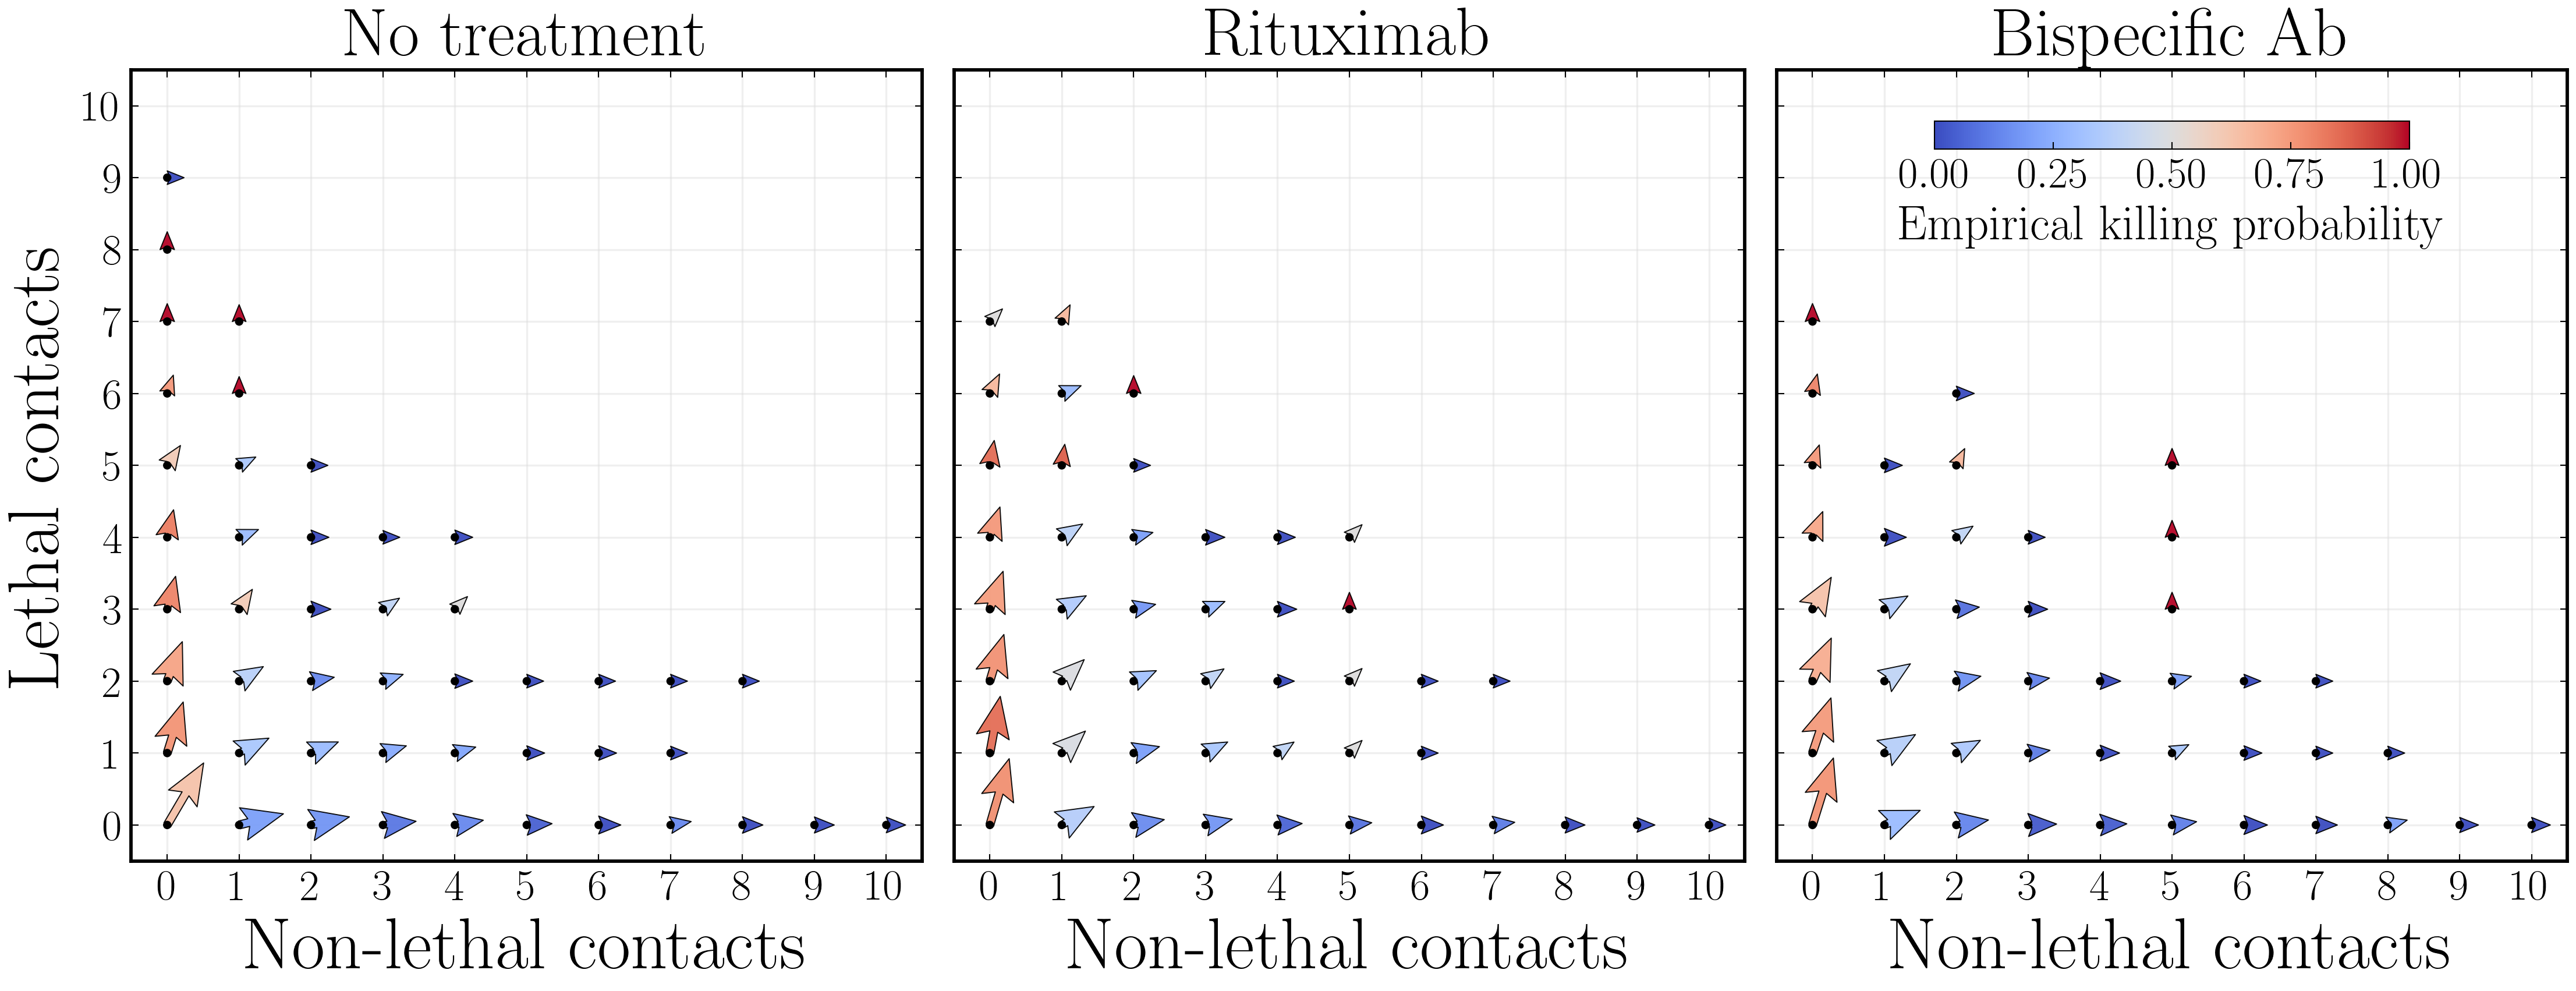

,condition_label,x_before,y_before,n,next_kill_probability,n_condition_events,state_density
0,No treatment,0,0,554,0.629964,1712,0.323598
1,No treatment,0,1,256,0.761719,1712,0.149533
2,No treatment,0,2,130,0.723077,1712,0.075935
3,No treatment,0,3,64,0.796875,1712,0.037383
4,No treatment,0,4,32,0.812500,1712,0.018692
...,...,...,...,...,...,...,...
143,Bispecific Ab,13,0,2,0.000000,1619,0.001235
144,Bispecific Ab,14,0,2,0.000000,1619,0.001235
145,Bispecific Ab,15,0,2,0.000000,1619,0.001235
146,Bispecific Ab,16,0,1,0.000000,1619,0.000618


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/empirical_next_kill_arrow_maps_by_condition.svg')

In [8]:
def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    """Convert cell contact histories into event-level observations."""
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            z = int(z)

            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": z,
                }
            )

            if z == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def empirical_next_kill_state_frame(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    """Calculate density and next-kill probability for every history state."""
    events = event_history_frame(cells)

    output_columns = [
        "condition_label",
        "x_before",
        "y_before",
        "n",
        "n_condition_events",
        "state_density",
        "next_kill_probability",
    ]

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    events = events[
        events["condition_label"].isin(conditions)
    ].copy()

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    state_df = (
        events.groupby(
            ["condition_label", "x_before", "y_before"],
            as_index=False,
            observed=True,
        )
        .agg(
            n=("z", "size"),
            next_kill_probability=("z", "mean"),
        )
    )

    totals = (
        events.groupby(
            "condition_label",
            observed=True,
        )["z"]
        .size()
        .rename("n_condition_events")
        .reset_index()
    )

    state_df = state_df.merge(
        totals,
        on="condition_label",
        how="left",
    )

    state_df["state_density"] = (
        state_df["n"]
        / state_df["n_condition_events"]
    )

    state_df["condition_label"] = pd.Categorical(
        state_df["condition_label"],
        categories=list(conditions),
        ordered=True,
    )

    return (
        state_df.sort_values(
            ["condition_label", "x_before", "y_before"]
        )
        .reset_index(drop=True)
    )


def plot_empirical_next_kill_arrow_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",

    # Arrow-length controls
    min_arrow_length: float = 0.2,
    max_arrow_length: float = 0.9,
    density_power: float = 0.5,

    # Arrow-thickness controls
    arrow_width: float = 0.010,
    head_width: float = 4.2,
    head_length: float = 5.2,

    # Plot controls
    min_events: int = 1,
    axis_max: float | None = 10,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    """
    Plot empirical next-event behaviour at each history state.

    Direction:
        right = next contact is likely non-lethal
        up    = next contact is likely lethal

    Length:
        empirical state density

    Colour:
        empirical probability that the next contact is lethal

    density_power:
        1.0 = linear density scaling
        <1  = makes low-density arrows more visible
        >1  = emphasizes high-density states
    """
    if min_arrow_length < 0:
        raise ValueError(
            "min_arrow_length must be non-negative."
        )

    if max_arrow_length <= min_arrow_length:
        raise ValueError(
            "max_arrow_length must be greater than "
            "min_arrow_length."
        )

    if density_power <= 0:
        raise ValueError(
            "density_power must be greater than zero."
        )

    if arrow_width <= 0:
        raise ValueError(
            "arrow_width must be greater than zero."
        )

    if min_events < 1:
        raise ValueError(
            "min_events must be at least 1."
        )

    state_df = empirical_next_kill_state_frame(
        cells,
        conditions=conditions,
    )

    if min_events > 1:
        state_df = state_df[
            state_df["n"] >= min_events
        ].copy()

    if state_df.empty:
        return None, state_df

    max_density = float(
        state_df["state_density"].max()
    )

    if not np.isfinite(max_density) or max_density <= 0:
        return None, state_df

    probability_norm = Normalize(vmin=0, vmax=1)

    if axis_max is None:
        if len(cells) and "contact_count" in cells:
            plot_max = int(cells["contact_count"].max())
        else:
            plot_max = int(
                state_df[["x_before", "y_before"]]
                .to_numpy(dtype=float)
                .max(initial=0)
            )
    else:
        plot_max = float(axis_max)

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(6 * len(conditions), 7.5),
        dpi=300,
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.04},
    )

    axes = np.atleast_1d(axes)
    quiver_for_key = None

    for ax, condition in zip(axes, conditions):
        sub = state_df[
            state_df["condition_label"] == condition
        ].copy()

        if not sub.empty:
            probability = sub[
                "next_kill_probability"
            ].to_numpy(dtype=float)

            density = sub[
                "state_density"
            ].to_numpy(dtype=float)

            # Scale densities between 0 and 1.
            relative_density = np.clip(
                density / max_density,
                0,
                1,
            )

            # Map density onto the requested arrow-length range.
            arrow_length = (
                min_arrow_length
                + (
                    max_arrow_length
                    - min_arrow_length
                )
                * relative_density**density_power
            )

            # Expected next-step direction.
            horizontal = 1.0 - probability
            vertical = probability

            # Prevent probability from changing total arrow length.
            direction_norm = np.hypot(
                horizontal,
                vertical,
            )

            horizontal = horizontal / direction_norm
            vertical = vertical / direction_norm

            u = arrow_length * horizontal
            v = arrow_length * vertical

            quiver = ax.quiver(
                sub["x_before"].to_numpy(dtype=float),
                sub["y_before"].to_numpy(dtype=float),
                u,
                v,
                probability,
                cmap=cmap,
                norm=probability_norm,
                angles="xy",
                scale_units="xy",
                scale=1,
                pivot="tail",
                width=arrow_width,
                headwidth=head_width,
                headlength=head_length,
                headaxislength=head_length * 0.87,
                edgecolor="black",
                linewidth=0.45,
                alpha=0.95,
                zorder=3,
            )

            quiver_for_key = quiver

            # Show the exact state from which the arrow begins.
            ax.scatter(
                sub["x_before"],
                sub["y_before"],
                s=12,
                facecolor="black",
                edgecolor="none",
                zorder=4,
            )

        ax.set_title(
            condition,
            fontsize=28,
        )

        ax.set_xlabel(
            "Non-lethal contacts",
            fontsize=30,
        )

        ax.set_xlim(-0.5, plot_max + 0.5)
        ax.set_ylim(-0.5, plot_max + 0.5)
        ax.set_aspect("equal")

        ax.xaxis.set_major_locator(
            MultipleLocator(1)
        )
        ax.yaxis.set_major_locator(
            MultipleLocator(1)
        )
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())

        ax.tick_params(
            axis="both",
            labelsize=18,
        )

        ax.grid(
            True,
            color="0.85",
            linewidth=0.8,
            zorder=0,
            alpha = 0.4
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    axes[0].set_ylabel(
        "Lethal contacts",
        fontsize=30,
    )


    # Killing-probability colour bar.
    colorbar_mappable = ScalarMappable(
        norm=probability_norm,
        cmap=cmap,
    )
    colorbar_mappable.set_array([])

    # Position: [left, bottom, width, height].
    cbar_ax = axes[-1].inset_axes(
        [0.2, 0.90, 0.6, 0.035]
    )

    cbar = fig.colorbar(
        colorbar_mappable,
        cax=cbar_ax,
        orientation="horizontal",
    )

    cbar.set_label(
        "Empirical killing probability",
        fontsize=20,
    )

    cbar.set_ticks(
        [0, 0.25, 0.5, 0.75, 1]
    )

    cbar.ax.tick_params(
        labelsize=18,
    )

    cbar.ax.minorticks_off()

    figure_root = Path(figure_root)
    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "empirical_next_kill_arrow_maps_by_condition.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df

plt.close("all")

arrow_map_path, arrow_map_stats = (
    plot_empirical_next_kill_arrow_maps_by_condition(
        cells,
        min_arrow_length=0.2,
        max_arrow_length=1,
        density_power=0.5,
        arrow_width=0.010,
        head_width=4.2,
        head_length=5.2,
        min_events=1,
        axis_max=10,
        show=True,
    )
)

display(arrow_map_stats)
arrow_map_path

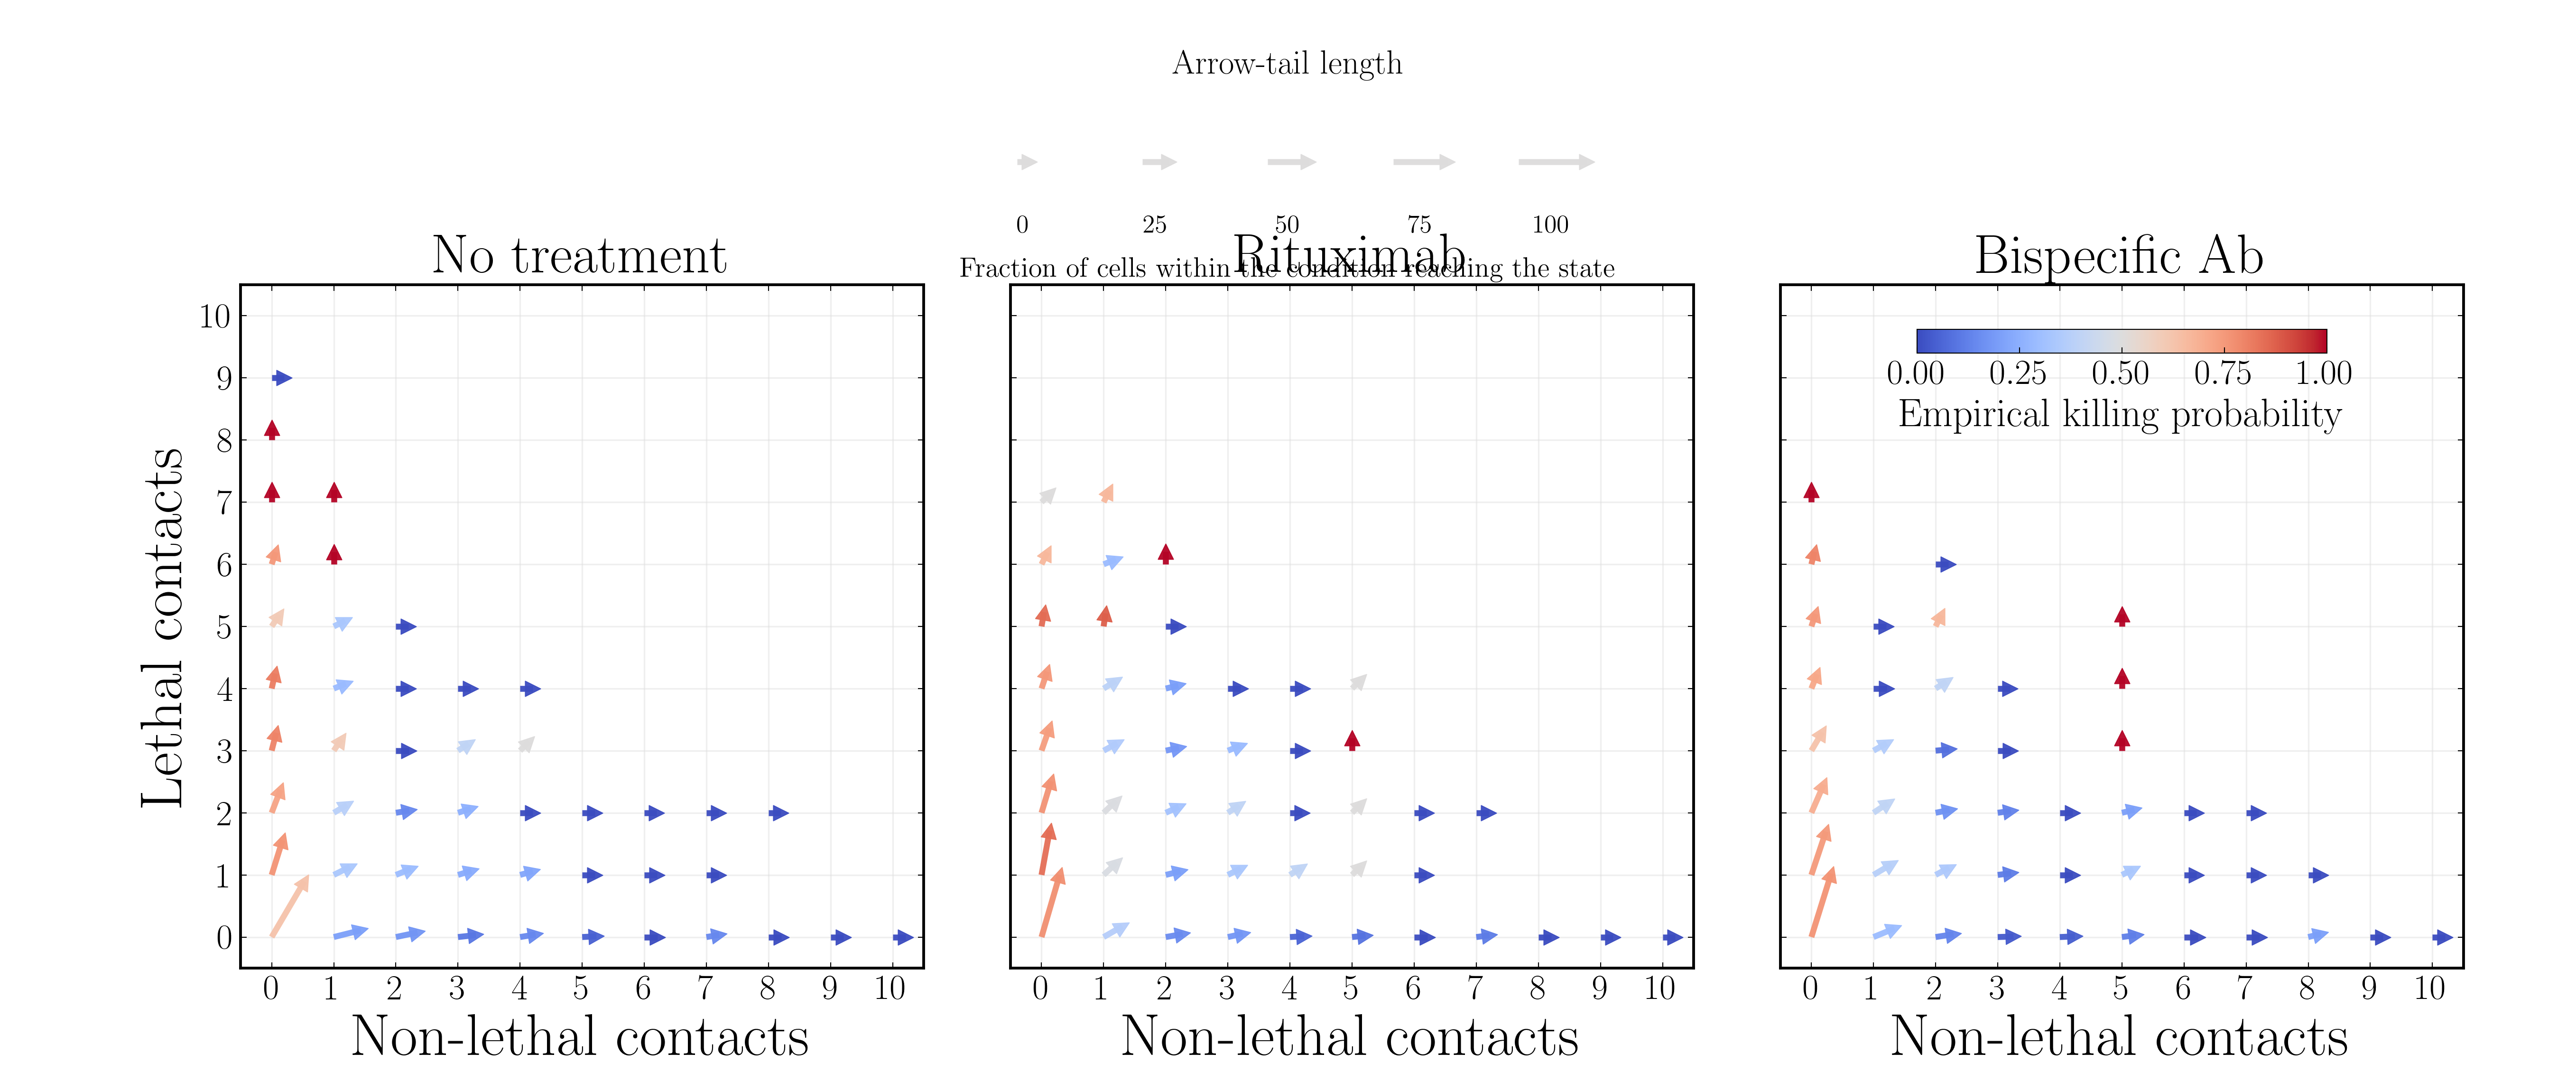

In [9]:


def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    """Convert cell contact histories into event-level observations."""
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            z = int(z)

            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": z,
                }
            )

            if z == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def empirical_next_kill_state_frame(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    """
    Calculate cell counts, cell fractions, and next-kill
    probabilities at each history state.
    """
    events = event_history_frame(cells)

    output_columns = [
        "condition_label",
        "x_before",
        "y_before",
        "n",
        "n_cells",
        "n_condition_events",
        "n_condition_cells",
        "state_density",
        "cell_fraction",
        "next_kill_probability",
    ]

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    events = events[
        events["condition_label"].isin(conditions)
    ].copy()

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    state_df = (
        events.groupby(
            [
                "condition_label",
                "x_before",
                "y_before",
            ],
            as_index=False,
            observed=True,
        )
        .agg(
            n=("z", "size"),
            n_cells=("Cell", "nunique"),
            next_kill_probability=("z", "mean"),
        )
    )

    condition_event_totals = (
        events.groupby(
            "condition_label",
            observed=True,
        )["z"]
        .size()
        .rename("n_condition_events")
        .reset_index()
    )

    condition_cell_totals = (
        cells.loc[
            cells["condition_label"].isin(conditions),
            [
                "condition_label",
                "Cell",
            ],
        ]
        .groupby(
            "condition_label",
            observed=True,
        )["Cell"]
        .nunique()
        .rename("n_condition_cells")
        .reset_index()
    )

    state_df = state_df.merge(
        condition_event_totals,
        on="condition_label",
        how="left",
    )

    state_df = state_df.merge(
        condition_cell_totals,
        on="condition_label",
        how="left",
    )

    state_df["state_density"] = (
        state_df["n"]
        / state_df["n_condition_events"]
    )

    state_df["cell_fraction"] = (
        state_df["n_cells"]
        / state_df["n_condition_cells"]
    ).clip(0, 1)

    state_df["condition_label"] = pd.Categorical(
        state_df["condition_label"],
        categories=list(conditions),
        ordered=True,
    )

    return (
        state_df.sort_values(
            [
                "condition_label",
                "x_before",
                "y_before",
            ]
        )
        .reset_index(drop=True)
    )


def plot_empirical_next_kill_arrow_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",

    # Arrow-tail lengths in plot data units.
    min_tail_length: float = 0.15,
    max_tail_length: float = 0.90,

    # Fixed arrow appearance.
    shaft_linewidth: float = 1.4,
    arrow_head_size: float = 40,
    arrow_edge_width: float = 0.45,

    # Plot controls.
    min_cells: int = 1,
    axis_max: float | None = 10,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    """
    Plot empirical next-event behaviour at each history state.

    Direction
    ---------
    Right:
        Next contact is likely non-lethal.

    Up:
        Next contact is likely lethal.

    Tail length
    -----------
    Scaled between min_tail_length and max_tail_length according
    to the fraction of cells reaching the history state.

    Arrowhead
    ---------
    The arrowhead has the same displayed size for every arrow.

    Colour
    ------
    Empirical probability that the next contact is lethal.
    """
    if min_tail_length < 0:
        raise ValueError(
            "min_tail_length must be non-negative."
        )

    if max_tail_length <= 0:
        raise ValueError(
            "max_tail_length must be greater than zero."
        )

    if min_tail_length > max_tail_length:
        raise ValueError(
            "min_tail_length cannot exceed max_tail_length."
        )

    if shaft_linewidth <= 0:
        raise ValueError(
            "shaft_linewidth must be greater than zero."
        )

    if arrow_head_size <= 0:
        raise ValueError(
            "arrow_head_size must be greater than zero."
        )

    if arrow_edge_width < 0:
        raise ValueError(
            "arrow_edge_width must be non-negative."
        )

    if min_cells < 1:
        raise ValueError(
            "min_cells must be at least 1."
        )

    state_df = empirical_next_kill_state_frame(
        cells,
        conditions=conditions,
    )

    if min_cells > 1:
        state_df = state_df[
            state_df["n_cells"] >= min_cells
        ].copy()

    if state_df.empty:
        return None, state_df

    probability_norm = Normalize(vmin=0, vmax=1)
    cmap_object = plt.get_cmap(cmap)

    if axis_max is None:
        if len(cells) and "contact_count" in cells.columns:
            plot_max = int(
                cells["contact_count"].max()
            )
        else:
            plot_max = int(
                state_df[
                    [
                        "x_before",
                        "y_before",
                    ]
                ]
                .to_numpy(dtype=float)
                .max(initial=0)
            )
    else:
        plot_max = float(axis_max)

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(
            6 * len(conditions),
            7.5,
        ),
        dpi=300,
        sharex=True,
        sharey=True,
        gridspec_kw={
            "wspace": 0.04,
        },
    )

    # Leave space for the real-size arrow legend.
    fig.subplots_adjust(
        top=0.74,
        bottom=0.10,
        left=0.08,
        right=0.97,
    )

    axes = np.atleast_1d(axes)

    for ax, condition in zip(
        axes,
        conditions,
    ):
        sub = state_df[
            state_df["condition_label"] == condition
        ].copy()

        if not sub.empty:
            probability = sub[
                "next_kill_probability"
            ].to_numpy(dtype=float)

            cell_fraction = sub[
                "cell_fraction"
            ].to_numpy(dtype=float)

            # Map fractions onto the full available length range:
            #
            # fraction 0 -> min_tail_length
            # fraction 1 -> max_tail_length
            tail_length = (
                min_tail_length
                + (
                    max_tail_length
                    - min_tail_length
                )
                * cell_fraction
            )

            # Direction of the expected next event.
            horizontal = 1.0 - probability
            vertical = probability

            # Normalize the direction so probability changes only
            # direction, not the requested arrow-tail length.
            direction_norm = np.hypot(
                horizontal,
                vertical,
            )

            horizontal = (
                horizontal
                / direction_norm
            )

            vertical = (
                vertical
                / direction_norm
            )

            x_start = sub[
                "x_before"
            ].to_numpy(dtype=float)

            y_start = sub[
                "y_before"
            ].to_numpy(dtype=float)

            x_head = (
                x_start
                + tail_length * horizontal
            )

            y_head = (
                y_start
                + tail_length * vertical
            )

            for (
                x0,
                y0,
                x1,
                y1,
                dx,
                dy,
                probability_value,
            ) in zip(
                x_start,
                y_start,
                x_head,
                y_head,
                horizontal,
                vertical,
                probability,
            ):
                arrow_colour = cmap_object(
                    probability_norm(
                        probability_value
                    )
                )

                # Arrow shaft.
                ax.plot(
                    [x0, x1],
                    [y0, y1],
                    color=arrow_colour,
                    linewidth=shaft_linewidth,
                    solid_capstyle="butt",
                    alpha=0.95,
                    zorder=3,
                )

                # Fixed-size arrowhead.
                angle_degrees = np.degrees(
                    np.arctan2(
                        dy,
                        dx,
                    )
                )

                head_marker = (
                    MarkerStyle(">")
                    .transformed(
                        Affine2D().rotate_deg(
                            angle_degrees
                        )
                    )
                )

                ax.scatter(
                    [x1],
                    [y1],
                    marker=head_marker,
                    s=arrow_head_size,
                    facecolor=arrow_colour,
                    # edgecolor="black",
                    linewidth=arrow_edge_width,
                    alpha=0.95,
                    zorder=4,
                )

        ax.set_title(
            condition,
            fontsize=28,
        )

        ax.set_xlabel(
            "Non-lethal contacts",
            fontsize=30,
        )

        ax.set_xlim(
            -0.5,
            plot_max + 0.5,
        )

        ax.set_ylim(
            -0.5,
            plot_max + 0.5,
        )

        ax.set_aspect("equal")

        ax.xaxis.set_major_locator(
            MultipleLocator(1)
        )

        ax.yaxis.set_major_locator(
            MultipleLocator(1)
        )

        ax.xaxis.set_minor_locator(
            NullLocator()
        )

        ax.yaxis.set_minor_locator(
            NullLocator()
        )

        ax.tick_params(
            axis="both",
            labelsize=18,
        )

        ax.grid(
            True,
            color="0.85",
            linewidth=0.8,
            alpha=0.4,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    axes[0].set_ylabel(
        "Lethal contacts",
        fontsize=30,
    )

    # ----------------------------------------------------------
    # Killing-probability colour bar
    # ----------------------------------------------------------
    colorbar_mappable = ScalarMappable(
        norm=probability_norm,
        cmap=cmap_object,
    )

    colorbar_mappable.set_array([])

    cbar_ax = axes[-1].inset_axes(
        [
            0.20,
            0.90,
            0.60,
            0.035,
        ]
    )

    cbar = fig.colorbar(
        colorbar_mappable,
        cax=cbar_ax,
        orientation="horizontal",
    )

    cbar.set_label(
        "Empirical killing probability",
        fontsize=20,
    )

    cbar.set_ticks(
        [
            0,
            0.25,
            0.50,
            0.75,
            1,
        ]
    )

    cbar.ax.tick_params(
        labelsize=18,
    )

    cbar.ax.minorticks_off()

    fig.canvas.draw()

    pixel_start = axes[0].transData.transform(
        (0.0, 0.0)
    )

    pixel_end = axes[0].transData.transform(
        (1.0, 0.0)
    )

    one_data_unit_in_figure = (
        pixel_end[0] - pixel_start[0]
    ) / fig.bbox.width

    legend_fractions = np.array(
        [
            0.00,
            0.25,
            0.50,
            0.75,
            1.00,
        ],
        dtype=float,
    )

    legend_lengths = (
        min_tail_length
        + (
            max_tail_length
            - min_tail_length
        )
        * legend_fractions
    )

    legend_lengths_figure = (
        legend_lengths
        * one_data_unit_in_figure
    )

    # Full-figure transparent axis. Coordinates are fractions
    # of the complete figure width and height.
    legend_ax = fig.add_axes(
        [0, 0, 1, 1],
        frameon=False,
        zorder=20,
    )

    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.set_axis_off()

    maximum_legend_width = (
        max_tail_length
        * one_data_unit_in_figure
    )

    slot_gap = 0.025
    slot_width = (
        maximum_legend_width
        + slot_gap
    )

    total_legend_width = (
        len(legend_fractions)
        * slot_width
        - slot_gap
    )

    first_slot_centre = (
        0.5
        - total_legend_width / 2
        + maximum_legend_width / 2
    )

    slot_centres = (
        first_slot_centre
        + np.arange(
            len(legend_fractions)
        )
        * slot_width
    )

    legend_y = 0.855
    label_y = 0.805

    # Neutral colour because this legend represents length,
    # not killing probability.
    legend_colour = cmap_object(
        probability_norm(0.5)
    )

    for (
        slot_centre,
        fraction,
        displayed_length,
    ) in zip(
        slot_centres,
        legend_fractions,
        legend_lengths_figure,
    ):
        x0 = (
            slot_centre
            - displayed_length / 2
        )

        x1 = (
            slot_centre
            + displayed_length / 2
        )

        # Same physical shaft width as the main arrows.
        legend_ax.plot(
            [x0, x1],
            [legend_y, legend_y],
            color=legend_colour,
            linewidth=shaft_linewidth,
            solid_capstyle="butt",
            alpha=0.95,
            clip_on=False,
            zorder=21,
        )

        # Same physical arrowhead size as the main arrows.
        legend_ax.scatter(
            [x1],
            [legend_y],
            marker=">",
            s=arrow_head_size,
            facecolor=legend_colour,
            # edgecolor="black",
            linewidth=arrow_edge_width,
            alpha=0.95,
            clip_on=False,
            zorder=22,
        )

        legend_ax.text(
            slot_centre,
            label_y,
            f"{fraction:.0%}",
            ha="center",
            va="top",
            fontsize=13,
            zorder=23,
        )

    legend_ax.text(
        0.5,
        0.945,
        "Arrow-tail length",
        ha="center",
        va="center",
        fontsize=17,
        zorder=23,
    )

    legend_ax.text(
        0.5,
        0.765,
        "Fraction of cells within the condition reaching the state",
        ha="center",
        va="top",
        fontsize=14,
        zorder=23,
    )

    figure_root = Path(
        figure_root
    )

    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "empirical_next_kill_arrow_maps_by_condition.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df


plt.close("all")

arrow_map_path, arrow_map_stats = (
    plot_empirical_next_kill_arrow_maps_by_condition(
        cells,
        conditions=CONDITION_ORDER,
        figure_root=FIGURE_ROOT,

        # Actual arrow-length range in plot data units.
        min_tail_length=0.2,
        max_tail_length=1.1,

        shaft_linewidth=3,
        arrow_head_size=60,
        arrow_edge_width=0.45,

        min_cells=1,
        axis_max=10,
        show=True,
    )
)


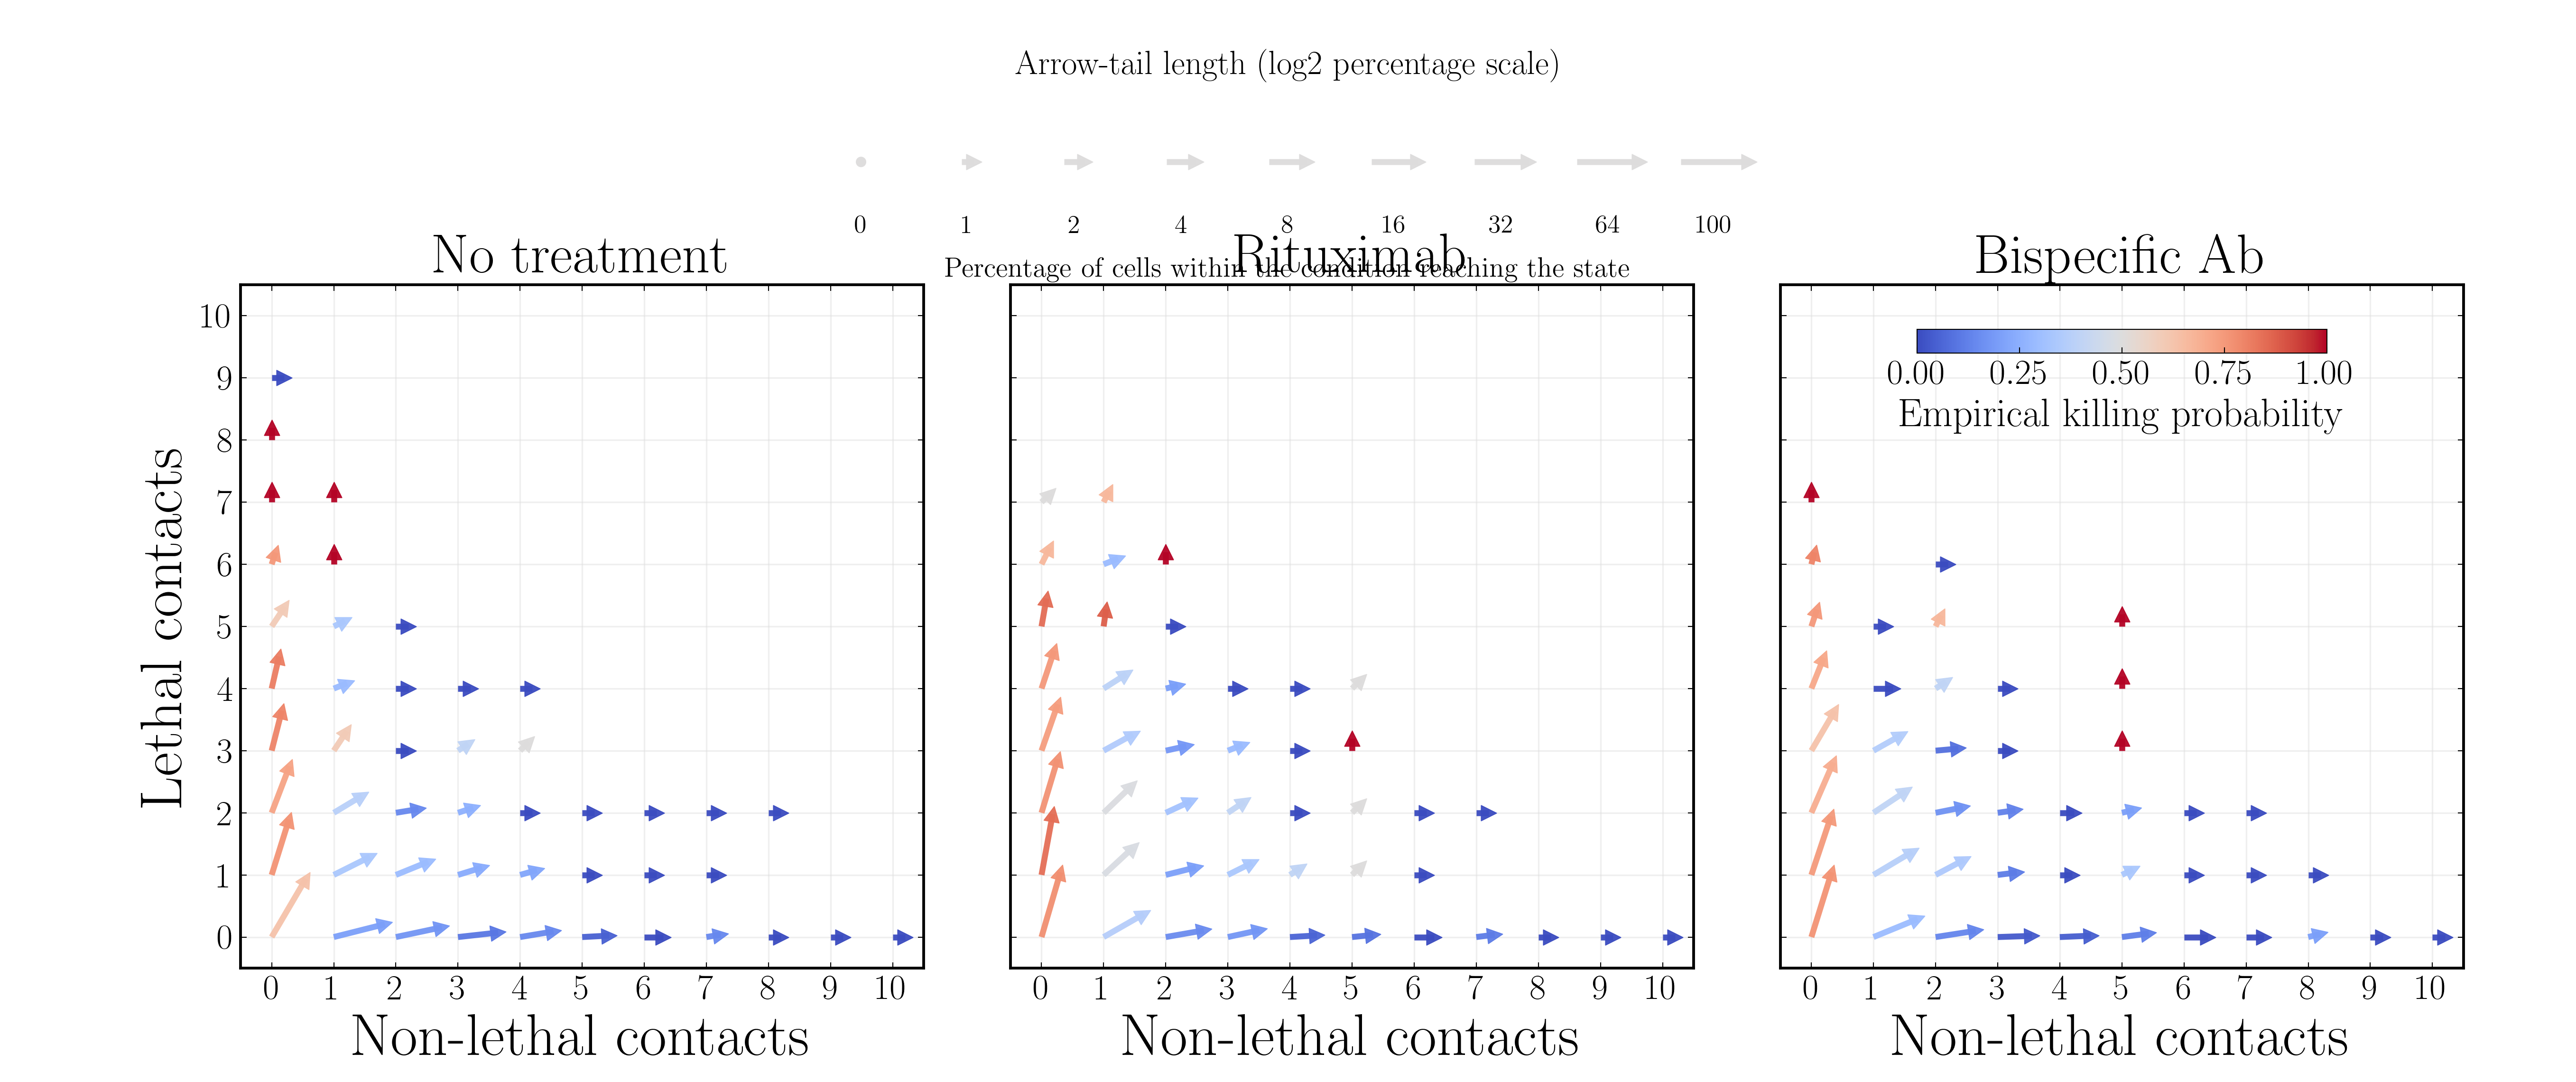

In [10]:
def event_history_frame(cells: pd.DataFrame) -> pd.DataFrame:
    """Convert cell contact histories into event-level observations."""
    rows = []

    for _, row in cells.iterrows():
        x_before = 0
        y_before = 0

        for event_index, z in enumerate(row["history"], start=1):
            z = int(z)

            rows.append(
                {
                    "condition": row["condition"],
                    "condition_label": row["condition_label"],
                    "Cell": row["Cell"],
                    "event_index": event_index,
                    "x_before": x_before,
                    "y_before": y_before,
                    "z": z,
                }
            )

            if z == 1:
                y_before += 1
            else:
                x_before += 1

    return pd.DataFrame(rows)


def empirical_next_kill_state_frame(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    """
    Calculate cell counts, cell percentages, and next-kill
    probabilities at each history state.
    """
    events = event_history_frame(cells)

    output_columns = [
        "condition_label",
        "x_before",
        "y_before",
        "n",
        "n_cells",
        "n_condition_events",
        "n_condition_cells",
        "state_density",
        "cell_percentage",
        "next_kill_probability",
    ]

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    events = events[
        events["condition_label"].isin(conditions)
    ].copy()

    if events.empty:
        return pd.DataFrame(columns=output_columns)

    state_df = (
        events.groupby(
            [
                "condition_label",
                "x_before",
                "y_before",
            ],
            as_index=False,
            observed=True,
        )
        .agg(
            n=("z", "size"),
            n_cells=("Cell", "nunique"),
            next_kill_probability=("z", "mean"),
        )
    )

    condition_event_totals = (
        events.groupby(
            "condition_label",
            observed=True,
        )["z"]
        .size()
        .rename("n_condition_events")
        .reset_index()
    )

    condition_cell_totals = (
        cells.loc[
            cells["condition_label"].isin(conditions),
            ["condition_label", "Cell"],
        ]
        .groupby(
            "condition_label",
            observed=True,
        )["Cell"]
        .nunique()
        .rename("n_condition_cells")
        .reset_index()
    )

    state_df = state_df.merge(
        condition_event_totals,
        on="condition_label",
        how="left",
    )

    state_df = state_df.merge(
        condition_cell_totals,
        on="condition_label",
        how="left",
    )

    state_df["state_density"] = (
        state_df["n"]
        / state_df["n_condition_events"]
    )

    state_df["cell_percentage"] = (
        100.0
        * state_df["n_cells"]
        / state_df["n_condition_cells"]
    ).clip(0, 100)

    state_df["condition_label"] = pd.Categorical(
        state_df["condition_label"],
        categories=list(conditions),
        ordered=True,
    )

    return (
        state_df.sort_values(
            [
                "condition_label",
                "x_before",
                "y_before",
            ]
        )
        .reset_index(drop=True)
    )


def plot_empirical_next_kill_arrow_maps_by_condition(
    cells: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    figure_root: Path = FIGURE_ROOT,
    cmap: str = "coolwarm",

    # Arrow-tail lengths in plot data units.
    min_tail_length: float = 0.15,
    max_tail_length: float = 0.90,

    # Shortest non-zero arrow represents this percentage.
    log_floor_percentage: float = 1.0,

    # Fixed marker/arrow appearance.
    shaft_linewidth: float = 1.4,
    arrow_head_size: float = 40,
    arrow_edge_width: float = 0.45,
    zero_dot_size: float = 28,

    # Plot controls.
    min_cells: int = 1,
    axis_max: float | None = 10,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    """
    Plot empirical next-event behaviour at each history state.

    Direction
    ---------
    Right:
        Next contact is likely non-lethal.

    Up:
        Next contact is likely lethal.

    Tail length
    -----------
    Log2-scaled according to the percentage of cells reaching the
    state. Each doubling (1%, 2%, 4%, 8%, ...) adds the same amount
    of tail length. Zero percent is displayed as a dot.

    Colour
    ------
    Empirical probability that the next contact is lethal.
    """
    if min_tail_length < 0:
        raise ValueError(
            "min_tail_length must be non-negative."
        )

    if max_tail_length <= min_tail_length:
        raise ValueError(
            "max_tail_length must be greater than min_tail_length."
        )

    if not 0 < log_floor_percentage < 100:
        raise ValueError(
            "log_floor_percentage must be between 0 and 100."
        )

    if shaft_linewidth <= 0:
        raise ValueError(
            "shaft_linewidth must be greater than zero."
        )

    if arrow_head_size <= 0:
        raise ValueError(
            "arrow_head_size must be greater than zero."
        )

    if arrow_edge_width < 0:
        raise ValueError(
            "arrow_edge_width must be non-negative."
        )

    if zero_dot_size <= 0:
        raise ValueError(
            "zero_dot_size must be greater than zero."
        )

    if min_cells < 1:
        raise ValueError(
            "min_cells must be at least 1."
        )

    def percentage_to_tail_length(
        percentages: np.ndarray,
    ) -> np.ndarray:
        percentages = np.asarray(
            percentages,
            dtype=float,
        )

        lengths = np.zeros_like(
            percentages,
            dtype=float,
        )

        positive = (
            np.isfinite(percentages)
            & (percentages > 0)
        )

        if np.any(positive):
            clipped = np.clip(
                percentages[positive],
                log_floor_percentage,
                100.0,
            )

            log_position = (
                np.log2(
                    clipped
                    / log_floor_percentage
                )
                / np.log2(
                    100.0
                    / log_floor_percentage
                )
            )

            lengths[positive] = (
                min_tail_length
                + (
                    max_tail_length
                    - min_tail_length
                )
                * np.clip(log_position, 0, 1)
            )

        return lengths

    state_df = empirical_next_kill_state_frame(
        cells,
        conditions=conditions,
    )

    if min_cells > 1:
        state_df = state_df[
            state_df["n_cells"] >= min_cells
        ].copy()

    if state_df.empty:
        return None, state_df

    probability_norm = Normalize(vmin=0, vmax=1)
    cmap_object = plt.get_cmap(cmap)

    if axis_max is None:
        if len(cells) and "contact_count" in cells.columns:
            plot_max = int(
                cells["contact_count"].max()
            )
        else:
            plot_max = int(
                state_df[
                    ["x_before", "y_before"]
                ]
                .to_numpy(dtype=float)
                .max(initial=0)
            )
    else:
        plot_max = float(axis_max)

    fig, axes = plt.subplots(
        1,
        len(conditions),
        figsize=(6 * len(conditions), 7.5),
        dpi=300,
        sharex=True,
        sharey=True,
        gridspec_kw={"wspace": 0.04},
    )

    fig.subplots_adjust(
        top=0.74,
        bottom=0.10,
        left=0.08,
        right=0.97,
    )

    axes = np.atleast_1d(axes)

    for ax, condition in zip(axes, conditions):
        sub = state_df[
            state_df["condition_label"] == condition
        ].copy()

        if not sub.empty:
            probability = sub[
                "next_kill_probability"
            ].to_numpy(dtype=float)

            cell_percentage = sub[
                "cell_percentage"
            ].to_numpy(dtype=float)

            tail_length = percentage_to_tail_length(
                cell_percentage
            )

            horizontal = 1.0 - probability
            vertical = probability

            direction_norm = np.hypot(
                horizontal,
                vertical,
            )

            horizontal = horizontal / direction_norm
            vertical = vertical / direction_norm

            x_start = sub[
                "x_before"
            ].to_numpy(dtype=float)

            y_start = sub[
                "y_before"
            ].to_numpy(dtype=float)

            for (
                x0,
                y0,
                length,
                dx,
                dy,
                probability_value,
                percentage_value,
            ) in zip(
                x_start,
                y_start,
                tail_length,
                horizontal,
                vertical,
                probability,
                cell_percentage,
            ):
                if not np.isfinite(percentage_value):
                    continue

                if np.isfinite(probability_value):
                    marker_colour = cmap_object(
                        probability_norm(
                            probability_value
                        )
                    )
                else:
                    marker_colour = "0.5"

                # Zero percent is represented by a dot.
                if percentage_value <= 0:
                    ax.scatter(
                        [x0],
                        [y0],
                        marker="o",
                        s=zero_dot_size,
                        facecolor=marker_colour,
                        edgecolor="none",
                        alpha=0.95,
                        zorder=4,
                    )
                    continue

                x1 = x0 + length * dx
                y1 = y0 + length * dy

                ax.plot(
                    [x0, x1],
                    [y0, y1],
                    color=marker_colour,
                    linewidth=shaft_linewidth,
                    solid_capstyle="butt",
                    alpha=0.95,
                    zorder=3,
                )

                angle_degrees = np.degrees(
                    np.arctan2(dy, dx)
                )

                head_marker = (
                    MarkerStyle(">")
                    .transformed(
                        Affine2D().rotate_deg(
                            angle_degrees
                        )
                    )
                )

                ax.scatter(
                    [x1],
                    [y1],
                    marker=head_marker,
                    s=arrow_head_size,
                    facecolor=marker_colour,
                    linewidth=arrow_edge_width,
                    alpha=0.95,
                    zorder=4,
                )

        ax.set_title(
            condition,
            fontsize=28,
        )

        ax.set_xlabel(
            "Non-lethal contacts",
            fontsize=30,
        )

        ax.set_xlim(
            -0.5,
            plot_max + 0.5,
        )

        ax.set_ylim(
            -0.5,
            plot_max + 0.5,
        )

        ax.set_aspect("equal")

        ax.xaxis.set_major_locator(
            MultipleLocator(1)
        )

        ax.yaxis.set_major_locator(
            MultipleLocator(1)
        )

        ax.xaxis.set_minor_locator(
            NullLocator()
        )

        ax.yaxis.set_minor_locator(
            NullLocator()
        )

        ax.tick_params(
            axis="both",
            labelsize=18,
        )

        ax.grid(
            True,
            color="0.85",
            linewidth=0.8,
            alpha=0.4,
            zorder=0,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    axes[0].set_ylabel(
        "Lethal contacts",
        fontsize=30,
    )

    # Killing-probability colour bar.
    colorbar_mappable = ScalarMappable(
        norm=probability_norm,
        cmap=cmap_object,
    )

    colorbar_mappable.set_array([])

    cbar_ax = axes[-1].inset_axes(
        [0.20, 0.90, 0.60, 0.035]
    )

    cbar = fig.colorbar(
        colorbar_mappable,
        cax=cbar_ax,
        orientation="horizontal",
    )

    cbar.set_label(
        "Empirical killing probability",
        fontsize=20,
    )

    cbar.set_ticks(
        [0, 0.25, 0.50, 0.75, 1]
    )

    cbar.ax.tick_params(
        labelsize=18,
    )

    cbar.ax.minorticks_off()

    # Real-size arrow-length legend.
    fig.canvas.draw()

    pixel_start = axes[0].transData.transform(
        (0.0, 0.0)
    )

    pixel_end = axes[0].transData.transform(
        (1.0, 0.0)
    )

    one_data_unit_in_figure = (
        pixel_end[0] - pixel_start[0]
    ) / fig.bbox.width

    legend_percentages = np.array(
        [
            0,
            1,
            2,
            4,
            8,
            16,
            32,
            64,
            100,
        ],
        dtype=float,
    )

    legend_lengths = percentage_to_tail_length(
        legend_percentages
    )

    legend_lengths_figure = (
        legend_lengths
        * one_data_unit_in_figure
    )

    legend_ax = fig.add_axes(
        [0, 0, 1, 1],
        frameon=False,
        zorder=20,
    )

    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.set_axis_off()

    maximum_legend_width = (
        max_tail_length
        * one_data_unit_in_figure
    )

    slot_gap = 0.015
    slot_width = (
        maximum_legend_width
        + slot_gap
    )

    total_legend_width = (
        len(legend_percentages)
        * slot_width
        - slot_gap
    )

    first_slot_centre = (
        0.5
        - total_legend_width / 2
        + maximum_legend_width / 2
    )

    slot_centres = (
        first_slot_centre
        + np.arange(
            len(legend_percentages)
        )
        * slot_width
    )

    legend_y = 0.855
    label_y = 0.805

    legend_colour = cmap_object(
        probability_norm(0.5)
    )

    for (
        slot_centre,
        percentage,
        displayed_length,
    ) in zip(
        slot_centres,
        legend_percentages,
        legend_lengths_figure,
    ):
        if percentage == 0:
            legend_ax.scatter(
                [slot_centre],
                [legend_y],
                marker="o",
                s=zero_dot_size,
                facecolor=legend_colour,
                edgecolor="none",
                alpha=0.95,
                clip_on=False,
                zorder=22,
            )
        else:
            x0 = (
                slot_centre
                - displayed_length / 2
            )

            x1 = (
                slot_centre
                + displayed_length / 2
            )

            legend_ax.plot(
                [x0, x1],
                [legend_y, legend_y],
                color=legend_colour,
                linewidth=shaft_linewidth,
                solid_capstyle="butt",
                alpha=0.95,
                clip_on=False,
                zorder=21,
            )

            legend_ax.scatter(
                [x1],
                [legend_y],
                marker=">",
                s=arrow_head_size,
                facecolor=legend_colour,
                linewidth=arrow_edge_width,
                alpha=0.95,
                clip_on=False,
                zorder=22,
            )

        legend_ax.text(
            slot_centre,
            label_y,
            f"{percentage:g}%",
            ha="center",
            va="top",
            fontsize=13,
            zorder=23,
        )

    legend_ax.text(
        0.5,
        0.945,
        "Arrow-tail length (log2 percentage scale)",
        ha="center",
        va="center",
        fontsize=17,
        zorder=23,
    )

    legend_ax.text(
        0.5,
        0.765,
        "Percentage of cells within the condition reaching the state",
        ha="center",
        va="top",
        fontsize=14,
        zorder=23,
    )

    figure_root = Path(figure_root)

    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "empirical_next_kill_arrow_maps_by_condition.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, state_df


plt.close("all")

arrow_map_path, arrow_map_stats = (
    plot_empirical_next_kill_arrow_maps_by_condition(
        cells,
        conditions=CONDITION_ORDER,
        figure_root=FIGURE_ROOT,
        min_tail_length=0.2,
        max_tail_length=1.1,
        log_floor_percentage=1.0,
        shaft_linewidth=3,
        arrow_head_size=60,
        arrow_edge_width=0.45,
        zero_dot_size=28,
        min_cells=1,
        axis_max=10,
        show=True,
    )
)

## Cached SMC inference results

The notebook reads saved outputs only. To generate or resume them, run:

```bash
python3 section_4/scripts/run_analysis_2_inference.py
```


In [11]:

def collect_cached_log_evidence(
    *,
    result_root: Path = RESULT_ROOT,
    condition_labels: Sequence[str] = CONDITION_ORDER,
    model_order: Sequence[str] = MODEL_ORDER,
) -> pd.DataFrame:
    rows = []

    aggregate_path = result_root / "log_evidence_all_conditions_smc.csv"
    if aggregate_path.exists():
        df = pd.read_csv(aggregate_path)
        if len(df):
            return df

    for condition_label in condition_labels:
        condition_dir = result_root / slug(condition_label)

        for model_name in model_order:
            path = condition_dir / f"log_evidence_{model_name}_smc.csv"

            if not path.exists():
                continue

            df = pd.read_csv(path)
            if len(df):
                rows.append(df.iloc[0].to_dict())

    return pd.DataFrame(rows)


def load_cached_posteriors(
    *,
    result_root: Path = RESULT_ROOT,
    condition_labels: Sequence[str] = CONDITION_ORDER,
    model_order: Sequence[str] = MODEL_ORDER,
) -> dict[tuple[str, str], az.InferenceData]:
    posterior_data = {}

    for condition_label in condition_labels:
        condition_dir = result_root / slug(condition_label)

        for model_name in model_order:
            posterior_path = condition_dir / f"posterior_{model_name}_smc.nc"

            if posterior_path.exists():
                posterior_data[(condition_label, model_name)] = az.from_netcdf(str(posterior_path))

    return posterior_data


def add_bayes_factor_vs_best(log_df: pd.DataFrame) -> pd.DataFrame:
    df = log_df.copy()

    if df.empty:
        return df

    df["best_log_evidence"] = df.groupby("condition")["log_evidence"].transform("max")
    df["delta_log_evidence_vs_best"] = df["log_evidence"] - df["best_log_evidence"]
    df["log10_BF_model_vs_best"] = df["delta_log_evidence_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(np.clip(-df["delta_log_evidence_vs_best"], -745, 709))

    best_models = (
        df.sort_values("log_evidence", ascending=False)
        .groupby("condition")["model"]
        .first()
        .rename("best_model")
        .reset_index()
    )

    df = df.merge(best_models, on="condition", how="left")
    df["model_display"] = df["model"].map(MODEL_SHORT_DISPLAY).fillna(df["model"])
    return df


def overall_model_comparison(log_df: pd.DataFrame) -> pd.DataFrame:
    if log_df.empty:
        return log_df.copy()

    df = (
        log_df.groupby("model", as_index=False)
        .agg(total_log_evidence=("log_evidence", "sum"), n_conditions=("condition", "nunique"))
        .sort_values("total_log_evidence", ascending=False)
        .reset_index(drop=True)
    )

    best = float(df["total_log_evidence"].max())
    df["delta_log_evidence_vs_best"] = df["total_log_evidence"] - best
    df["log10_BF_model_vs_best"] = df["delta_log_evidence_vs_best"] / np.log(10.0)
    df["log10_BF_best_vs_model"] = -df["log10_BF_model_vs_best"]
    df["BF_best_vs_model"] = np.exp(np.clip(-df["delta_log_evidence_vs_best"], -745, 709))
    df["model_display"] = df["model"].map(MODEL_SHORT_DISPLAY).fillna(df["model"])
    return df


def plot_overall_bayes_factors(
    overall_df: pd.DataFrame,
    *,
    save_path: Path | None = None,
    dpi: int = 400,
    colors: dict[str, str] = MODEL_COLORS,
    xmin: float = -10.0,
    xmax: float = 0.35,
    show: bool = False,
) -> Path | None:
    if overall_df.empty:
        raise ValueError("overall_df is empty.")

    plot_df = overall_df.copy().sort_values("total_log_evidence", ascending=False)
    best_model = str(plot_df.iloc[0]["model"])
    plot_df = plot_df.sort_values("log10_BF_model_vs_best", ascending=True)

    bf3 = np.log10(3.0)

    fig, ax = plt.subplots(figsize=(8.8, 4.5), dpi=dpi)
    ax.set_xlim(xmin, xmax)

    ax.axvspan(-1.0, -bf3, color="#FFF3B0", alpha=0.34, linewidth=0, zorder=0)
    ax.axvspan(-2.0, -1.0, color="#FFD28A", alpha=0.30, linewidth=0, zorder=0)
    ax.axvspan(xmin, -2.0, color="#E76F51", alpha=0.26, linewidth=0, zorder=0)

    ax.axvline(-bf3, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
    ax.axvline(-1.0, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
    ax.axvline(-2.0, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
    ax.axvline(0.0, color="black", linewidth=1.8, zorder=3)

    bar_colors = [
        "#000000" if model == best_model else colors.get(model, "black")
        for model in plot_df["model"]
    ]

    raw_values = plot_df["log10_BF_model_vs_best"].to_numpy(dtype=float)
    plot_values = np.maximum(raw_values, xmin)

    bars = ax.barh(
        plot_df["model_display"],
        plot_values,
        color=bar_colors,
        alpha=0.9,
        edgecolor="black",
        linewidth=1.5,
        zorder=2,
    )

    for bar, raw_value, plot_value in zip(bars, raw_values, plot_values):
        y = bar.get_y() + bar.get_height() / 2
        is_clipped = raw_value < xmin

        if is_clipped:
            ax.text(
                xmin + 0.18,
                y,
                "//",
                va="center",
                ha="left",
                fontsize=24,
                color="black",
                zorder=5,
            )
            text_x = xmin + 0.62
        else:
            text_x = plot_value + 0.12 if plot_value < -0.25 else 0.05

        ax.text(
            text_x,
            y,
            f"{raw_value:.2f}",
            va="center",
            ha="left",
            fontsize=26,
            color="black",
            zorder=5,
        )

    ax.set_xlabel(
        r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=26,
    )
    ax.set_title("Overall history-model comparison", fontsize=18, pad=14)

    ax.tick_params(axis="x", which="major", labelsize=20)
    ax.tick_params(axis="y", which="major", labelsize=24)
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.8)
        spine.set_color("black")

    fig.subplots_adjust(left=0.30, bottom=0.26)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path


def plot_condition_bayes_factors_real_x_subplots(
    bf_condition_df: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = MODEL_COLORS,
    save_path: Path | None = None,
    dpi: int = 400,
    xmin: float = -10.0,
    xmax: float = 0.35,
    show: bool = False,
) -> Path | None:
    conditions = list(conditions)

    if not conditions:
        raise ValueError("conditions must contain at least one condition.")

    plot_df = bf_condition_df[
        bf_condition_df["condition"].isin(conditions)
    ].copy()

    if plot_df.empty:
        raise ValueError("No Bayes-factor rows found for the requested conditions.")

    bf3 = np.log10(3.0)

    fig, axes = plt.subplots(
        nrows=len(conditions),
        ncols=1,
        figsize=(7, 4.0 * len(conditions)),
        dpi=dpi,
        sharex=True,
    )
    axes = np.atleast_1d(axes)

    for ax, condition in zip(axes, conditions):
        sub = (
            plot_df[plot_df["condition"] == condition]
            .copy()
            .sort_values("log_evidence", ascending=False)
        )

        ax.set_xlim(xmin, xmax)

        ax.axvspan(-1.0, -bf3, color="#FFF3B0", alpha=0.34, linewidth=0, zorder=0)
        ax.axvspan(-2.0, -1.0, color="#FFD28A", alpha=0.30, linewidth=0, zorder=0)
        ax.axvspan(xmin, -2.0, color="#E76F51", alpha=0.26, linewidth=0, zorder=0)

        ax.axvline(-bf3, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
        ax.axvline(-1.0, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
        ax.axvline(-2.0, color="black", linestyle=":", linewidth=1.2, alpha=0.65, zorder=1)
        ax.axvline(0.0, color="black", linewidth=1.8, zorder=3)

        if sub.empty:
            ax.text(
                0.5,
                0.5,
                "No cached evidence",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=18,
            )
        else:
            best_model = str(sub.iloc[0]["best_model"])
            sub = sub.sort_values("log10_BF_model_vs_best", ascending=True)

            bar_colors = [
                "#000000" if model == best_model else colors.get(model, "black")
                for model in sub["model"]
            ]
            raw_values = sub["log10_BF_model_vs_best"].to_numpy(dtype=float)
            plot_values = np.maximum(raw_values, xmin)

            bars = ax.barh(
                sub["model_display"],
                plot_values,
                color=bar_colors,
                alpha=0.9,
                edgecolor="black",
                linewidth=1.5,
                zorder=2,
            )

            for bar, raw_value, plot_value in zip(bars, raw_values, plot_values):
                y = bar.get_y() + bar.get_height() / 2
                is_clipped = raw_value < xmin

                if is_clipped:
                    ax.text(
                        xmin + 0.18,
                        y,
                        "//",
                        va="center",
                        ha="left",
                        fontsize=24,
                        color="black",
                        zorder=5,
                    )
                    text_x = xmin + 0.62
                else:
                    text_x = plot_value + 0.12 if plot_value < -0.25 else 0.05

                ax.text(
                    text_x,
                    y,
                    f"{raw_value:.2f}",
                    va="center",
                    ha="left",
                    fontsize=22,
                    color="black",
                    zorder=5,
                )

        ax.set_title(condition, fontsize=22, pad=8)
        ax.tick_params(axis="y", which="major", labelsize=22)
        ax.tick_params(axis="x", which="major", labelsize=18)
        ax.minorticks_off()
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.6)
            spine.set_color("black")

    axes[-1].set_xlabel(
        r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{best}})$",
        fontsize=24,
    )

    fig.subplots_adjust(left=0.30, right=0.97, bottom=0.10, top=0.82, hspace=0.25)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path


def get_joint_posterior_samples(
    idata: az.InferenceData,
    parameters: Sequence[str],
    *,
    sample_size: int = 6000,
    seed: int | None = None,
) -> dict[str, np.ndarray]:
    # Stack chain/draw once so every row remains one joint posterior draw.
    posterior = idata.posterior[list(parameters)].stack(sample=("chain", "draw"))
    joint_samples = np.column_stack(
        [np.asarray(posterior[param].values, dtype=float).ravel() for param in parameters]
    )
    joint_samples = joint_samples[np.all(np.isfinite(joint_samples), axis=1)]

    if sample_size is not None and joint_samples.shape[0] > sample_size:
        rng = np.random.default_rng(seed)
        indices = rng.choice(joint_samples.shape[0], sample_size, replace=False)
        joint_samples = joint_samples[indices]

    return {param: joint_samples[:, i] for i, param in enumerate(parameters)}


def plot_posteriors_three_conditions(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    parameters: Sequence[str] = ("mu_lambda", "sigma_lambda", "mu_p0", "sigma_eta"),
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    sample_size: int = 6000,
    bins: int = 22,
    save_path: Path | None = None,
    show: bool = False,
) -> Path | None:
    parameters = list(parameters)

    if any((condition, model_name) not in posterior_data for condition in conditions):
        return None

    parameters = [
        param
        for param in parameters
        if all(param in posterior_data[(condition, model_name)].posterior for condition in conditions)
    ]

    if not parameters:
        return None

    samples = {}

    for condition_index, condition in enumerate(conditions):
        key = (condition, model_name)
        idata = posterior_data[key]
        samples[condition] = get_joint_posterior_samples(
            idata, parameters, sample_size=sample_size, seed=17 + condition_index
        )

    npar = len(parameters)
    fig, axes = plt.subplots(npar, npar, figsize=(4.6 * npar, 4.6 * npar), dpi=300, constrained_layout=True, squeeze=False)
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.03, hspace=0.03)

    for irow, rowpar in enumerate(parameters):
        for icol, colpar in enumerate(parameters):
            ax = axes[irow, icol]
            ax.set_facecolor("white")
            ax.minorticks_off()

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2)
                spine.set_color("black")

            if icol > irow:
                ax.axis("off")
                continue

            for condition in conditions:
                color = colors[condition]

                if icol == irow:
                    vals = samples[condition][rowpar]
                    sns.histplot(vals, bins=bins, stat="density", element="step", fill=True, ax=ax, color=color, alpha=0.12, linewidth=0)
                    sns.histplot(vals, bins=bins, stat="density", element="step", fill=False, ax=ax, color=color, linewidth=2.4, label=condition if irow == 0 else None)

                    try:
                        lo, hi = az.hdi(vals, hdi_prob=0.95)
                        ax.axvspan(float(lo), float(hi), color=color, alpha=0.08, linewidth=0)
                    except Exception:
                        pass
                else:
                    xvals = samples[condition][colpar]
                    yvals = samples[condition][rowpar]
                    n = min(xvals.size, yvals.size)

                    if n:
                        sns.kdeplot(x=xvals[:n], y=yvals[:n], ax=ax, color=color, linewidths=1.8, levels=6, fill=False, alpha=0.85)

            if icol == irow:
                ax.set_xlabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=34)
                ax.set_ylabel("Density", fontsize=30)
            else:
                ax.set_xlabel(PARAM_DISPLAY.get(colpar, colpar), fontsize=34)
                ax.set_ylabel(PARAM_DISPLAY.get(rowpar, rowpar), fontsize=34)

            ax.tick_params(axis="both", which="major", labelsize=22)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.grid(alpha=0.22)

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()

    if handles:
        fig.legend(handles, legend_labels, loc="upper right", frameon=True, fontsize=18, edgecolor="black")

    fig.suptitle(MODEL_DISPLAY.get(model_name, model_name).replace("\n", " "), fontsize=26, y=1.03)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path


def write_evidence_plots(log_df: pd.DataFrame, *, figure_root: Path = FIGURE_ROOT, show: bool = False):
    if log_df.empty:
        return None, None

    bf_condition_df = add_bayes_factor_vs_best(log_df)
    overall_df = overall_model_comparison(log_df)
    plot_overall_bayes_factors(
        overall_df,
        save_path=figure_root / "bayes_factor_overall_history_models.svg",
        xmin=-9.0,
        show=show,
    )
    plot_condition_bayes_factors_real_x_subplots(
        bf_condition_df,
        save_path=figure_root / "bayes_factor_by_condition_real_x_subplots_history_models.svg",
        show=show,
    )
    return bf_condition_df, overall_df


def run_posterior_plots(
    posterior_data: dict,
    *,
    figure_root: Path = FIGURE_ROOT,
    show: bool = False,
) -> list[Path | None]:
    return [
        plot_posteriors_three_conditions(
            posterior_data,
            model_name=FULL_MODEL,
            parameters=("mu_lambda", "sigma_lambda"),
            save_path=figure_root / "contact_rate_posterior_three_conditions.svg",
            show=show,
        ),
        plot_posteriors_three_conditions(
            posterior_data,
            model_name=FULL_MODEL,
            parameters=("mu_eta", "sigma_eta", "beta_x", "beta_y"),
            save_path=figure_root / "decision_history_posterior_three_conditions.svg",
            show=show,
        ),
        # plot_posteriors_three_conditions(
        #     posterior_data,
        #     model_name=FULL_MODEL,
        #     parameters=("odds_ratio_x", "odds_ratio_y"),
        #     save_path=figure_root / "history_odds_ratio_posterior_three_conditions.svg",
        #     show=show,
        # ),
    ]


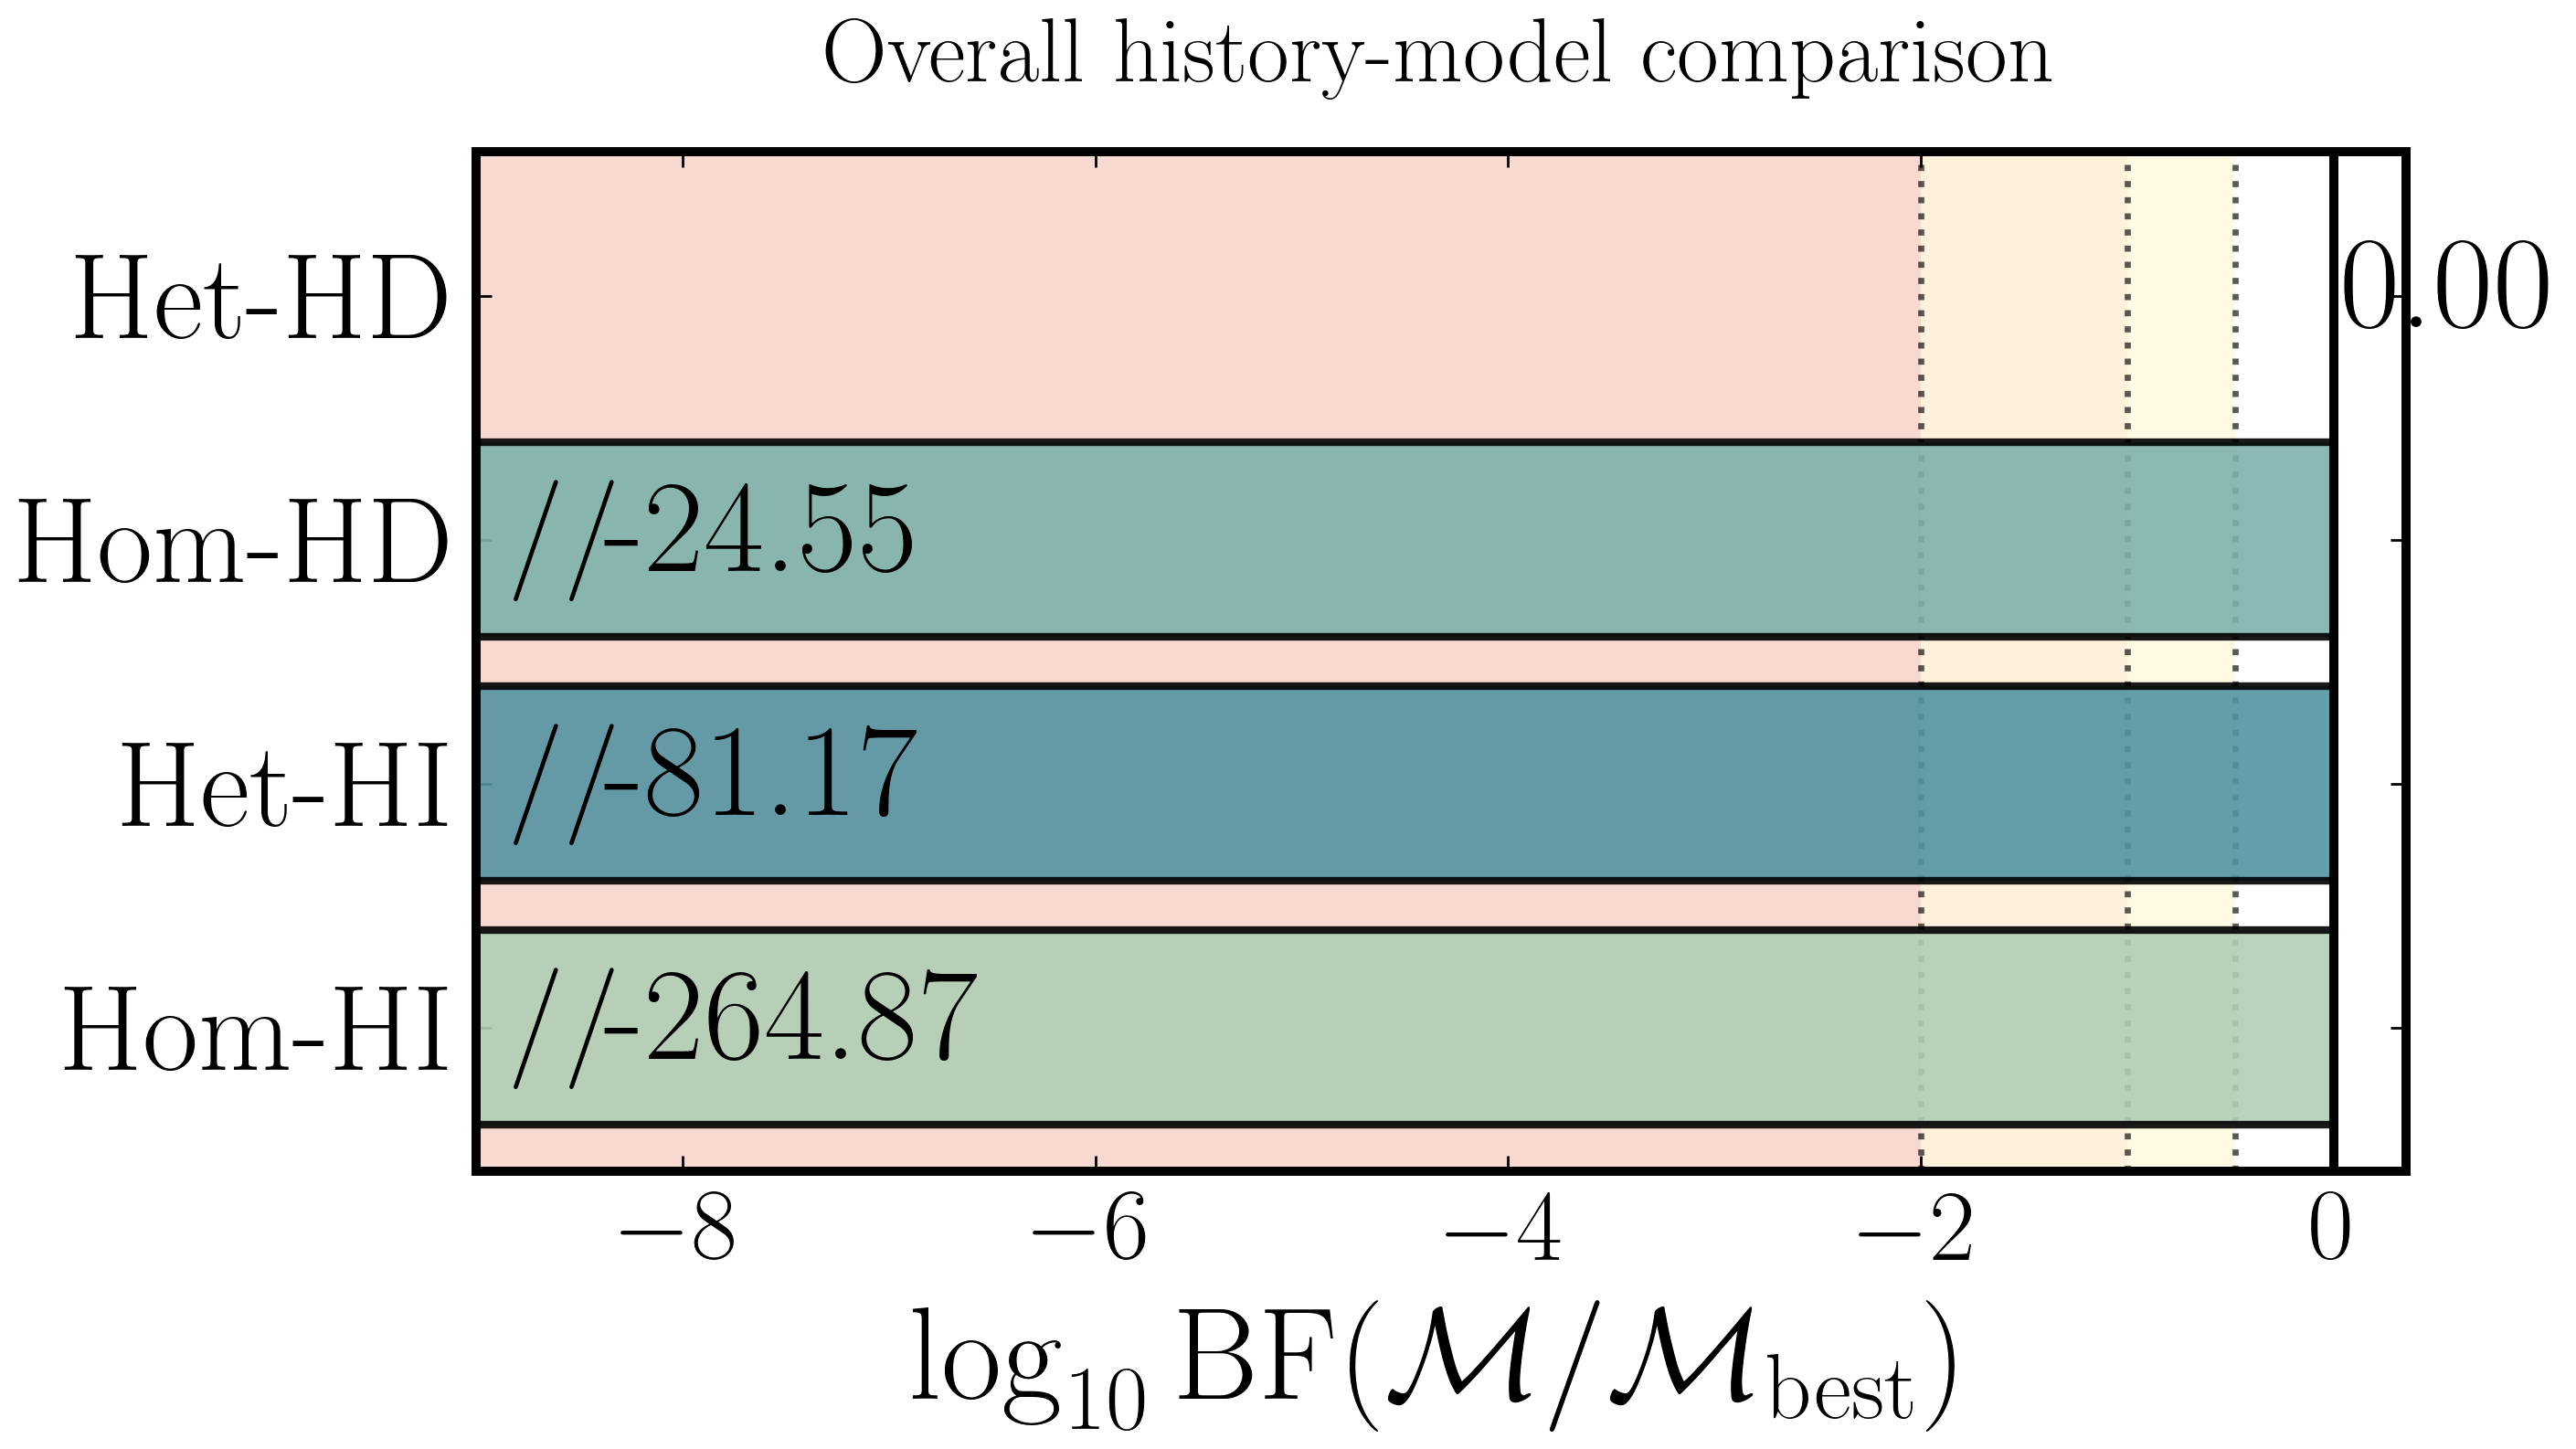

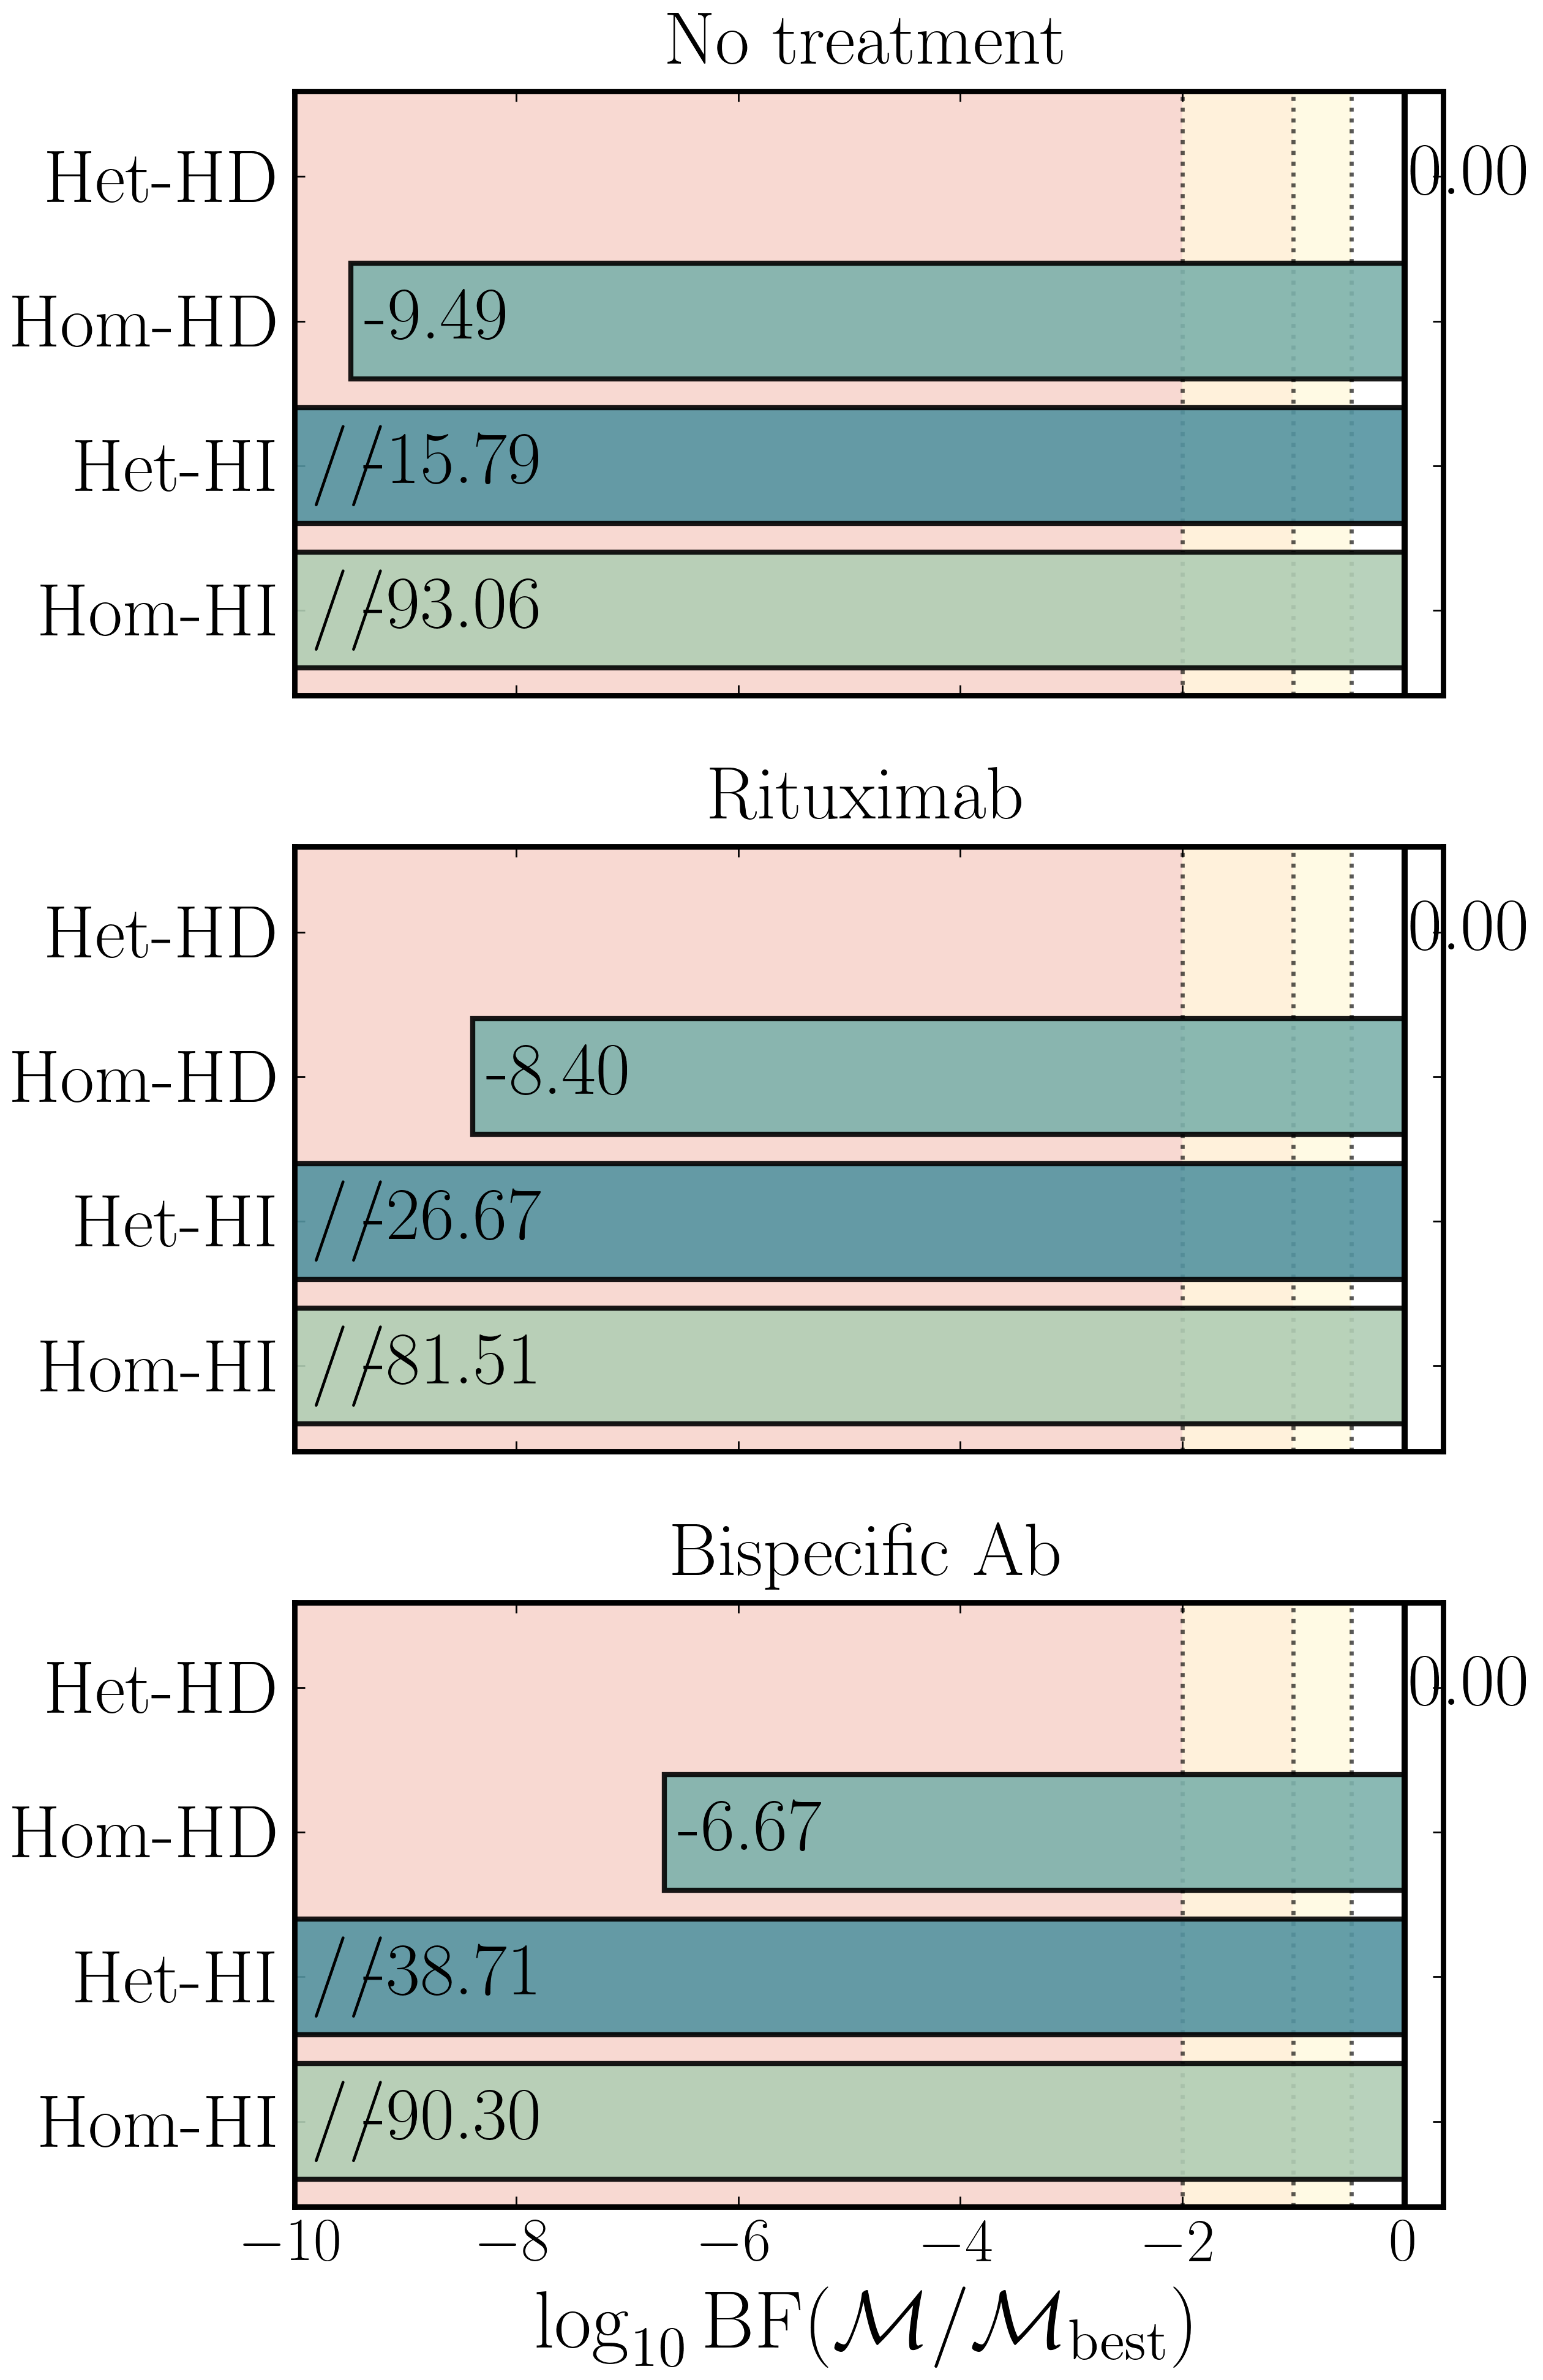

,condition,model,log_evidence
11,Bispecific Ab,heterogeneous_history_dependent,-1959.178015
9,Bispecific Ab,homogeneous_history_dependent,-1974.525326
10,Bispecific Ab,heterogeneous_history_independent,-2048.311158
8,Bispecific Ab,homogeneous_history_independent,-2167.099469
3,No treatment,heterogeneous_history_dependent,-2193.517222
1,No treatment,homogeneous_history_dependent,-2215.368078
2,No treatment,heterogeneous_history_independent,-2229.881704
0,No treatment,homogeneous_history_independent,-2407.797651
7,Rituximab,heterogeneous_history_dependent,-2088.179897
5,Rituximab,homogeneous_history_dependent,-2107.510759


,model,total_log_evidence,n_conditions,delta_log_evidence_vs_best,log10_BF_model_vs_best,log10_BF_best_vs_model,BF_best_vs_model,model_display
0,heterogeneous_history_dependent,-6240.875134,3,0.000000,0.000000,-0.000000,1.000000e+00,Het-HD
1,homogeneous_history_dependent,-6297.404162,3,-56.529028,-24.550245,24.550245,3.550136e+24,Hom-HD
2,heterogeneous_history_independent,-6427.774529,3,-186.899395,-81.169376,81.169376,1.476985e+81,Het-HI
3,homogeneous_history_independent,-6850.772140,3,-609.897006,-264.874904,264.874904,7.497285e+264,Hom-HI


In [12]:
logml_df = collect_cached_log_evidence()
posterior_data = load_cached_posteriors()

if not logml_df.empty:
    bf_condition_df, overall_df = write_evidence_plots(logml_df, show=True)
    display(logml_df.sort_values(["condition", "log_evidence"], ascending=[True, False]))
    display(overall_df)
else:
    bf_condition_df = None
    overall_df = None
    print("No cached evidence found yet. Run the inference script first.")


## Posterior plots 


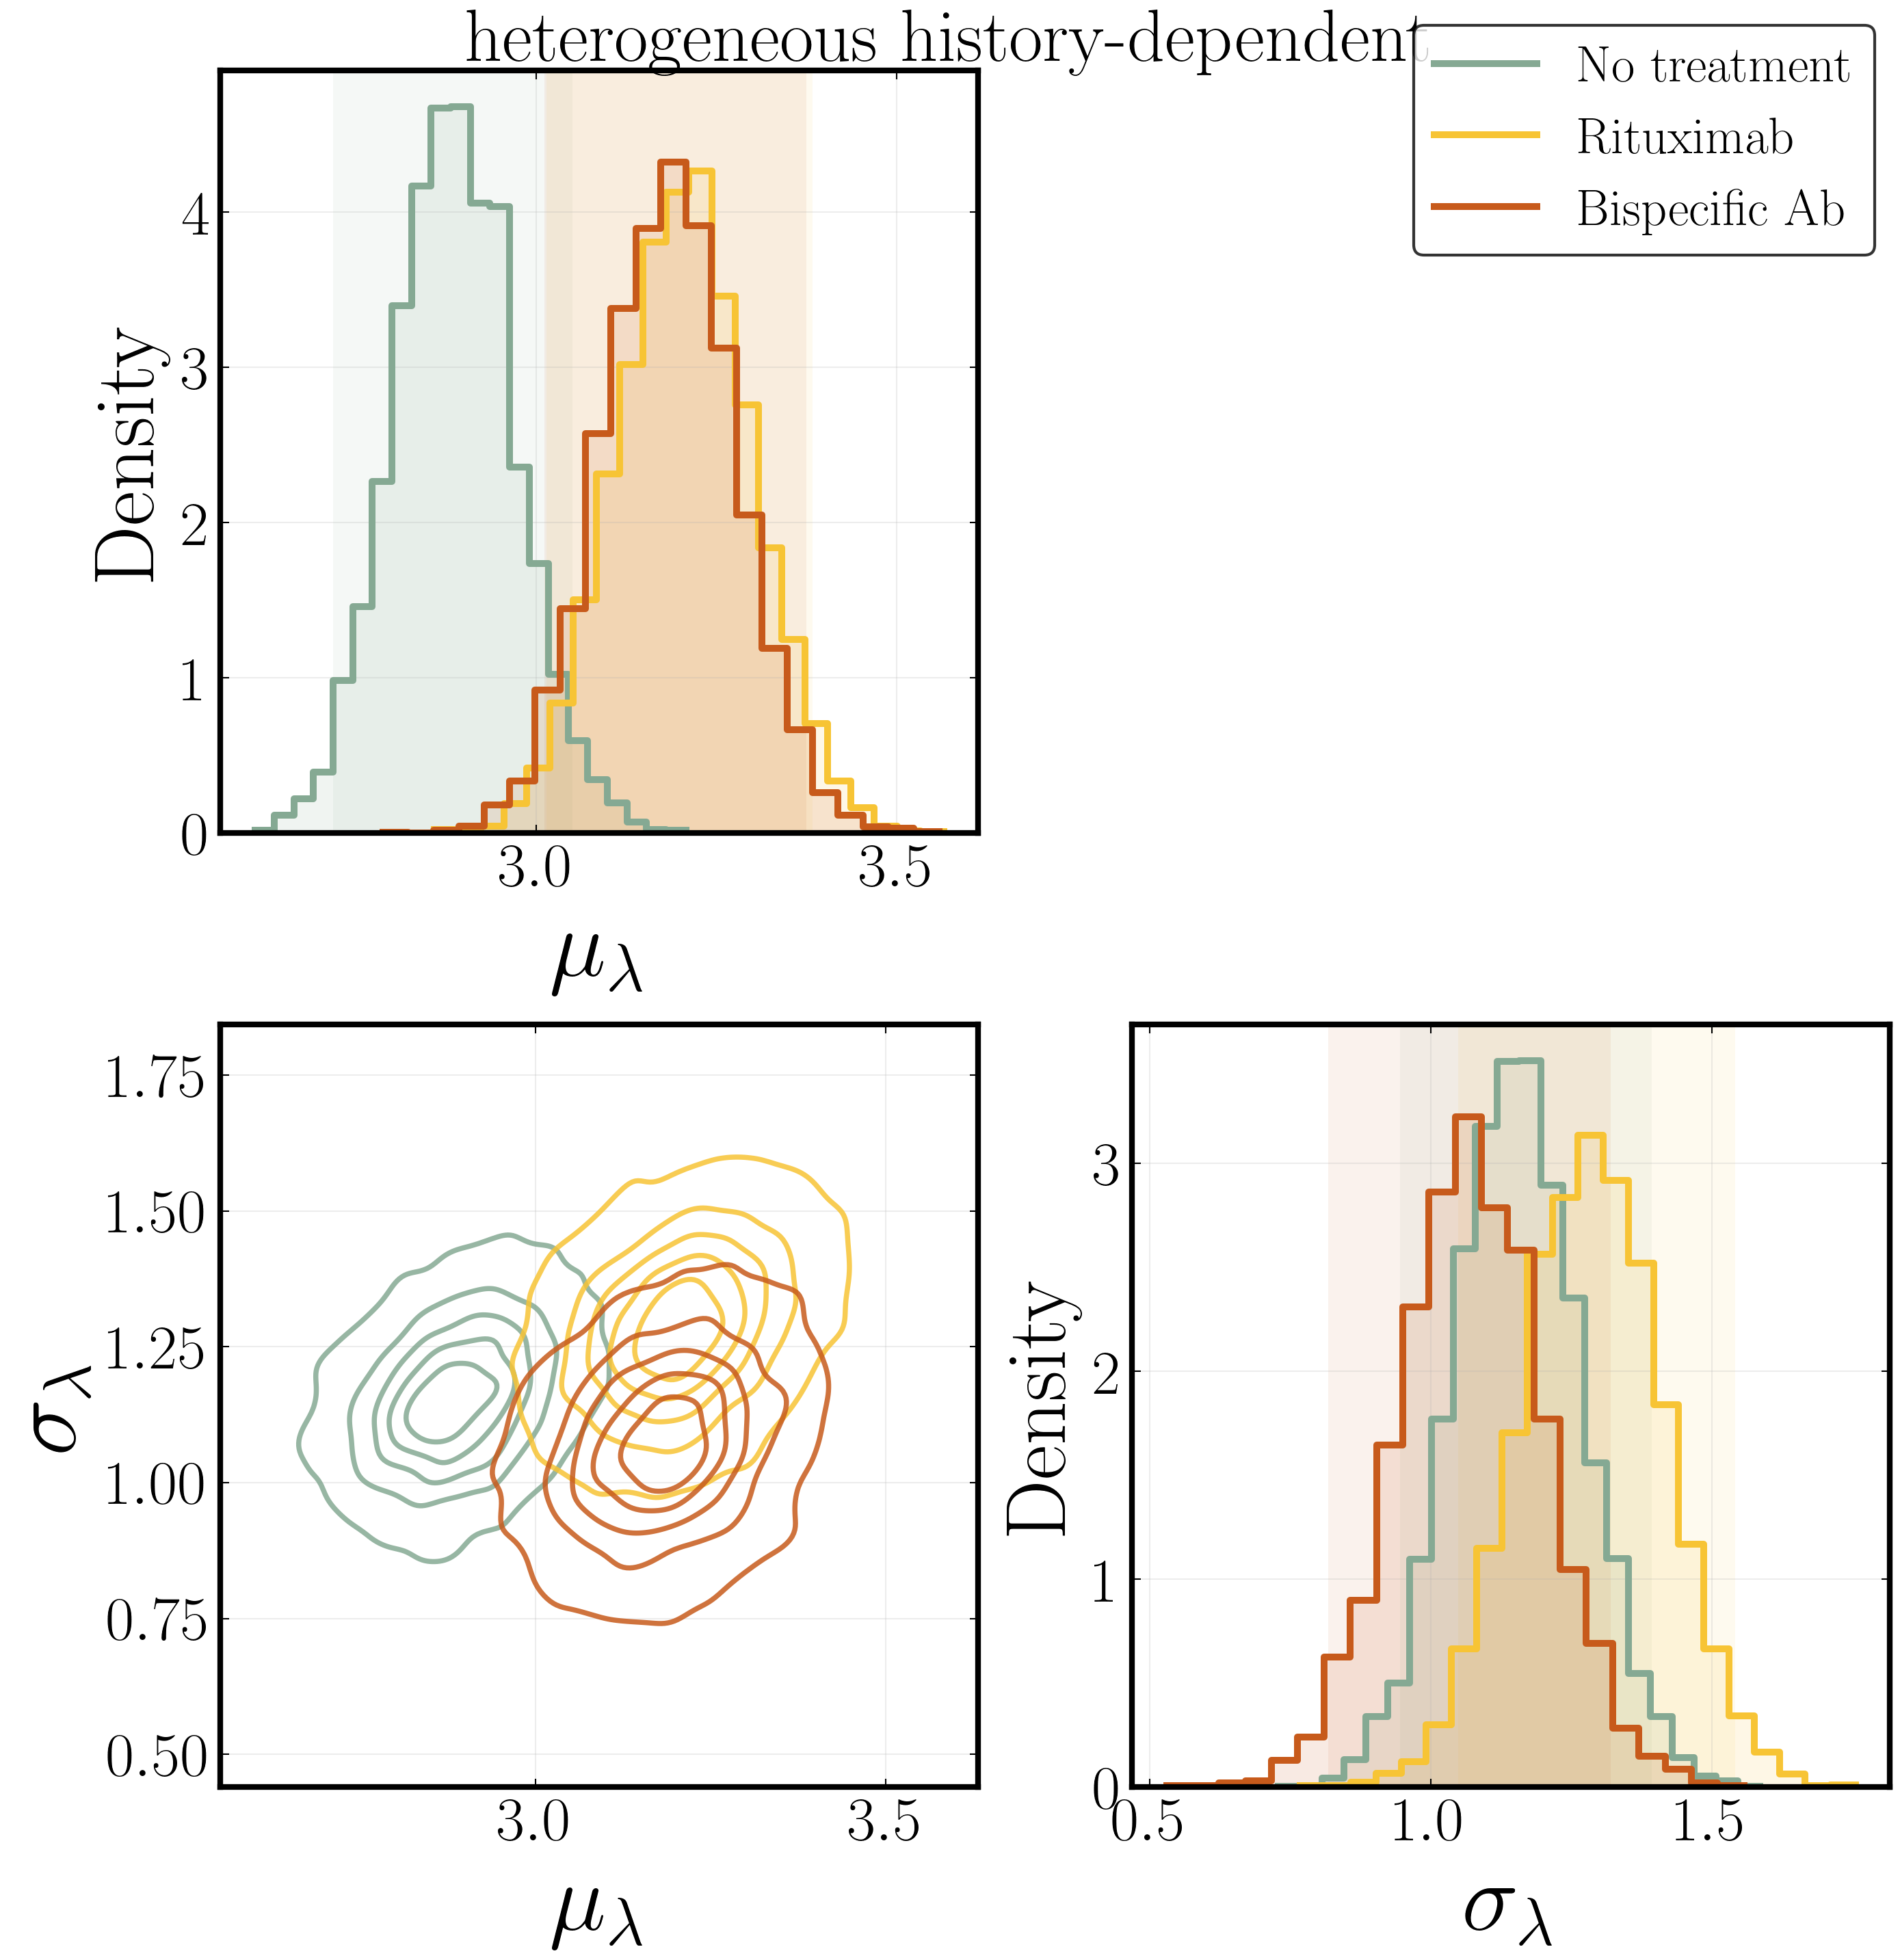

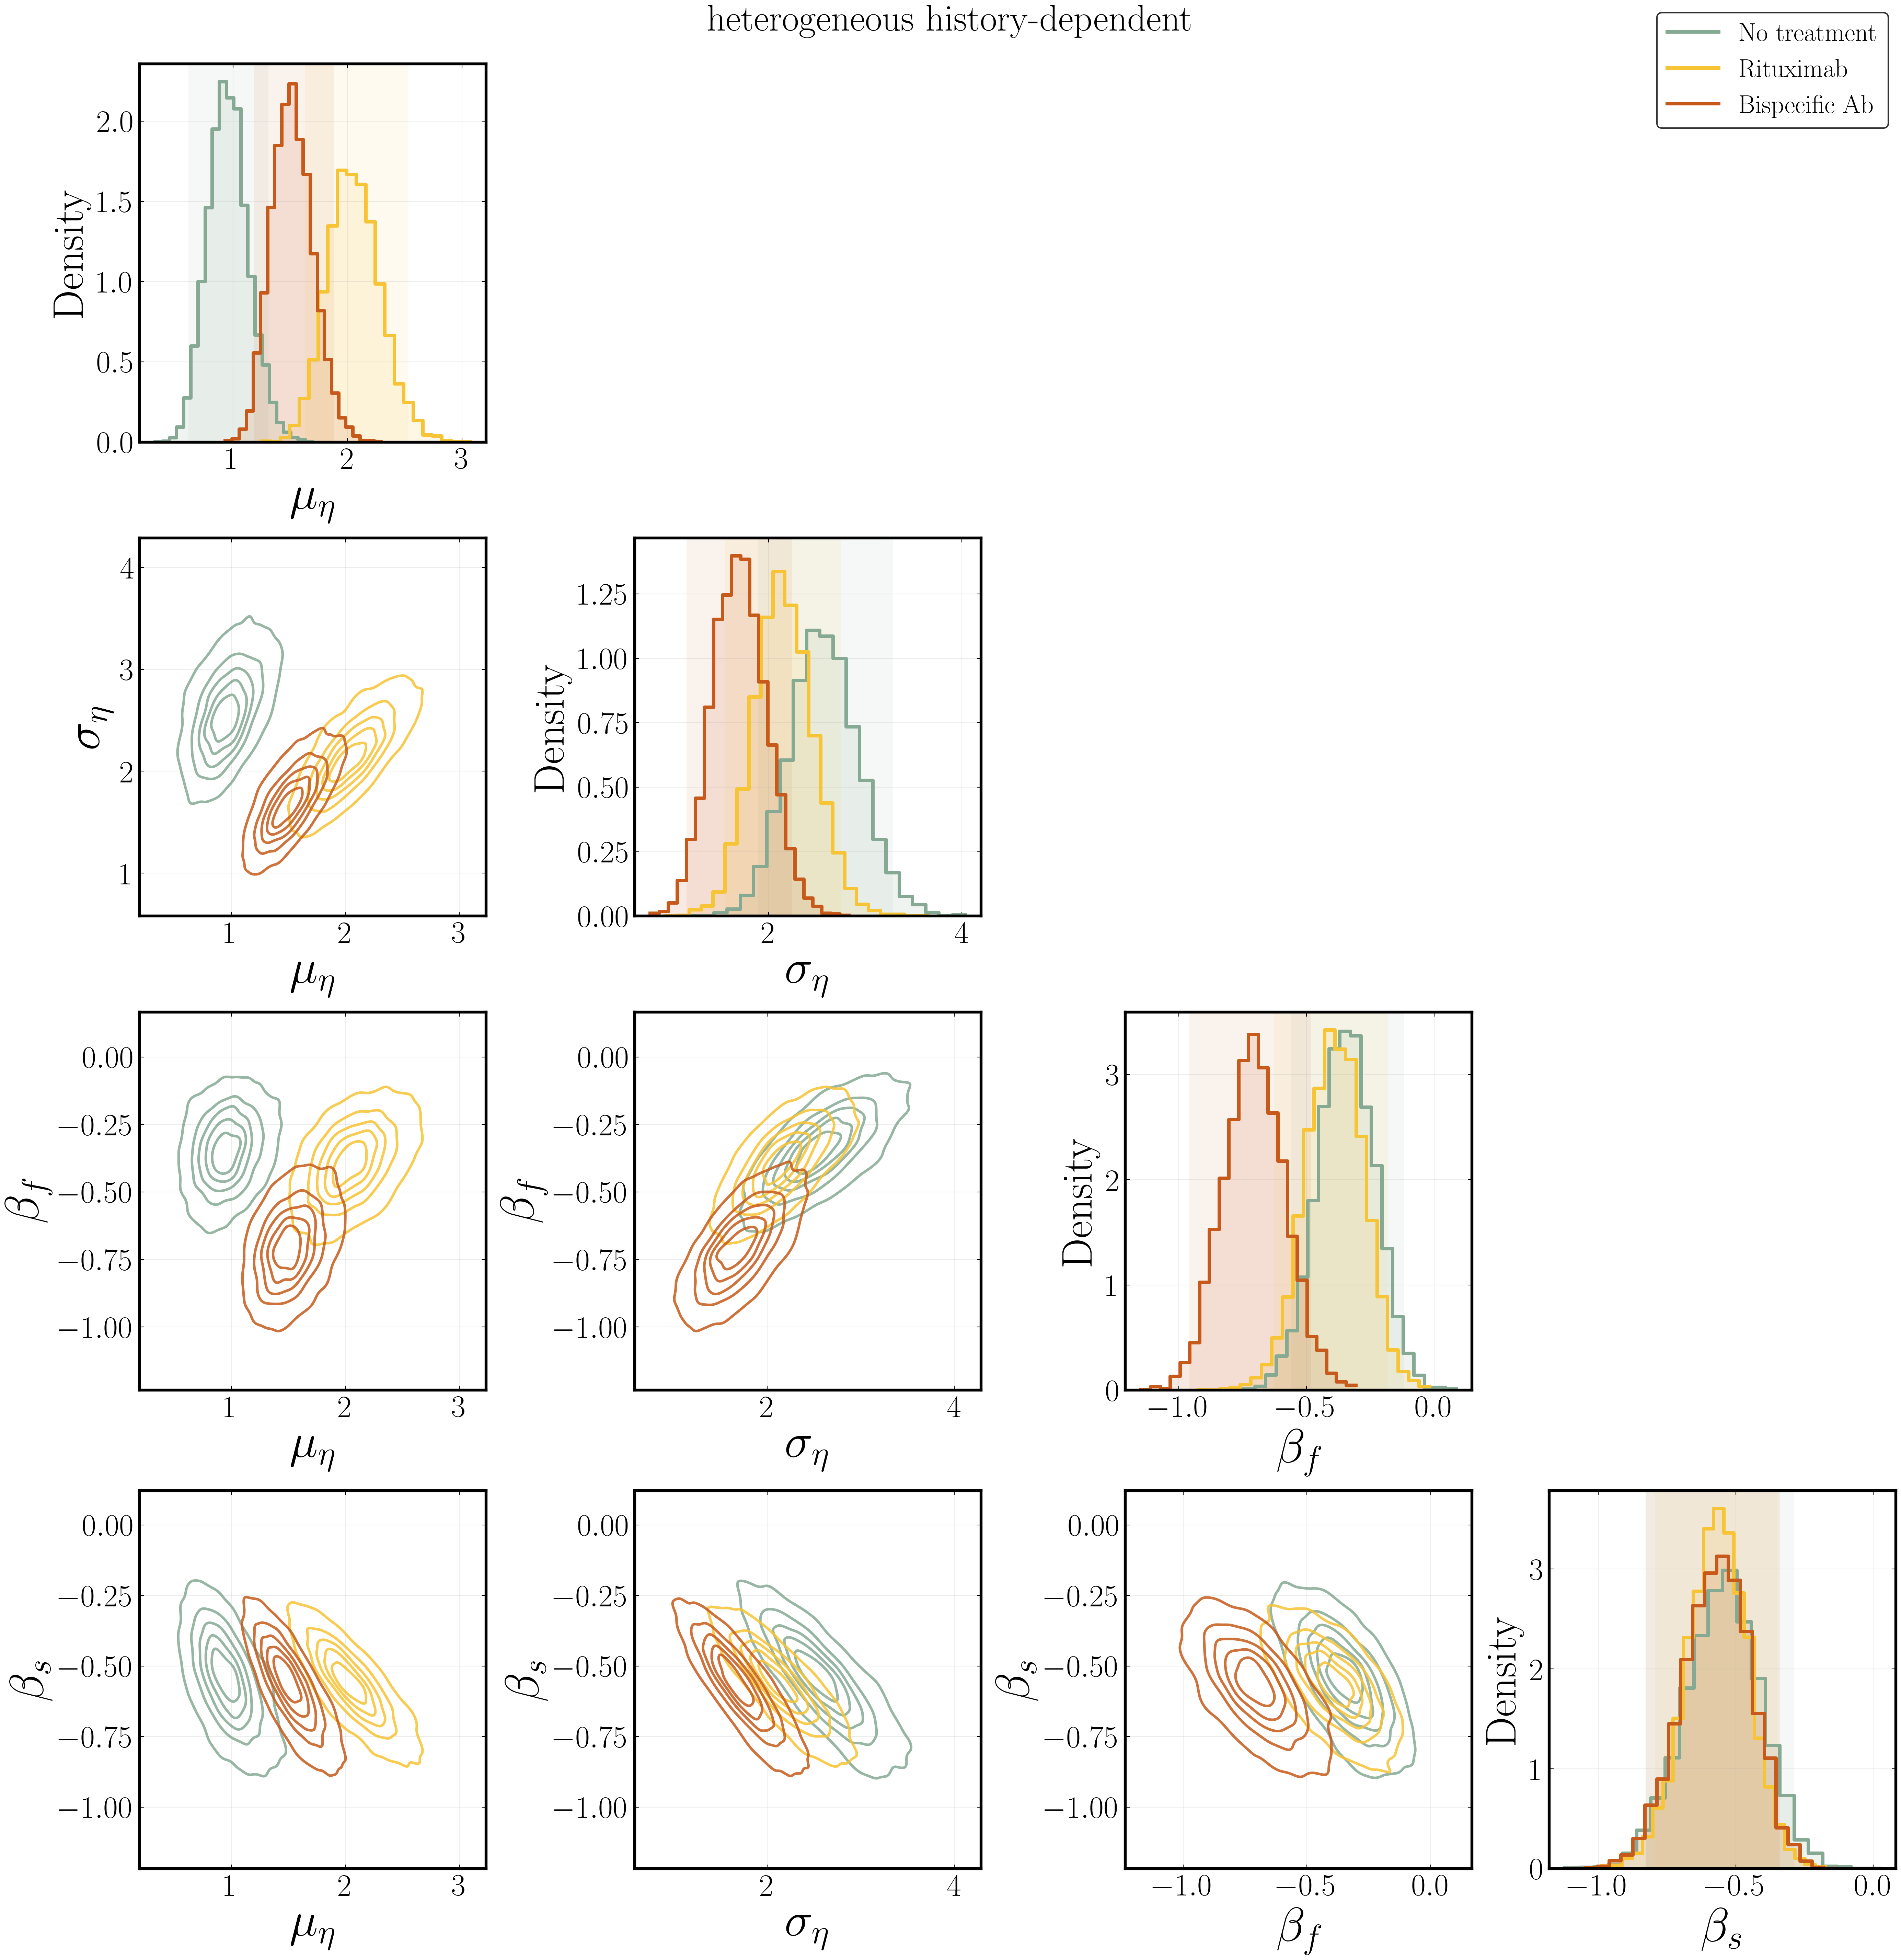

In [13]:
has_full_model = all(
    (condition, FULL_MODEL) in posterior_data
    for condition in CONDITION_ORDER
)

if has_full_model:
    run_posterior_plots(posterior_data, show=True)
else:
    missing = [
        condition
        for condition in CONDITION_ORDER
        if (condition, FULL_MODEL) not in posterior_data
    ]
    print("Full-model posteriors are not cached for:", missing)


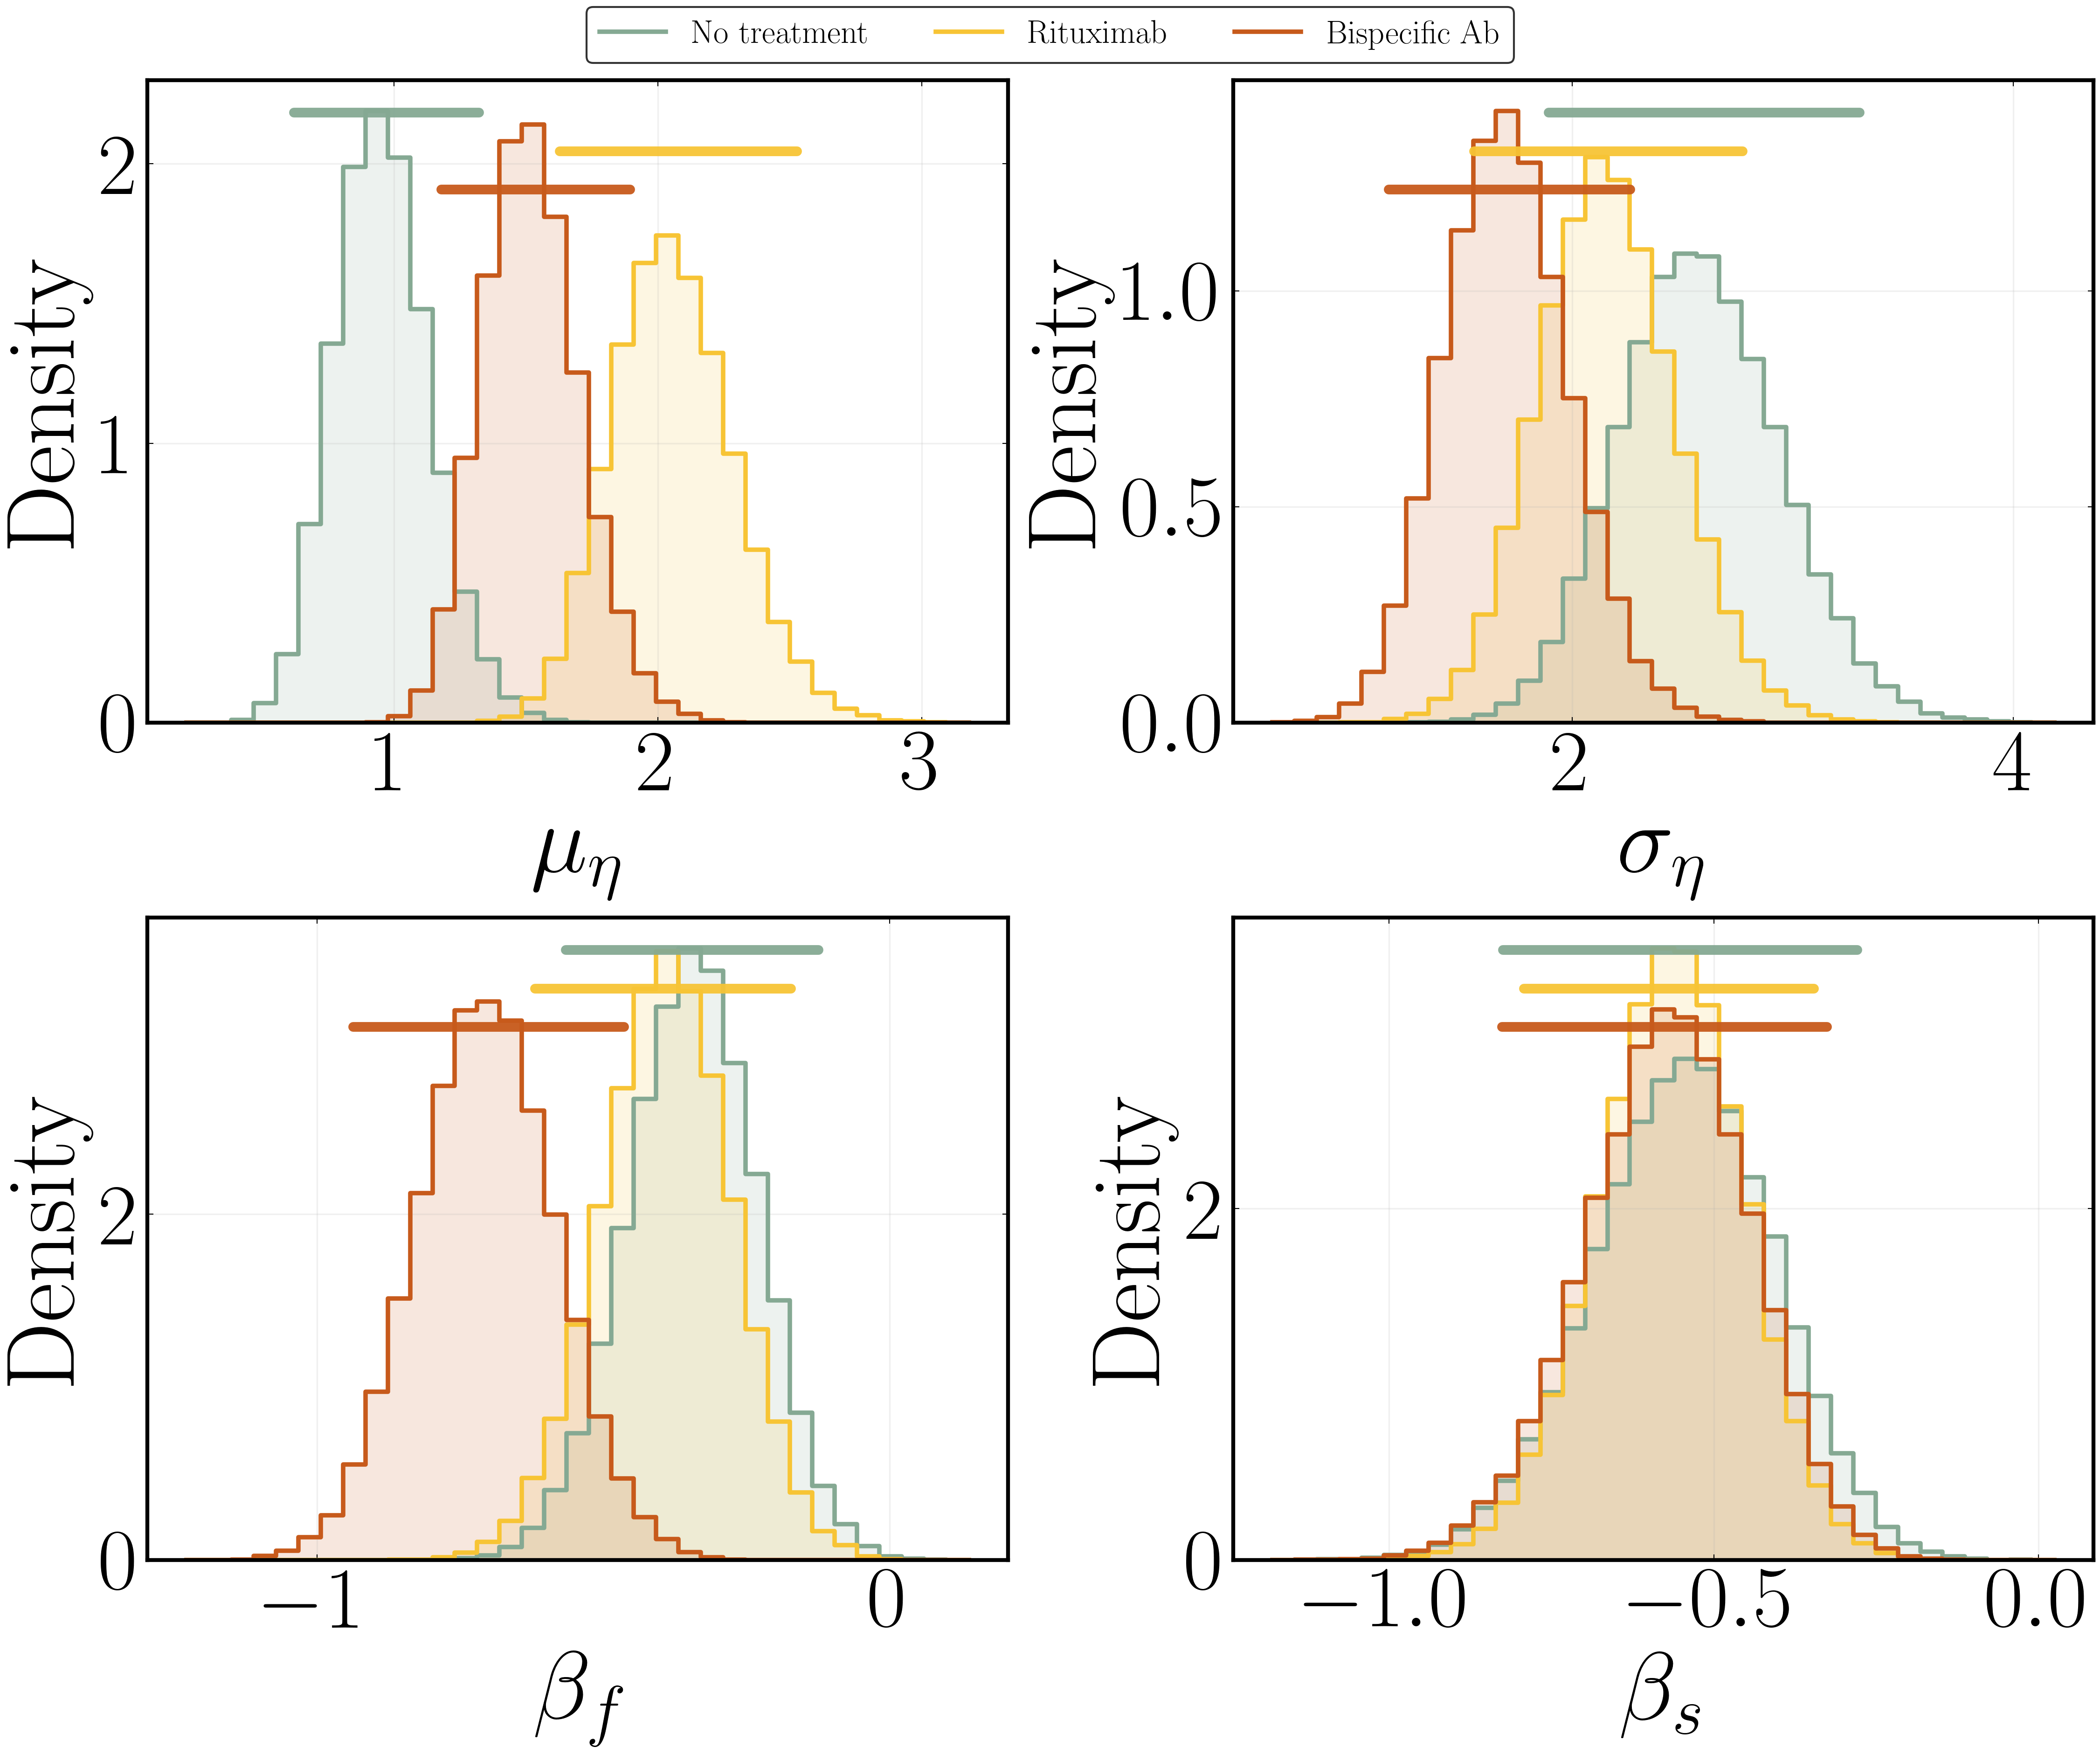

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/four_parameter_marginal_posteriors.svg')

In [14]:
def plot_four_marginal_posteriors(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    bins: int = 35,
    hdi_prob: float = 0.95,
    show: bool = True,
) -> Path | None:
    parameters = [
        "mu_eta",
        "sigma_eta",
        "beta_x",
        "beta_y",
    ]

    parameter_labels = {
        "mu_eta": r"$\mu_{\eta}$",
        "sigma_eta": r"$\sigma_{\eta}$",
        "beta_x": r"$\beta_f$",
        "beta_y": r"$\beta_s$",
    }

    missing = [
        condition
        for condition in conditions
        if (condition, model_name)
        not in posterior_data
    ]

    if missing:
        print(
            "Missing posterior data for:",
            missing,
        )
        return None

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 12),
        dpi=300,
        constrained_layout=True,
    )

    for ax, parameter in zip(
        axes.ravel(),
        parameters,
    ):
        parameter_samples = {}

        # Extract samples before plotting so all conditions
        # use identical histogram-bin edges.
        for condition in conditions:
            idata = posterior_data[
                (condition, model_name)
            ]

            if parameter not in idata.posterior:
                continue

            values = np.asarray(
                idata.posterior[parameter]
                .stack(
                    sample=("chain", "draw")
                )
                .values,
                dtype=float,
            ).ravel()

            values = values[
                np.isfinite(values)
            ]

            if values.size >= 2:
                parameter_samples[
                    condition
                ] = values

        if not parameter_samples:
            ax.text(
                0.5,
                0.5,
                f"No samples for {parameter}",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=16,
            )
            continue

        pooled_values = np.concatenate(
            list(parameter_samples.values())
        )

        bin_edges = np.histogram_bin_edges(
            pooled_values,
            bins=bins,
        )

        # Separate vertical positions for the HDI bars.
        hdi_positions = np.linspace(
            0.95,
            0.83,
            len(conditions),
        )

        for condition, hdi_y in zip(
            conditions,
            hdi_positions,
        ):
            if condition not in parameter_samples:
                continue

            values = parameter_samples[
                condition
            ]

            color = colors.get(
                condition,
                "black",
            )

            # Filled histogram.
            sns.histplot(
                x=values,
                bins=bin_edges,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.14,
                linewidth=0,
                ax=ax,
            )

            # Histogram outline.
            sns.histplot(
                x=values,
                bins=bin_edges,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.3,
                label=condition,
                ax=ax,
            )

            hdi_low, hdi_high = az.hdi(
                values,
                hdi_prob=hdi_prob,
            )

            median = float(
                np.median(values)
            )

            # The x coordinates use parameter units.
            # The y coordinate uses the panel height.
            ax.plot(
                [
                    float(hdi_low),
                    float(hdi_high),
                ],
                [
                    hdi_y,
                    hdi_y,
                ],
                transform=ax.get_xaxis_transform(),
                color=color,
                linewidth=5,
                solid_capstyle="round",
                alpha=0.95,
                zorder=10,
                clip_on=False,
            )

            # # Posterior median.
            # ax.scatter(
            #     [median],
            #     [hdi_y],
            #     transform=ax.get_xaxis_transform(),
            #     s=38,
            #     facecolor="white",
            #     edgecolor=color,
            #     linewidth=1.8,
            #     zorder=11,
            #     clip_on=False,
            # )

        # # Zero-reference line for history coefficients.
        # if parameter in {
        #     "beta_x",
        #     "beta_y",
        # }:
        #     ax.axvline(
        #         0,
        #         color="black",
        #         linewidth=1.3,
        #         linestyle="--",
        #         alpha=0.7,
        #         zorder=0,
        #     )

        ax.set_xlabel(
            parameter_labels[parameter],
            fontsize=50,
        )

        ax.set_ylabel(
            "Density",
            fontsize=50,
        )

        ax.tick_params(
            axis="both",
            labelsize=45,
        )

        ax.minorticks_off()

        ax.grid(
            alpha=0.18,
            linewidth=0.8,
        )

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(2)

    # Retrieve a single common legend.
    handles, labels = (
        axes[0, 0].get_legend_handles_labels()
    )

    for ax in axes.ravel():
        legend = ax.get_legend()

        if legend is not None:
            legend.remove()

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.05),
            ncol=len(conditions),
            frameon=True,
            edgecolor="black",
            fontsize=17,
        )


    figure_root = Path(
        figure_root
    )

    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "four_parameter_marginal_posteriors.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.15,
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


marginal_posterior_path = (
    plot_four_marginal_posteriors(
        posterior_data,
        model_name=FULL_MODEL,
        conditions=CONDITION_ORDER,
        colors=CONDITION_COLORS,
        figure_root=FIGURE_ROOT,
        bins=35,
        hdi_prob=0.95,
        show=True,
    )
)

marginal_posterior_path

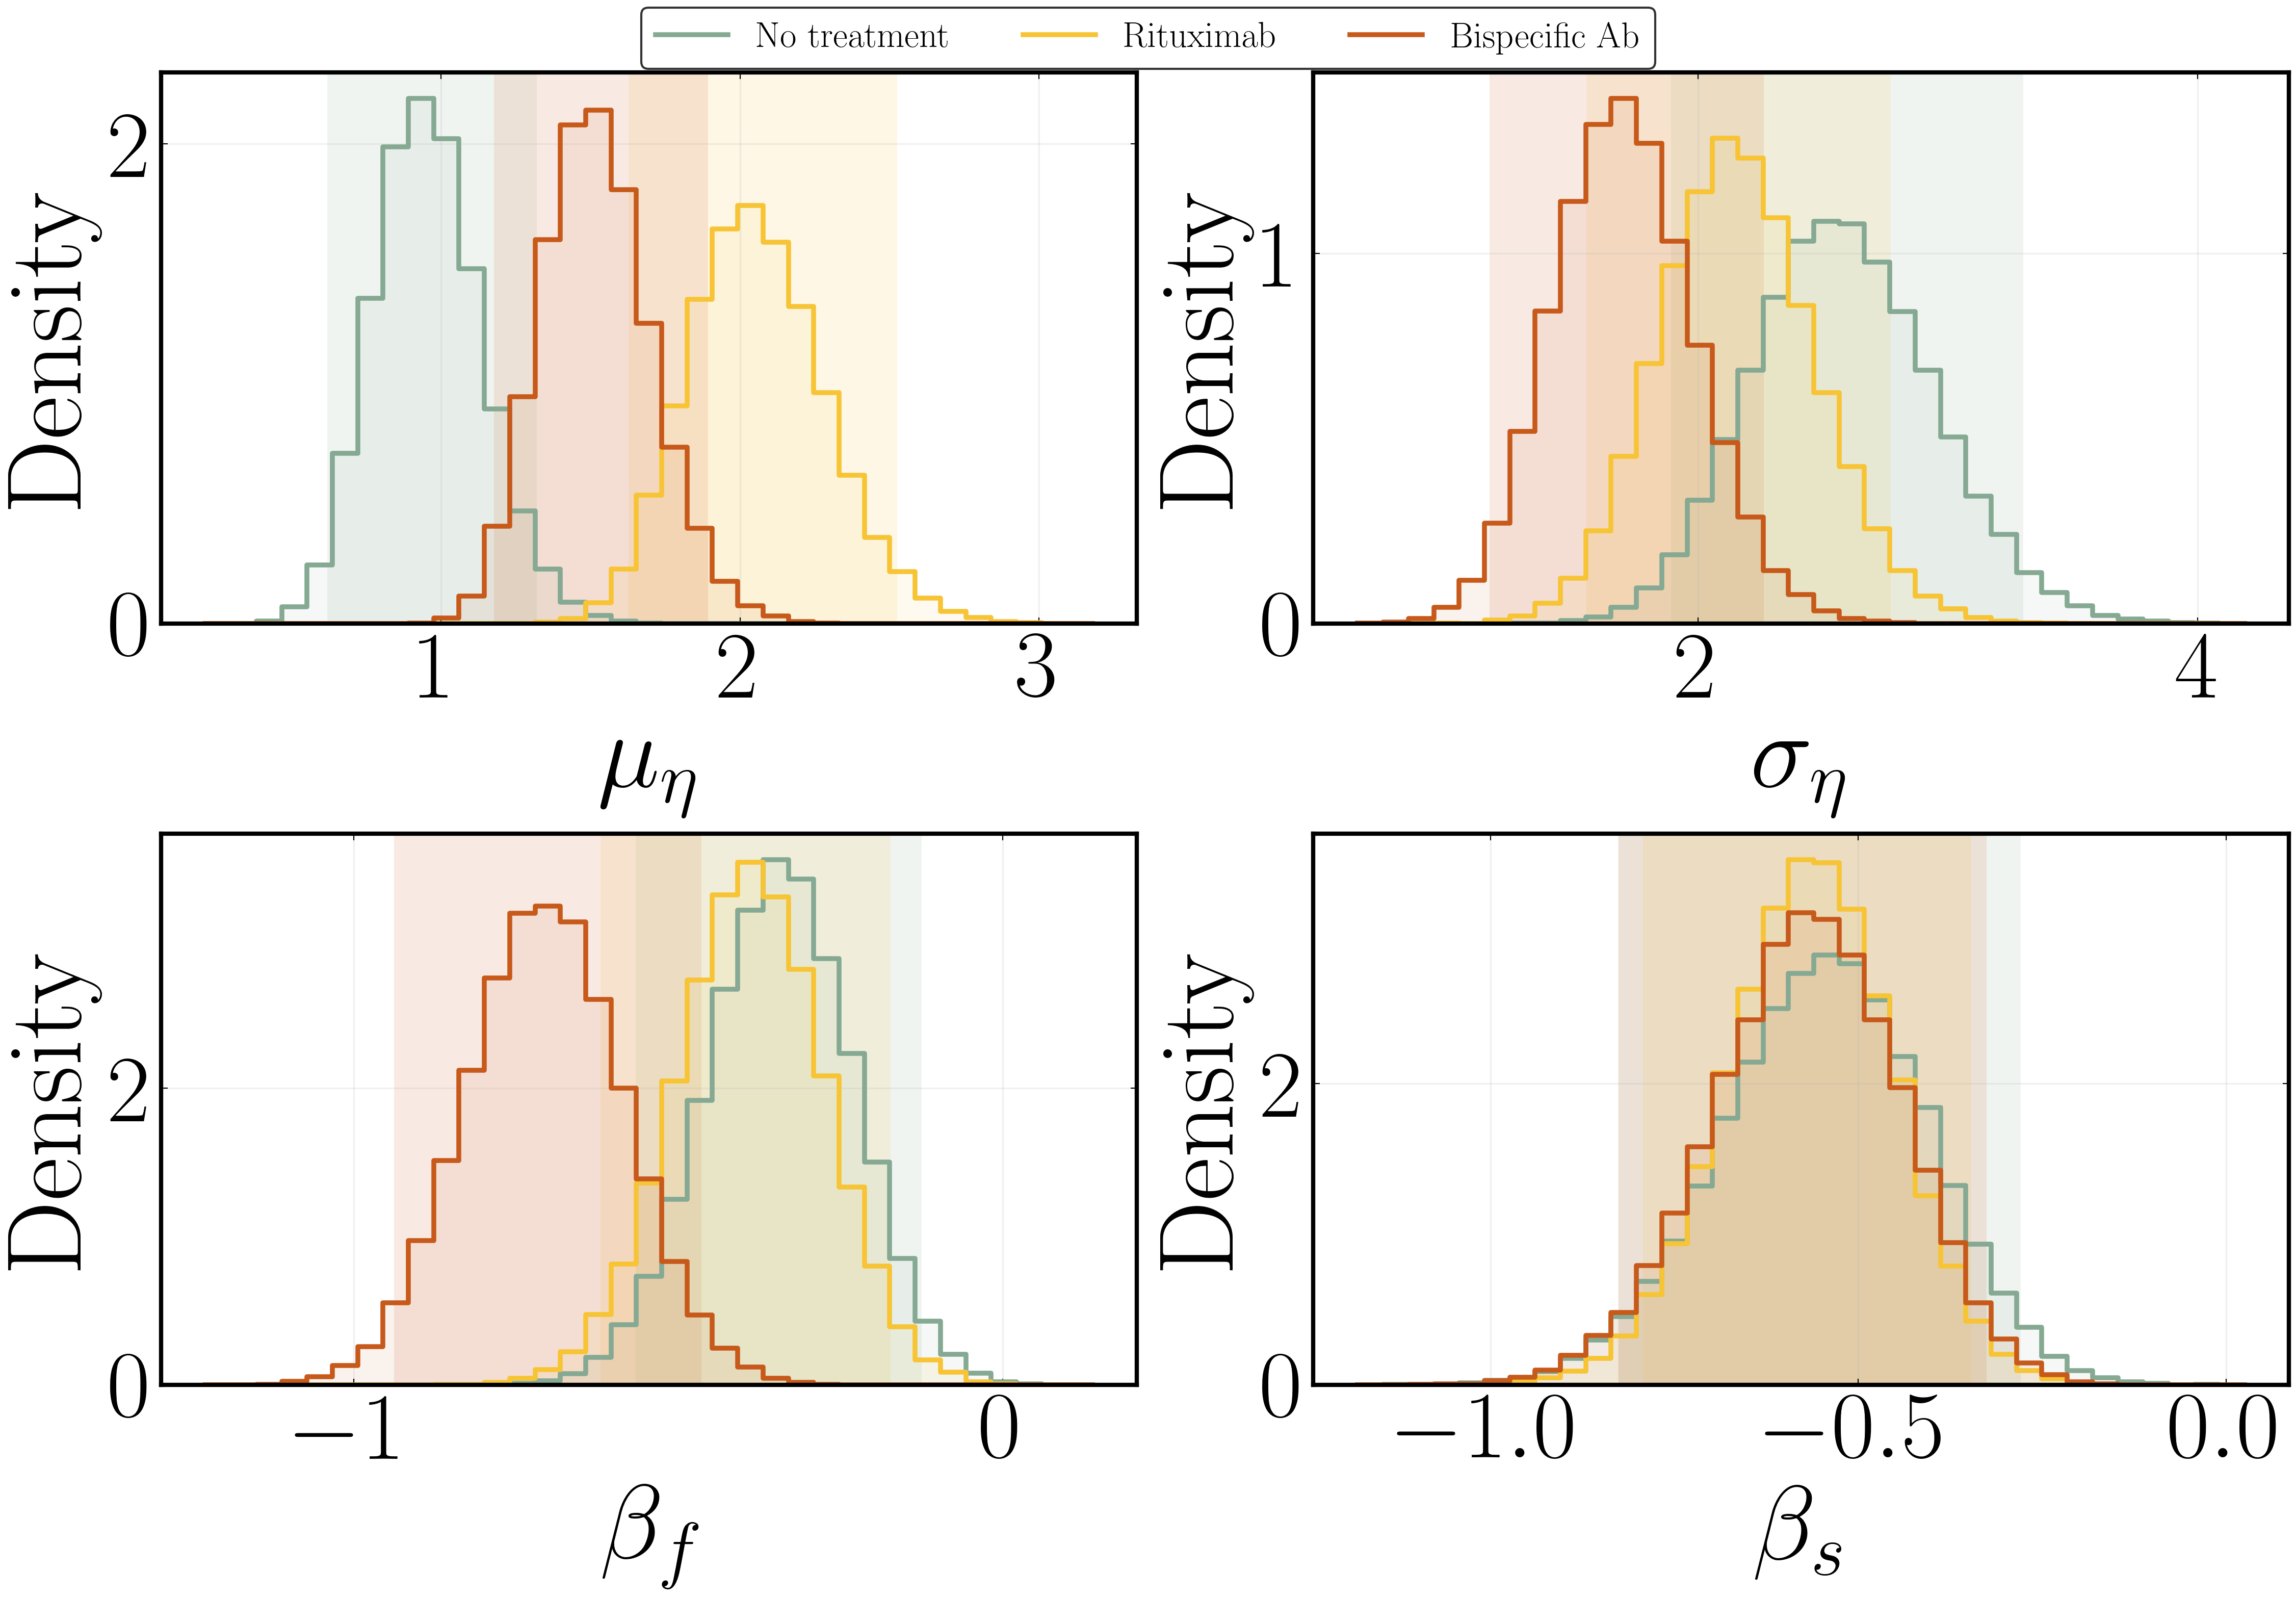

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/four_parameter_marginal_posteriors_hdi_band.svg')

In [24]:
def plot_four_marginal_posteriors_hdi_band(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    bins: int = 35,
    hdi_prob: float = 0.95,
    hdi_alpha: float = 0.12,
    show: bool = True,
) -> Path | None:
    parameters = [
        "mu_eta",
        "sigma_eta",
        "beta_x",
        "beta_y",
    ]

    parameter_labels = {
        "mu_eta": r"$\mu_{\eta}$",
        "sigma_eta": r"$\sigma_{\eta}$",
        "beta_x": r"$\beta_f$",
        "beta_y": r"$\beta_s$",
    }

    missing = [
        condition
        for condition in conditions
        if (condition, model_name) not in posterior_data
    ]

    if missing:
        print(
            "Missing posterior data for:",
            missing,
        )
        return None

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
        dpi=300,
        constrained_layout=True,
    )

    for ax, parameter in zip(
        axes.ravel(),
        parameters,
    ):
        parameter_samples = {}

        # Extract samples first so every condition uses
        # identical histogram-bin edges.
        for condition in conditions:
            idata = posterior_data[
                (condition, model_name)
            ]

            if parameter not in idata.posterior:
                continue

            values = np.asarray(
                idata.posterior[parameter]
                .stack(sample=("chain", "draw"))
                .values,
                dtype=float,
            ).ravel()

            values = values[
                np.isfinite(values)
            ]

            if values.size >= 2:
                parameter_samples[condition] = values

        if not parameter_samples:
            ax.text(
                0.5,
                0.5,
                f"No samples for {parameter}",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=16,
            )
            continue

        pooled_values = np.concatenate(
            list(parameter_samples.values())
        )

        bin_edges = np.histogram_bin_edges(
            pooled_values,
            bins=bins,
        )

        for condition in conditions:
            if condition not in parameter_samples:
                continue

            values = parameter_samples[condition]
            color = colors.get(condition, "black")

            hdi_low, hdi_high = az.hdi(
                values,
                hdi_prob=hdi_prob,
            )

            # HDI shown as a shaded vertical band.
            ax.axvspan(
                float(hdi_low),
                float(hdi_high),
                ymin=0,
                ymax=1,
                facecolor=color,
                edgecolor="none",
                alpha=hdi_alpha,
                zorder=0.5,
            )

            # Light posterior histogram fill.
            sns.histplot(
                x=values,
                bins=bin_edges,
                stat="density",
                element="step",
                fill=True,
                color=color,
                alpha=0.08,
                linewidth=0,
                ax=ax,
                zorder=1,
            )

            # Posterior histogram outline.
            sns.histplot(
                x=values,
                bins=bin_edges,
                stat="density",
                element="step",
                fill=False,
                color=color,
                linewidth=2.3,
                label=condition,
                ax=ax,
                zorder=2,
            )

        # # Zero-reference line for history coefficients.
        # if parameter in {"beta_x", "beta_y"}:
        #     ax.axvline(
        #         0,
        #         color="black",
        #         linewidth=1.3,
        #         linestyle="--",
        #         alpha=0.7,
        #         zorder=3,
        #     )

        ax.set_xlabel(
            parameter_labels[parameter],
            fontsize=50,
        )

        ax.set_ylabel(
            "Density",
            fontsize=50,
        )

        ax.tick_params(
            axis="both",
            labelsize=45,
        )

        ax.minorticks_off()

        ax.grid(
            alpha=0.18,
            linewidth=0.8,
        )

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(2)

    # Retrieve a single common legend.
    handles, labels = (
        axes[0, 0].get_legend_handles_labels()
    )

    for ax in axes.ravel():
        legend = ax.get_legend()

        if legend is not None:
            legend.remove()

    if handles:
        fig.legend(
            handles,
            labels,
            # title=f"Shaded bands: {hdi_prob:.0%} HDI",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.05),
            ncol=len(conditions),
            frameon=True,
            edgecolor="black",
            fontsize=17,
            title_fontsize=17,
        )

    figure_root = Path(figure_root)

    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "four_parameter_marginal_posteriors_hdi_band.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.15,
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path


marginal_posterior_hdi_band_path = (
    plot_four_marginal_posteriors_hdi_band(
        posterior_data,
        model_name=FULL_MODEL,
        conditions=CONDITION_ORDER,
        colors=CONDITION_COLORS,
        figure_root=FIGURE_ROOT,
        bins=35,
        hdi_prob=0.95,
        hdi_alpha=0.12,
        show=True,
    )
)

marginal_posterior_hdi_band_path

In [15]:
from itertools import combinations


def posterior_condition_difference_probabilities(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    parameters: Sequence[str] = (
        "mu_eta",
        "sigma_eta",
        "beta_x",
        "beta_y",
    ),
    practical_differences: dict[str, float] | None = None,
) -> pd.DataFrame:
    """
    Compare independently fitted condition-specific posteriors.

    For each parameter and pair of conditions, calculate:

        P(theta_A > theta_B)
        P(theta_A < theta_B)

    Optionally, for a scientifically meaningful threshold delta:

        P(theta_A - theta_B > delta)
        P(theta_A - theta_B < -delta)
        P(|theta_A - theta_B| <= delta)

    All empirical cross-particle combinations are included.
    """
    if practical_differences is None:
        practical_differences = {}

    parameter_labels = {
        "mu_eta": r"$\mu_{\eta}$",
        "sigma_eta": r"$\sigma_{\eta}$",
        "beta_x": r"$\beta_f$",
        "beta_y": r"$\beta_s$",
    }

    def extract_samples(
        condition: str,
        parameter: str,
    ) -> np.ndarray:
        key = (
            condition,
            model_name,
        )

        if key not in posterior_data:
            return np.array(
                [],
                dtype=float,
            )

        idata = posterior_data[key]

        if parameter not in idata.posterior:
            return np.array(
                [],
                dtype=float,
            )

        values = np.asarray(
            idata.posterior[parameter]
            .stack(
                sample=("chain", "draw")
            )
            .values,
            dtype=float,
        ).ravel()

        return values[
            np.isfinite(values)
        ]

    rows = []

    for parameter in parameters:
        delta = float(
            practical_differences.get(
                parameter,
                0.0,
            )
        )

        if delta < 0:
            raise ValueError(
                "Practical-difference thresholds must be non-negative."
            )

        for condition_a, condition_b in combinations(
            conditions,
            2,
        ):
            samples_a = extract_samples(
                condition_a,
                parameter,
            )

            samples_b = extract_samples(
                condition_b,
                parameter,
            )

            if (
                samples_a.size == 0
                or samples_b.size == 0
            ):
                continue

            # Sorting B allows all pairwise probabilities to be
            # calculated without materialising an N_A × N_B array.
            sorted_b = np.sort(
                samples_b
            )

            total_pairs = (
                samples_a.size
                * samples_b.size
            )

            # P(A > B): for every A particle, count B particles
            # strictly smaller than it.
            n_a_greater_b = np.searchsorted(
                sorted_b,
                samples_a,
                side="left",
            ).sum(dtype=np.int64)

            # P(A < B): for every A particle, count B particles
            # strictly greater than it.
            n_a_less_b = (
                samples_b.size
                - np.searchsorted(
                    sorted_b,
                    samples_a,
                    side="right",
                )
            ).sum(dtype=np.int64)

            p_a_greater_b = (
                n_a_greater_b
                / total_pairs
            )

            p_a_less_b = (
                n_a_less_b
                / total_pairs
            )

            p_equal = max(
                0.0,
                1.0
                - p_a_greater_b
                - p_a_less_b,
            )

            # Practical positive difference:
            # A - B > delta means B < A - delta.
            n_difference_gt_delta = np.searchsorted(
                sorted_b,
                samples_a - delta,
                side="left",
            ).sum(dtype=np.int64)

            p_difference_gt_delta = (
                n_difference_gt_delta
                / total_pairs
            )

            # Practical negative difference:
            # A - B < -delta means B > A + delta.
            n_difference_lt_minus_delta = (
                samples_b.size
                - np.searchsorted(
                    sorted_b,
                    samples_a + delta,
                    side="right",
                )
            ).sum(dtype=np.int64)

            p_difference_lt_minus_delta = (
                n_difference_lt_minus_delta
                / total_pairs
            )

            p_within_practical_range = max(
                0.0,
                1.0
                - p_difference_gt_delta
                - p_difference_lt_minus_delta,
            )

            if p_a_greater_b >= p_a_less_b:
                supported_direction = (
                    f"{condition_a} > {condition_b}"
                )
                direction_probability = (
                    p_a_greater_b
                )
            else:
                supported_direction = (
                    f"{condition_a} < {condition_b}"
                )
                direction_probability = (
                    p_a_less_b
                )

            rows.append(
                {
                    "parameter": parameter,
                    "parameter_label": (
                        parameter_labels.get(
                            parameter,
                            parameter,
                        )
                    ),
                    "condition_A": condition_a,
                    "condition_B": condition_b,
                    "n_particles_A": int(
                        samples_a.size
                    ),
                    "n_particles_B": int(
                        samples_b.size
                    ),
                    "n_cross_particle_pairs": int(
                        total_pairs
                    ),
                    "mean_A": float(
                        np.mean(samples_a)
                    ),
                    "mean_B": float(
                        np.mean(samples_b)
                    ),
                    "difference_of_means_A_minus_B": float(
                        np.mean(samples_a)
                        - np.mean(samples_b)
                    ),
                    "P_A_greater_B": float(
                        p_a_greater_b
                    ),
                    "P_A_less_B": float(
                        p_a_less_b
                    ),
                    "P_A_equal_B": float(
                        p_equal
                    ),
                    "supported_direction": (
                        supported_direction
                    ),
                    "direction_probability": float(
                        direction_probability
                    ),
                    "practical_difference_delta": delta,
                    "P_A_minus_B_greater_delta": float(
                        p_difference_gt_delta
                    ),
                    "P_A_minus_B_less_minus_delta": float(
                        p_difference_lt_minus_delta
                    ),
                    "P_abs_difference_within_delta": float(
                        p_within_practical_range
                    ),
                }
            )

    return pd.DataFrame(
        rows
    )


# Set delta=0 for directional comparisons.
# Replace these with scientifically meaningful minimum differences
# if you want a ROPE/practical-equivalence analysis.
practical_differences = {
    "mu_eta": 0.0,
    "sigma_eta": 0.0,
    "beta_x": 0.0,
    "beta_y": 0.0,
}

condition_difference_probabilities = (
    posterior_condition_difference_probabilities(
        posterior_data,
        model_name=FULL_MODEL,
        conditions=CONDITION_ORDER,
        parameters=(
            "mu_eta",
            "sigma_eta",
            "beta_x",
            "beta_y",
        ),
        practical_differences=practical_differences,
    )
)

display_columns = [
    "parameter_label",
    "condition_A",
    "condition_B",
    "difference_of_means_A_minus_B",
    "P_A_greater_B",
    "P_A_less_B",
    "supported_direction",
    "direction_probability",
]

display(
    condition_difference_probabilities[
        display_columns
    ].round(4)
)

difference_path = (
    RESULT_ROOT
    / "posterior_condition_difference_probabilities.csv"
)

condition_difference_probabilities.to_csv(
    difference_path,
    index=False,
)

difference_path

,parameter_label,condition_A,condition_B,difference_of_means_A_minus_B,P_A_greater_B,P_A_less_B,supported_direction,direction_probability
0,$\mu_{\eta}$,No treatment,Rituximab,-1.1001,0.0001,0.9999,No treatment < Rituximab,0.9999
1,$\mu_{\eta}$,No treatment,Bispecific Ab,-0.5641,0.0142,0.9858,No treatment < Bispecific Ab,0.9858
2,$\mu_{\eta}$,Rituximab,Bispecific Ab,0.5360,0.9673,0.0327,Rituximab > Bispecific Ab,0.9673
3,$\sigma_{\eta}$,No treatment,Rituximab,0.4233,0.8123,0.1877,No treatment > Rituximab,0.8123
4,$\sigma_{\eta}$,No treatment,Bispecific Ab,0.8767,0.9729,0.0271,No treatment > Bispecific Ab,0.9729
5,$\sigma_{\eta}$,Rituximab,Bispecific Ab,0.4534,0.8609,0.1391,Rituximab > Bispecific Ab,0.8609
6,$\beta_f$,No treatment,Rituximab,0.0463,0.6136,0.3864,No treatment > Rituximab,0.6136
7,$\beta_f$,No treatment,Bispecific Ab,0.3606,0.9850,0.0150,No treatment > Bispecific Ab,0.9850
8,$\beta_f$,Rituximab,Bispecific Ab,0.3143,0.9699,0.0301,Rituximab > Bispecific Ab,0.9699
9,$\beta_s$,No treatment,Rituximab,0.0197,0.5455,0.4545,No treatment > Rituximab,0.5455


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/results/analysis_2/posterior_condition_difference_probabilities.csv')

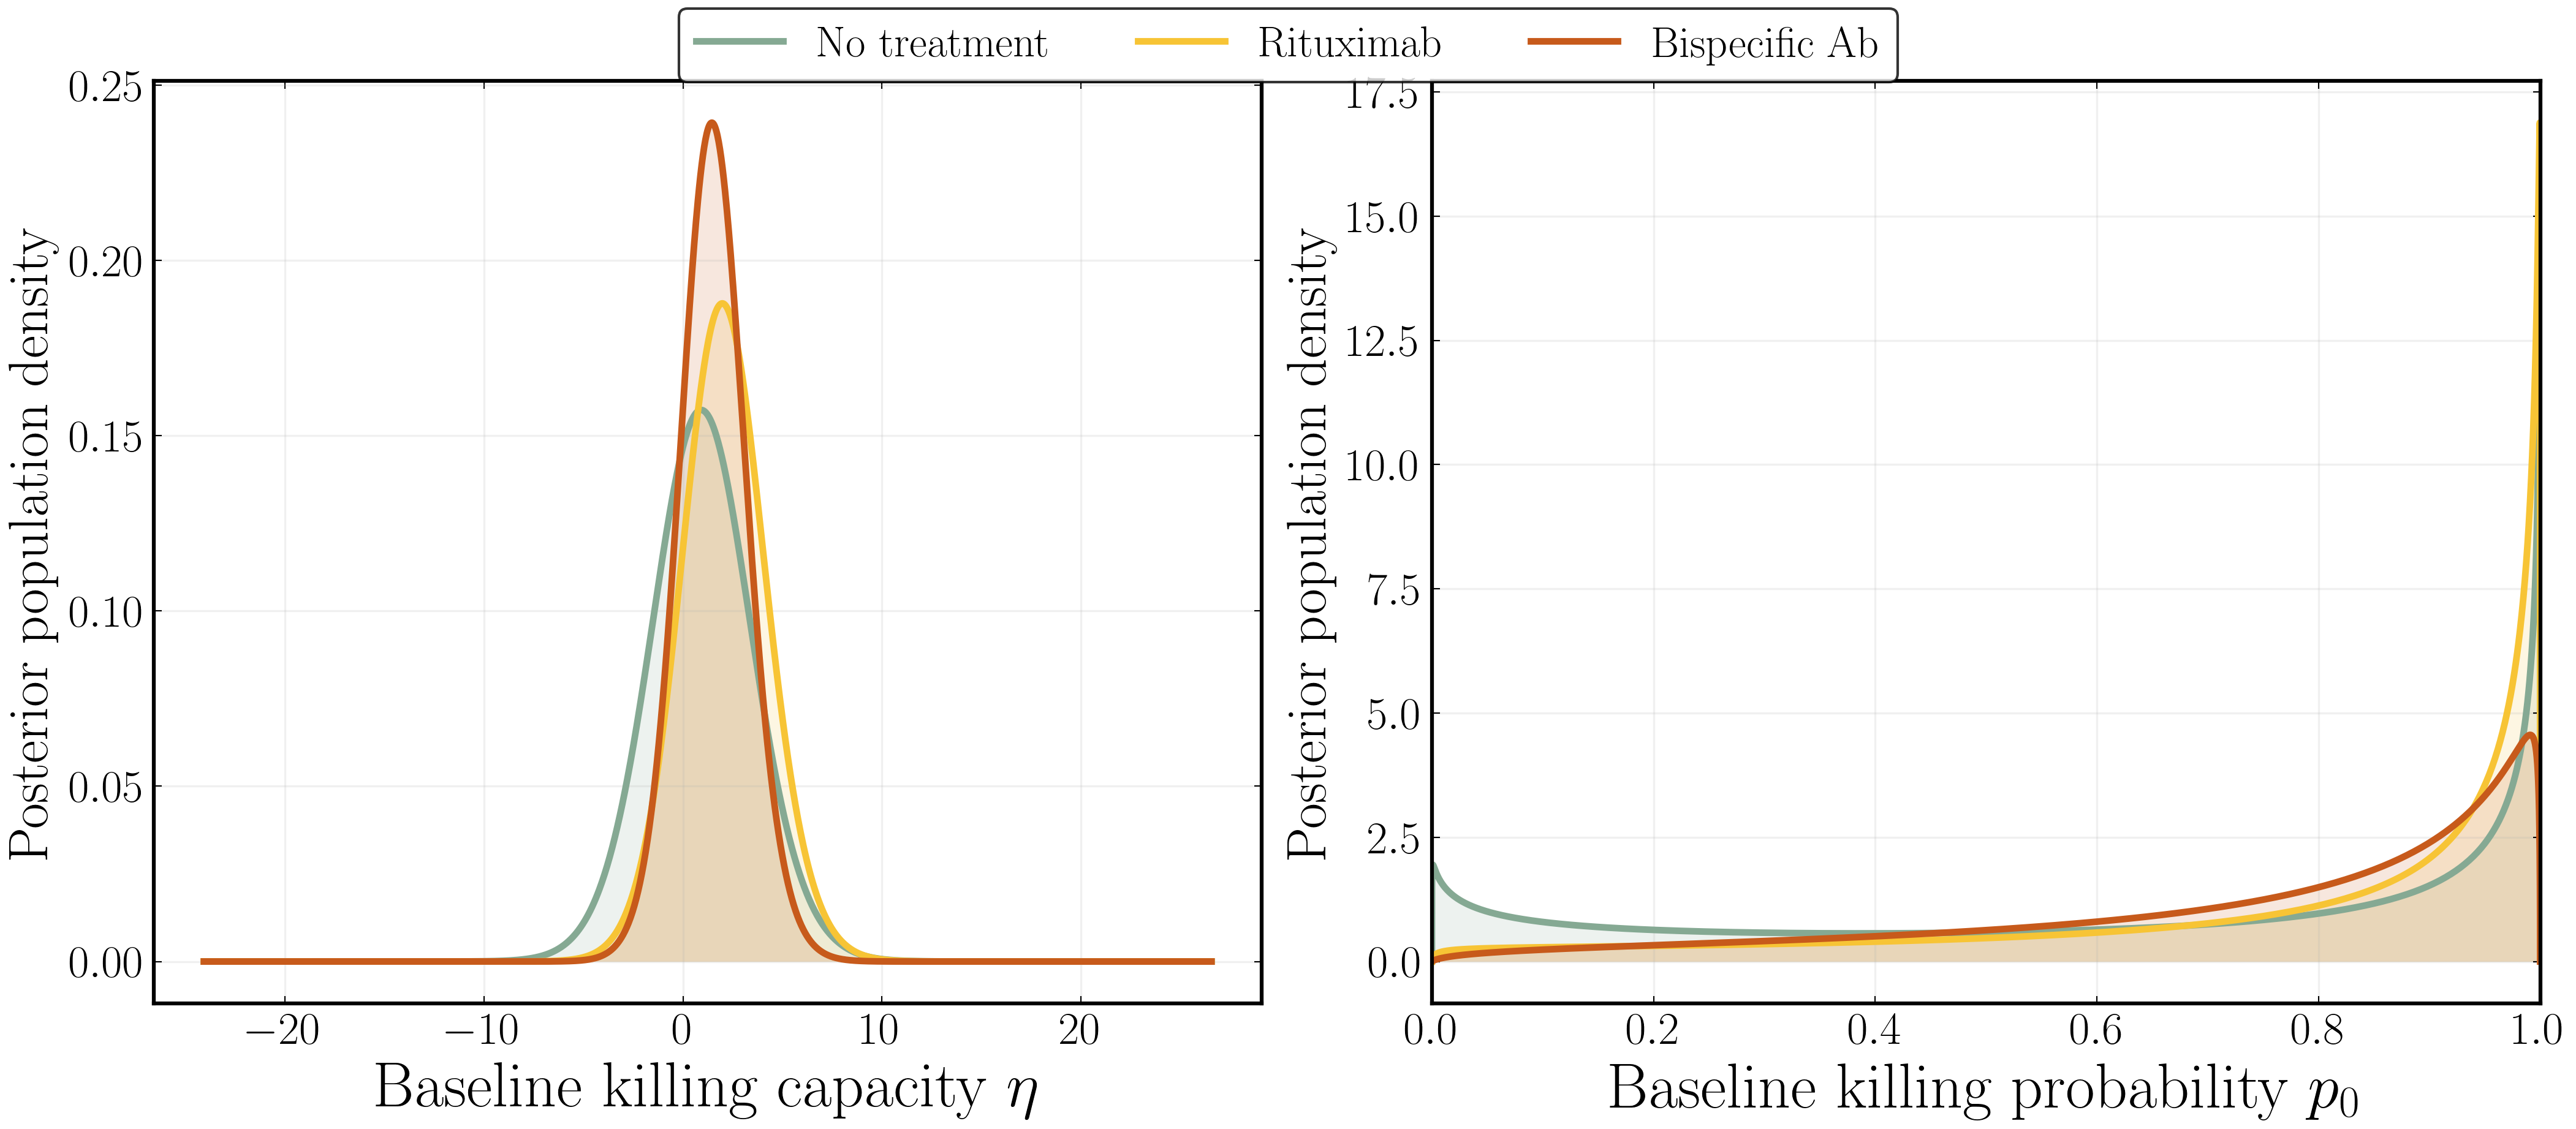

,condition,posterior_particles,eta_mean,eta_sd,eta_q025,eta_median,eta_q975,p0_mean,p0_sd,p0_q025,p0_median,p0_q975
0,No treatment,60000,0.957234,2.613054,-4.170857,0.943853,6.158393,0.620408,0.335442,0.015204,0.719877,0.997889
1,Rituximab,60000,2.057362,2.192525,-2.207687,2.031887,6.460547,0.770469,0.260153,0.099062,0.884105,0.998439
2,Bispecific Ab,60000,1.521320,1.737597,-1.864141,1.499363,5.024058,0.734661,0.244888,0.134221,0.817479,0.993465


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/baseline_eta_and_p0_population_distributions.svg')

In [16]:
from numpy.polynomial.hermite import hermgauss
from scipy.special import expit, ndtr


def _normal_mixture_pdf_cdf(
    grid: np.ndarray,
    mu: np.ndarray,
    sigma: np.ndarray,
    *,
    chunk_size: int = 2048,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Evaluate an equally weighted mixture of Normal distributions.

    Each paired posterior particle (mu[i], sigma[i]) defines
    one component of the posterior population distribution.
    """
    grid = np.asarray(
        grid,
        dtype=float,
    )

    mu = np.asarray(
        mu,
        dtype=float,
    )

    sigma = np.maximum(
        np.asarray(
            sigma,
            dtype=float,
        ),
        1e-10,
    )

    pdf_sum = np.zeros_like(
        grid,
        dtype=float,
    )

    cdf_sum = np.zeros_like(
        grid,
        dtype=float,
    )

    normalising_constant = np.sqrt(
        2.0 * np.pi
    )

    for start in range(
        0,
        mu.size,
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            mu.size,
        )

        chunk_mu = mu[
            start:stop
        ][None, :]

        chunk_sigma = sigma[
            start:stop
        ][None, :]

        z = (
            grid[:, None]
            - chunk_mu
        ) / chunk_sigma

        pdf_sum += np.sum(
            np.exp(-0.5 * z**2)
            / (
                normalising_constant
                * chunk_sigma
            ),
            axis=1,
        )

        cdf_sum += np.sum(
            ndtr(z),
            axis=1,
        )

    return (
        pdf_sum / mu.size,
        cdf_sum / mu.size,
    )


def reconstruct_baseline_population(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    grid_size: int = 1600,
    quadrature_nodes: int = 50,
    show: bool = True,
) -> tuple[Path | None, pd.DataFrame]:
    """
    Reconstruct posterior population distributions of eta and p0.

    eta ~ Normal(mu_eta, sigma_eta)
    p0  = sigmoid(eta)

    All paired posterior particles of mu_eta and sigma_eta are used.
    """
    hyperparameters = {}

    for condition in conditions:
        key = (
            condition,
            model_name,
        )

        if key not in posterior_data:
            continue

        idata = posterior_data[key]

        required = {
            "mu_eta",
            "sigma_eta",
        }

        if not required.issubset(
            idata.posterior.data_vars
        ):
            continue

        # Stack jointly to preserve the posterior pairing between
        # mu_eta and sigma_eta.
        posterior = (
            idata.posterior[
                [
                    "mu_eta",
                    "sigma_eta",
                ]
            ]
            .stack(
                sample=("chain", "draw")
            )
        )

        mu_eta = np.asarray(
            posterior["mu_eta"].values,
            dtype=float,
        ).ravel()

        sigma_eta = np.asarray(
            posterior["sigma_eta"].values,
            dtype=float,
        ).ravel()

        finite = (
            np.isfinite(mu_eta)
            & np.isfinite(sigma_eta)
            & (sigma_eta >= 0)
        )

        mu_eta = mu_eta[finite]
        sigma_eta = sigma_eta[finite]

        if mu_eta.size:
            hyperparameters[
                condition
            ] = (
                mu_eta,
                sigma_eta,
            )

    if not hyperparameters:
        print(
            "No posterior mu_eta and sigma_eta samples were found."
        )
        return None, pd.DataFrame()

    # Common eta grid for comparisons between conditions.
    eta_lower = min(
        np.min(mu_eta - 6.0 * sigma_eta)
        for mu_eta, sigma_eta
        in hyperparameters.values()
    )

    eta_upper = max(
        np.max(mu_eta + 6.0 * sigma_eta)
        for mu_eta, sigma_eta
        in hyperparameters.values()
    )

    if not np.isfinite(
        [eta_lower, eta_upper]
    ).all():
        raise ValueError(
            "The reconstructed eta limits are not finite."
        )

    if eta_upper <= eta_lower:
        eta_lower -= 1.0
        eta_upper += 1.0

    eta_grid = np.linspace(
        eta_lower,
        eta_upper,
        grid_size,
    )

    # Gauss-Hermite nodes for accurately calculating moments
    # of sigmoid(eta) without randomly sampling cells.
    gh_nodes, gh_weights = hermgauss(
        quadrature_nodes
    )

    gh_weights = (
        gh_weights
        / np.sqrt(np.pi)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.8),
        dpi=300,
        constrained_layout=True,
    )

    ax_eta, ax_p0 = axes

    summary_rows = []

    for condition in conditions:
        if condition not in hyperparameters:
            continue

        mu_eta, sigma_eta = (
            hyperparameters[condition]
        )

        color = colors.get(
            condition,
            "black",
        )

        # Mixture over every posterior hyperparameter particle.
        eta_density, eta_cdf = (
            _normal_mixture_pdf_cdf(
                eta_grid,
                mu_eta,
                sigma_eta,
            )
        )

        # Since p0 = sigmoid(eta), transform the grid and density
        # using the appropriate Jacobian.
        p0_grid = expit(
            eta_grid
        )

        safe_p0 = np.clip(
            p0_grid,
            1e-12,
            1.0 - 1e-12,
        )

        p0_density = (
            eta_density
            / (
                safe_p0
                * (1.0 - safe_p0)
            )
        )

        # Population eta distribution.
        ax_eta.fill_between(
            eta_grid,
            eta_density,
            color=color,
            alpha=0.14,
            linewidth=0,
        )

        ax_eta.plot(
            eta_grid,
            eta_density,
            color=color,
            linewidth=2.6,
            label=condition,
        )

        # Population baseline killing-probability distribution.
        ax_p0.fill_between(
            p0_grid,
            p0_density,
            color=color,
            alpha=0.14,
            linewidth=0,
        )

        ax_p0.plot(
            p0_grid,
            p0_density,
            color=color,
            linewidth=2.6,
            label=condition,
        )

        # Central posterior population interval and median.
        eta_quantiles = np.interp(
            [
                0.025,
                0.50,
                0.975,
            ],
            eta_cdf,
            eta_grid,
        )

        p0_quantiles = expit(
            eta_quantiles
        )

        # Exact mixture mean and variance for eta.
        eta_mean = float(
            np.mean(mu_eta)
        )

        eta_second_moment = float(
            np.mean(
                sigma_eta**2
                + mu_eta**2
            )
        )

        eta_sd = float(
            np.sqrt(
                max(
                    eta_second_moment
                    - eta_mean**2,
                    0.0,
                )
            )
        )

        # Population moments of p0, integrated separately for
        # every posterior particle.
        eta_quadrature = (
            mu_eta[:, None]
            + np.sqrt(2.0)
            * sigma_eta[:, None]
            * gh_nodes[None, :]
        )

        p0_quadrature = expit(
            eta_quadrature
        )

        conditional_p0_mean = (
            p0_quadrature
            @ gh_weights
        )

        conditional_p0_second = (
            p0_quadrature**2
            @ gh_weights
        )

        p0_mean = float(
            np.mean(
                conditional_p0_mean
            )
        )

        p0_second_moment = float(
            np.mean(
                conditional_p0_second
            )
        )

        p0_sd = float(
            np.sqrt(
                max(
                    p0_second_moment
                    - p0_mean**2,
                    0.0,
                )
            )
        )

        summary_rows.append(
            {
                "condition": condition,
                "posterior_particles": int(
                    mu_eta.size
                ),
                "eta_mean": eta_mean,
                "eta_sd": eta_sd,
                "eta_q025": float(
                    eta_quantiles[0]
                ),
                "eta_median": float(
                    eta_quantiles[1]
                ),
                "eta_q975": float(
                    eta_quantiles[2]
                ),
                "p0_mean": p0_mean,
                "p0_sd": p0_sd,
                "p0_q025": float(
                    p0_quantiles[0]
                ),
                "p0_median": float(
                    p0_quantiles[1]
                ),
                "p0_q975": float(
                    p0_quantiles[2]
                ),
            }
        )

    ax_eta.set_xlabel(
        r"Baseline killing capacity $\eta$",
        fontsize=25,
    )

    ax_eta.set_ylabel(
        "Posterior population density",
        fontsize=22,
    )

    ax_p0.set_xlabel(
        r"Baseline killing probability $p_0$",
        fontsize=25,
    )

    ax_p0.set_ylabel(
        "Posterior population density",
        fontsize=22,
    )

    ax_p0.set_xlim(
        0,
        1,
    )

    for ax in axes:
        ax.tick_params(
            axis="both",
            labelsize=18,
        )

        ax.minorticks_off()

        ax.grid(
            alpha=0.18,
            linewidth=0.8,
        )

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.5)

    handles, labels = (
        ax_eta.get_legend_handles_labels()
    )

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.07),
            ncol=len(handles),
            frameon=True,
            edgecolor="black",
            fontsize=17,
        )

    figure_root = Path(
        figure_root
    )

    figure_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    out_path = (
        figure_root
        / "baseline_eta_and_p0_population_distributions.svg"
    )

    fig.savefig(
        out_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.15,
        transparent=True,
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(
        summary_rows
    )

    return out_path, summary_df


baseline_population_path, baseline_population_summary = (
    reconstruct_baseline_population(
        posterior_data,
        model_name=FULL_MODEL,
        conditions=CONDITION_ORDER,
        colors=CONDITION_COLORS,
        figure_root=FIGURE_ROOT,
        show=True,
    )
)

display(
    baseline_population_summary
)

baseline_population_path

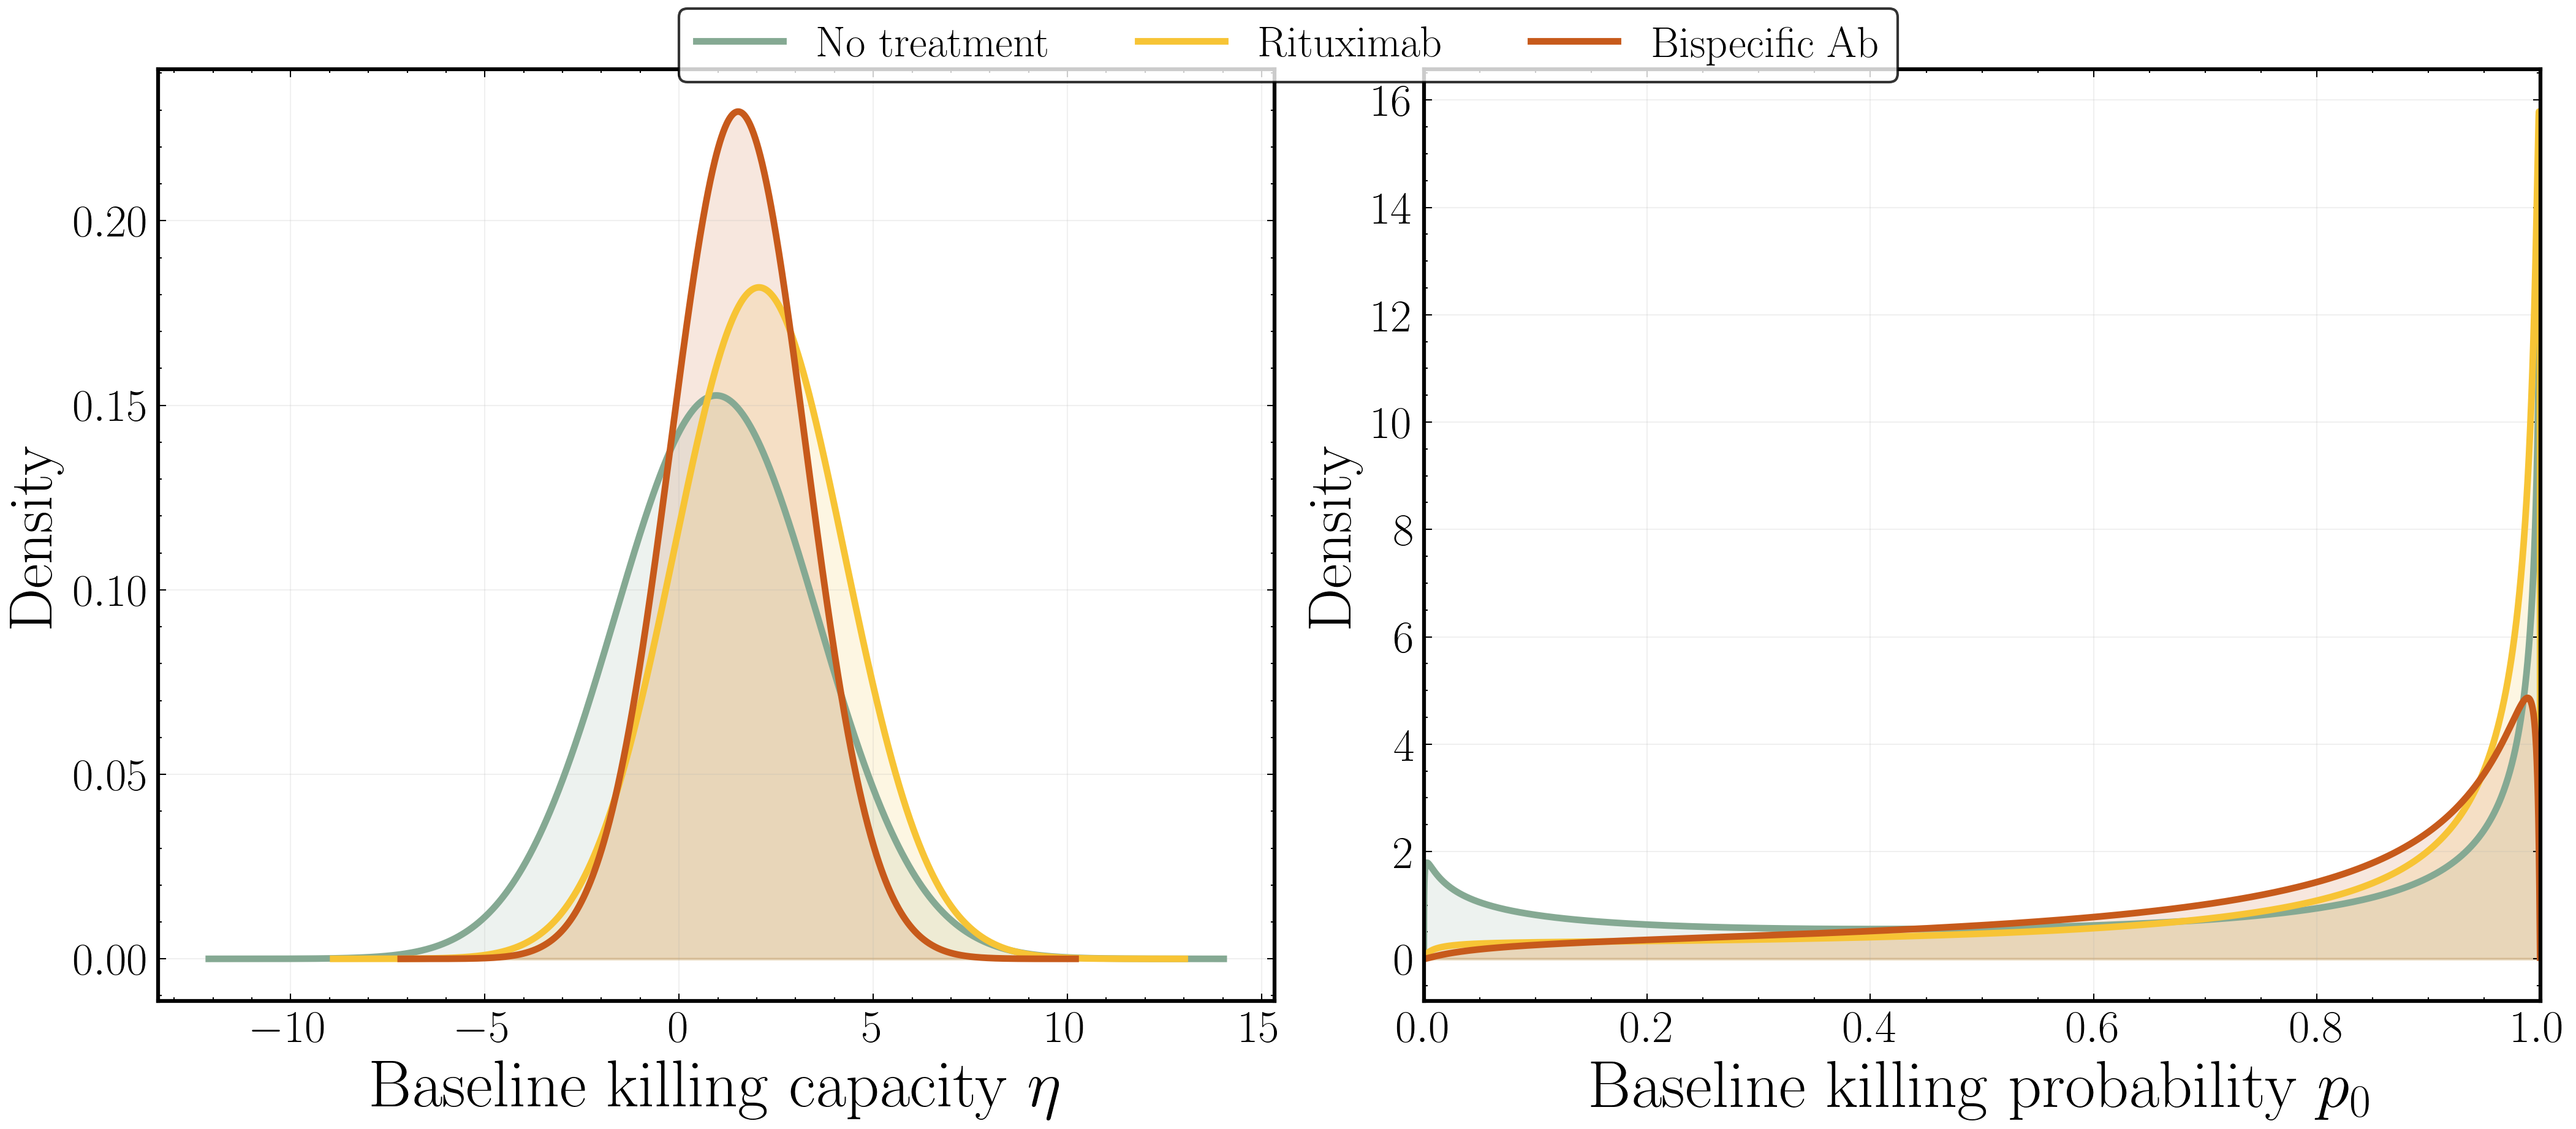

,condition,n_particles,posterior_mean_mu_eta,posterior_mean_sigma_eta,moment_matched_eta_mean,moment_matched_eta_sd
0,No treatment,60000,0.957234,2.581407,0.957234,2.613054
1,Rituximab,60000,2.057362,2.158082,2.057362,2.192525
2,Bispecific Ab,60000,1.521320,1.704670,1.521320,1.737597


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/moment_matched_eta_and_p0_distributions.svg')

In [17]:
from scipy.special import expit
from scipy.stats import norm


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.8),
    dpi=300,
    constrained_layout=True,
)

ax_eta, ax_p0 = axes
summary_rows = []

for condition in CONDITION_ORDER:
    idata = posterior_data[
        (condition, FULL_MODEL)
    ]

    posterior = (
        idata.posterior[
            ["mu_eta", "sigma_eta"]
        ]
        .stack(sample=("chain", "draw"))
    )

    mu_eta = np.asarray(
        posterior["mu_eta"].values,
        dtype=float,
    ).ravel()

    sigma_eta = np.asarray(
        posterior["sigma_eta"].values,
        dtype=float,
    ).ravel()

    keep = (
        np.isfinite(mu_eta)
        & np.isfinite(sigma_eta)
        & (sigma_eta >= 0)
    )

    mu_eta = mu_eta[keep]
    sigma_eta = sigma_eta[keep]

    # ------------------------------------------------------
    # Option 1: plug-in distribution
    # ------------------------------------------------------
    plugin_mu = float(
        np.mean(mu_eta)
    )

    plugin_sigma = float(
        np.mean(sigma_eta)
    )

    # ------------------------------------------------------
    # Option 2: moment-matched distribution
    # ------------------------------------------------------
    # Includes both population variability and uncertainty
    # in the posterior of mu_eta.
    matched_mu = float(
        np.mean(mu_eta)
    )

    matched_variance = float(
        np.mean(sigma_eta**2)
        + np.var(mu_eta)
    )

    matched_sigma = float(
        np.sqrt(matched_variance)
    )

    # Choose which approximation to plot.
    # Recommended: moment-matched values.
    eta_mean = matched_mu
    eta_sd = matched_sigma

    eta_grid = np.linspace(
        eta_mean - 5 * eta_sd,
        eta_mean + 5 * eta_sd,
        1200,
    )

    eta_density = norm.pdf(
        eta_grid,
        loc=eta_mean,
        scale=eta_sd,
    )

    # Transform eta distribution to p0 = sigmoid(eta).
    p0_grid = expit(
        eta_grid
    )

    p0_density = (
        eta_density
        / (
            p0_grid
            * (1.0 - p0_grid)
        )
    )

    color = CONDITION_COLORS[
        condition
    ]

    ax_eta.fill_between(
        eta_grid,
        eta_density,
        color=color,
        alpha=0.14,
    )

    ax_eta.plot(
        eta_grid,
        eta_density,
        color=color,
        linewidth=2.6,
        label=condition,
    )

    ax_p0.fill_between(
        p0_grid,
        p0_density,
        color=color,
        alpha=0.14,
    )

    ax_p0.plot(
        p0_grid,
        p0_density,
        color=color,
        linewidth=2.6,
        label=condition,
    )

    summary_rows.append(
        {
            "condition": condition,
            "n_particles": mu_eta.size,
            "posterior_mean_mu_eta": plugin_mu,
            "posterior_mean_sigma_eta": plugin_sigma,
            "moment_matched_eta_mean": matched_mu,
            "moment_matched_eta_sd": matched_sigma,
        }
    )

ax_eta.set_xlabel(
    r"Baseline killing capacity $\eta$",
    fontsize=26,
)

ax_eta.set_ylabel(
    "Density",
    fontsize=24,
)

ax_p0.set_xlabel(
    r"Baseline killing probability $p_0$",
    fontsize=26,
)

ax_p0.set_ylabel(
    "Density",
    fontsize=24,
)

ax_p0.set_xlim(
    0,
    1,
)

for ax in axes:
    ax.tick_params(
        axis="both",
        labelsize=18,
    )

    ax.grid(
        alpha=0.18,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

handles, labels = (
    ax_eta.get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=len(CONDITION_ORDER),
    frameon=True,
    edgecolor="black",
    fontsize=17,
)

out_path = (
    FIGURE_ROOT
    / "moment_matched_eta_and_p0_distributions.svg"
)

fig.savefig(
    out_path,
    format="svg",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

expectation_summary = pd.DataFrame(
    summary_rows
)

display(expectation_summary)

out_path

/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_25280/4267170508.py:183: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_joint.legend(frameon=True, fontsize=16)


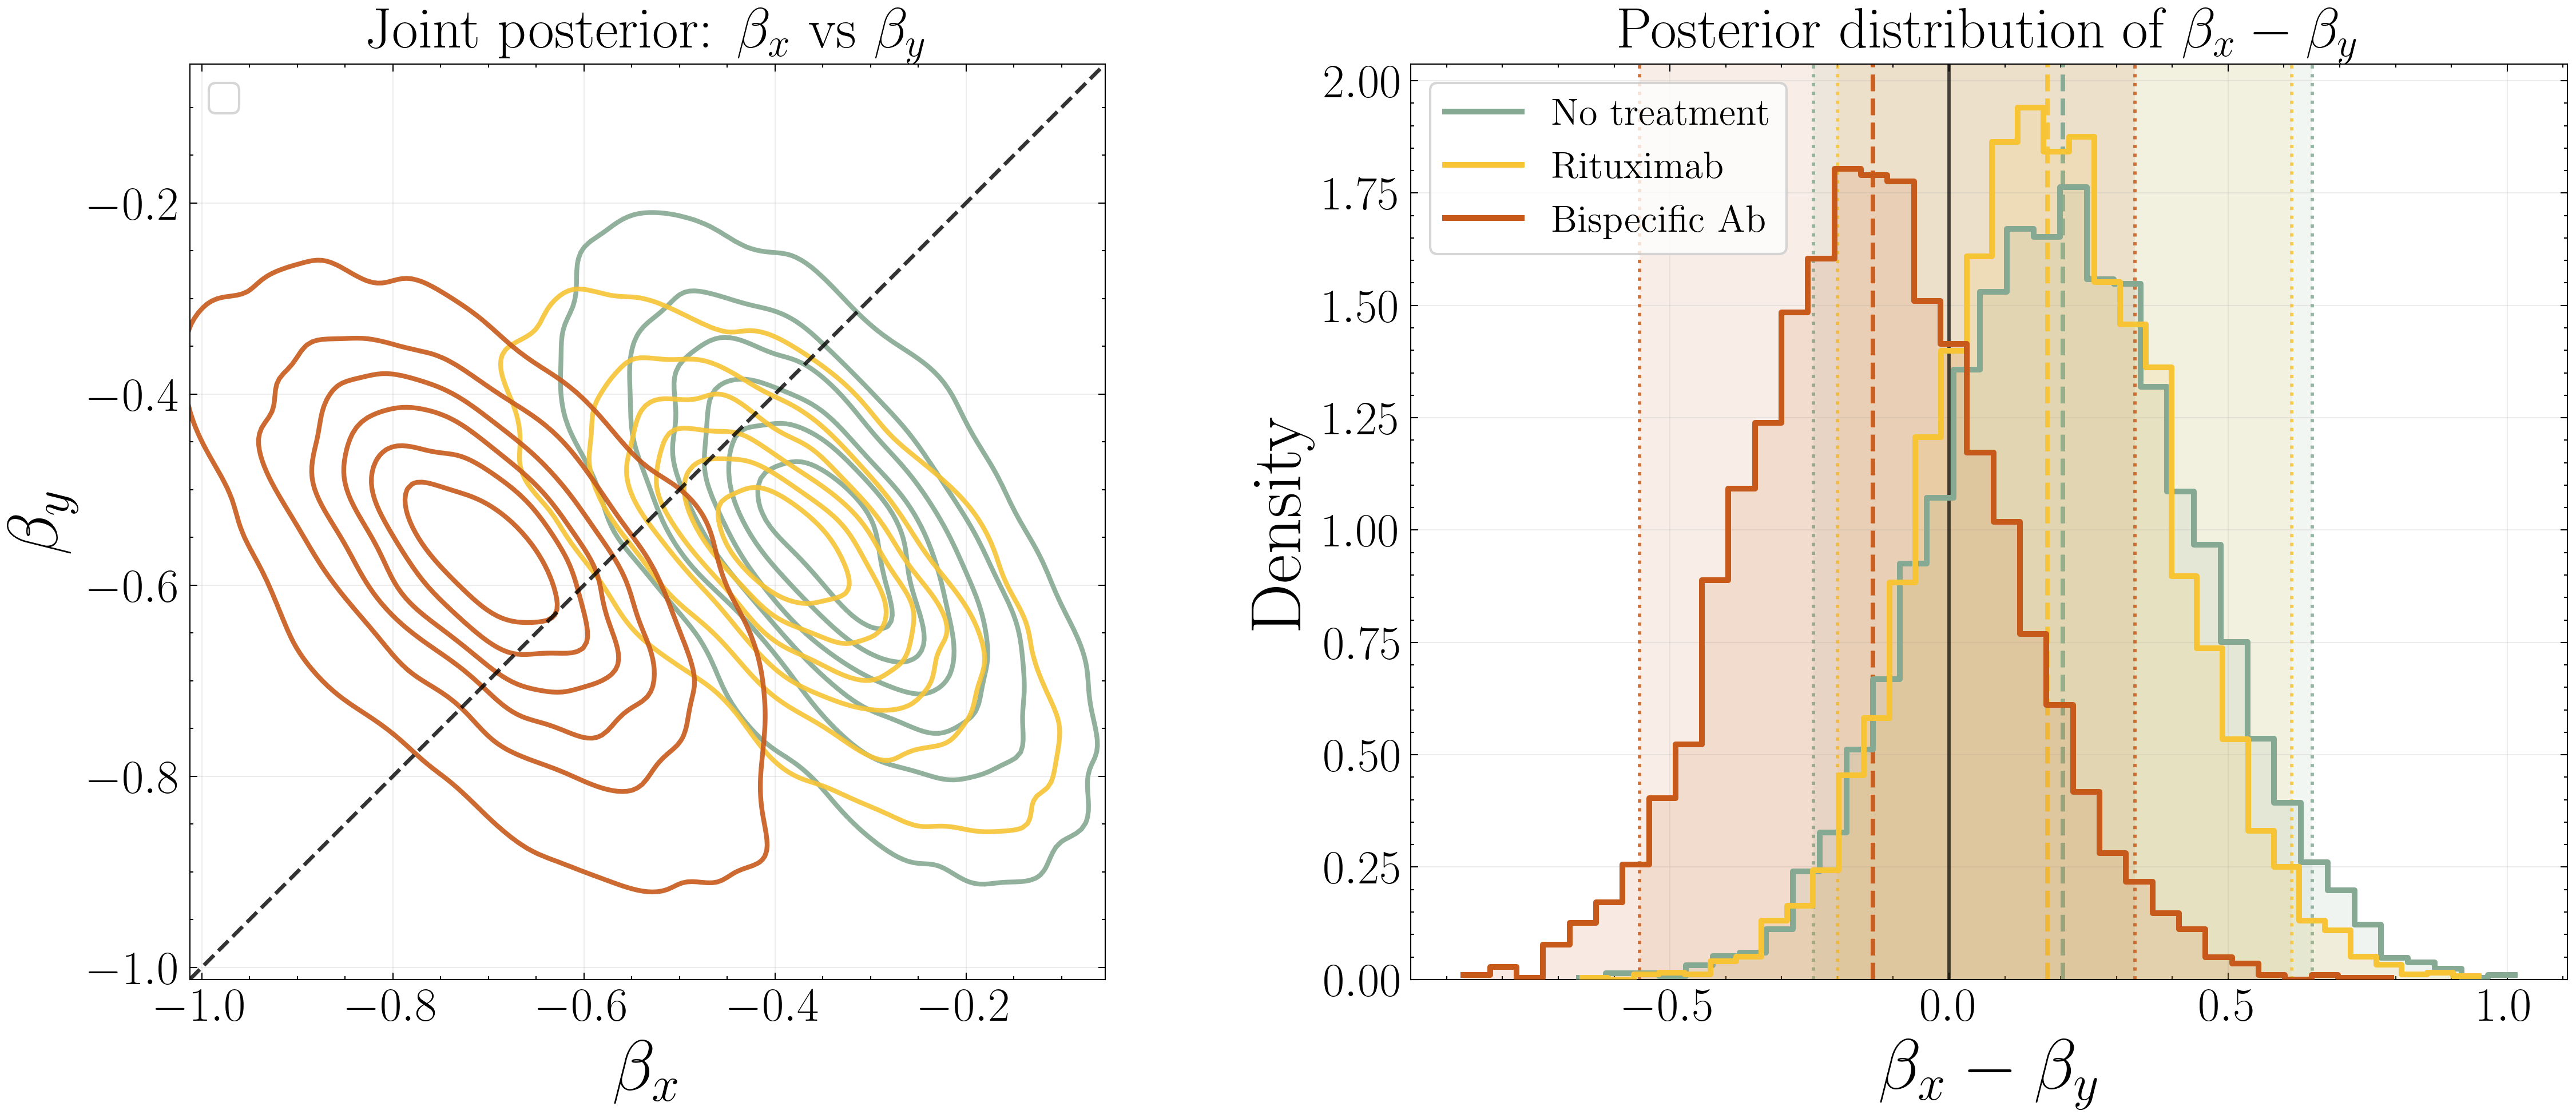

,condition,mean,median,std,hdi_2.5%,hdi_97.5%,p_beta_x_minus_beta_y_gt_0
0,No treatment,0.206464,0.203705,0.229717,-0.243327,0.651122,0.815667
1,Rituximab,0.180083,0.176189,0.207193,-0.200234,0.613573,0.806500
2,Bispecific Ab,-0.131253,-0.136699,0.225434,-0.554596,0.332920,0.275500


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/beta_x_beta_y_joint_and_difference_hdi.svg')

In [18]:
def beta_xy_posterior_frame(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    sample_size: int = 6000,
    seed: int = 23,
) -> pd.DataFrame:
    rows = []
    rng = np.random.default_rng(seed)

    for condition in conditions:
        key = (condition, model_name)

        if key not in posterior_data:
            continue

        idata = posterior_data[key]

        if "beta_x" not in idata.posterior or "beta_y" not in idata.posterior:
            continue

        beta_x = idata.posterior["beta_x"].stack(sample=("chain", "draw")).values.ravel()
        beta_y = idata.posterior["beta_y"].stack(sample=("chain", "draw")).values.ravel()

        beta_x = np.asarray(beta_x, dtype=float)
        beta_y = np.asarray(beta_y, dtype=float)

        keep = np.isfinite(beta_x) & np.isfinite(beta_y)
        beta_x = beta_x[keep]
        beta_y = beta_y[keep]

        if sample_size is not None and beta_x.size > sample_size:
            idx = rng.choice(beta_x.size, sample_size, replace=False)
            beta_x = beta_x[idx]
            beta_y = beta_y[idx]

        rows.append(
            pd.DataFrame(
                {
                    "condition": condition,
                    "beta_x": beta_x,
                    "beta_y": beta_y,
                    "beta_x_minus_beta_y": beta_x - beta_y,
                }
            )
        )

    if not rows:
        return pd.DataFrame(columns=["condition", "beta_x", "beta_y", "beta_x_minus_beta_y"])

    return pd.concat(rows, ignore_index=True)


def plot_beta_xy_joint_and_difference(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    figure_root: Path = FIGURE_ROOT,
    sample_size: int = 6000,
    bins: int = 35,
    hdi_prob: float = 0.95,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame, pd.DataFrame]:
    beta_df = beta_xy_posterior_frame(
        posterior_data,
        model_name=model_name,
        conditions=conditions,
        sample_size=sample_size,
    )

    if beta_df.empty:
        return None, beta_df, pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=300, constrained_layout=True)
    ax_joint, ax_diff = axes

    lim_values = beta_df[["beta_x", "beta_y"]].to_numpy().ravel()
    lo, hi = np.nanpercentile(lim_values, [0.5, 99.5])
    pad = 0.08 * (hi - lo)
    lo, hi = lo - pad, hi + pad

    summary_rows = []

    for condition in conditions:
        sub = beta_df[beta_df["condition"] == condition]

        if sub.empty:
            continue

        color = colors.get(condition, "black")
        diff = sub["beta_x_minus_beta_y"].to_numpy(dtype=float)

        hdi_low, hdi_high = az.hdi(diff, hdi_prob=hdi_prob)
        mean = float(np.mean(diff))
        median = float(np.median(diff))
        std = float(np.std(diff, ddof=1))

        summary_rows.append(
            {
                "condition": condition,
                "mean": mean,
                "median": median,
                "std": std,
                f"hdi_{(1 - hdi_prob) / 2:.1%}": float(hdi_low),
                f"hdi_{1 - (1 - hdi_prob) / 2:.1%}": float(hdi_high),
                "p_beta_x_minus_beta_y_gt_0": float(np.mean(diff > 0)),
            }
        )

        sns.kdeplot(
            data=sub,
            x="beta_x",
            y="beta_y",
            ax=ax_joint,
            color=color,
            levels=7,
            linewidths=2.0,
            fill=False,
            alpha=0.9,
            label=condition,
        )

        ax_diff.axvspan(
            hdi_low,
            hdi_high,
            color=color,
            alpha=0.10,
            linewidth=0,
            zorder=0,
        )

        sns.histplot(
            diff,
            bins=bins,
            stat="density",
            element="step",
            fill=True,
            alpha=0.12,
            color=color,
            ax=ax_diff,
            linewidth=0,
            zorder=2,
        )
        sns.histplot(
            diff,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            color=color,
            ax=ax_diff,
            linewidth=2.4,
            label=condition,
            zorder=3,
        )

        ax_diff.axvline(median, color=color, linewidth=1.9, linestyle="--", alpha=0.95)
        ax_diff.axvline(hdi_low, color=color, linewidth=1.4, linestyle=":", alpha=0.85)
        ax_diff.axvline(hdi_high, color=color, linewidth=1.4, linestyle=":", alpha=0.85)

    ax_joint.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.6, alpha=0.8)
    ax_joint.axvline(0, color="black", linewidth=1.0, alpha=0.35)
    ax_joint.axhline(0, color="black", linewidth=1.0, alpha=0.35)
    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)
    ax_joint.set_aspect("equal", adjustable="box")
    ax_joint.set_xlabel(r"$\beta_x$", fontsize=30)
    ax_joint.set_ylabel(r"$\beta_y$", fontsize=30)
    ax_joint.set_title(r"Joint posterior: $\beta_x$ vs $\beta_y$", fontsize=24)

    ax_diff.axvline(0, color="black", linewidth=1.4, alpha=0.7)
    ax_diff.set_xlabel(r"$\beta_x - \beta_y$", fontsize=30)
    ax_diff.set_ylabel("Density", fontsize=30)
    ax_diff.set_title(r"Posterior distribution of $\beta_x - \beta_y$", fontsize=24)

    for ax in axes:
        ax.tick_params(axis="both", labelsize=20)
        ax.grid(alpha=0.22)

    ax_joint.legend(frameon=True, fontsize=16)
    ax_diff.legend(frameon=True, fontsize=16)

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "beta_x_beta_y_joint_and_difference_hdi.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary_df = pd.DataFrame(summary_rows)

    return out_path, beta_df, summary_df


beta_xy_path, beta_xy_df, beta_xy_summary = plot_beta_xy_joint_and_difference(
    posterior_data,
    show=True,
)

display(beta_xy_summary)
beta_xy_path

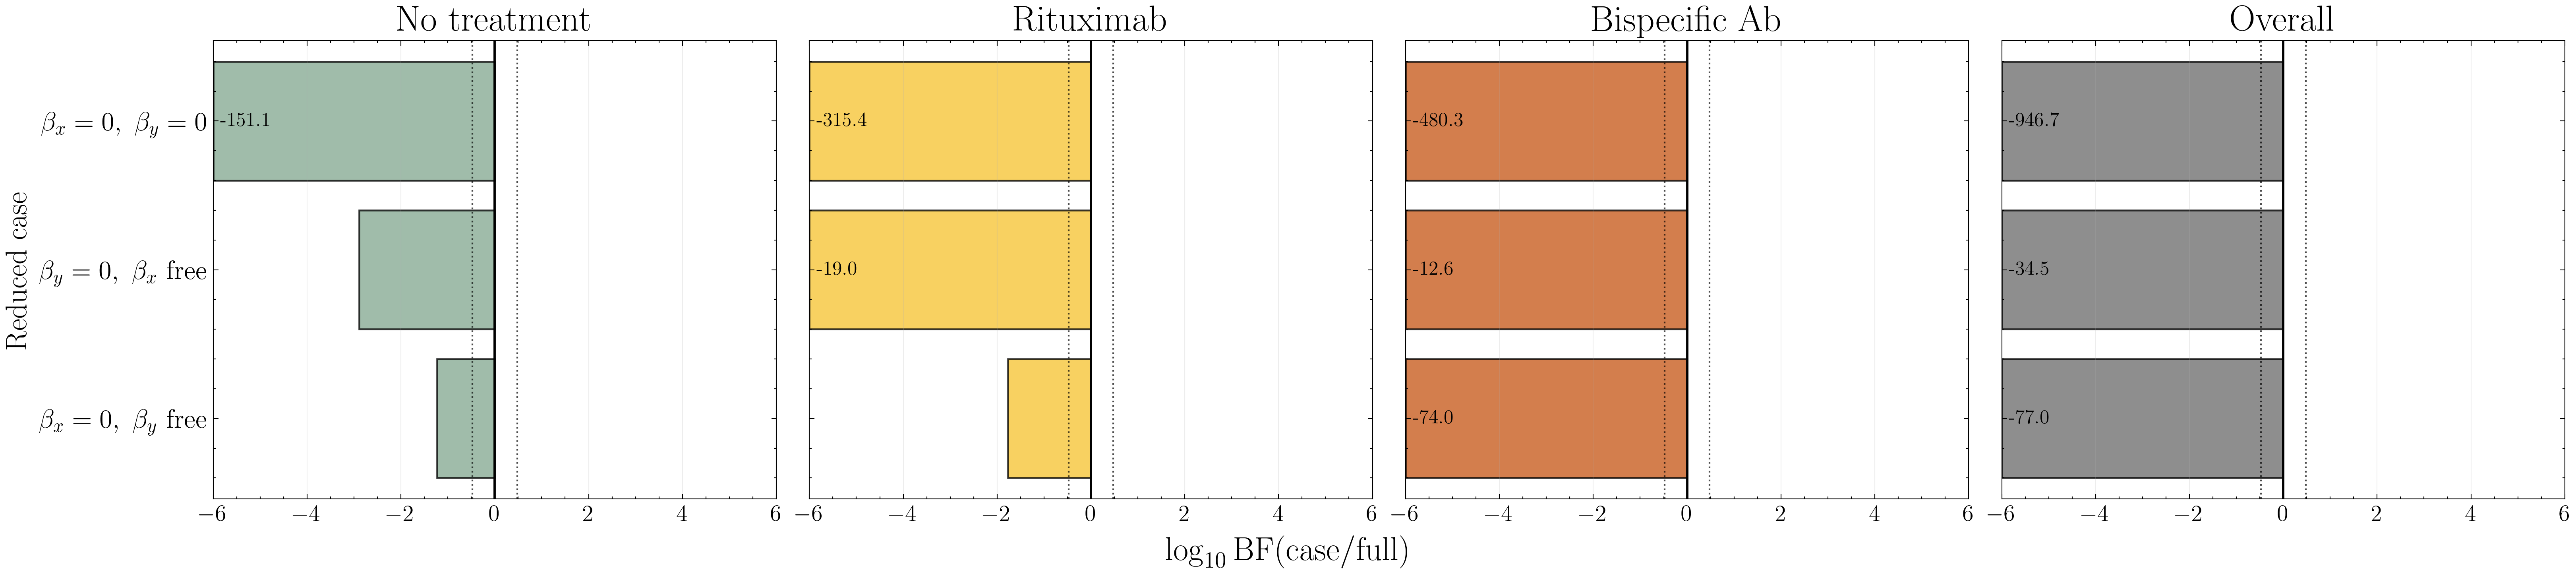

,condition,case_label,log10_case_vs_full_BF,log10_full_vs_case_BF
0,No treatment,"$\beta_x=0,\ \beta_y$ free",-1.231,1.231
1,No treatment,"$\beta_y=0,\ \beta_x$ free",-2.887,2.887
2,No treatment,"$\beta_x=0,\ \beta_y=0$",-151.110,151.110
3,Rituximab,"$\beta_x=0,\ \beta_y$ free",-1.770,1.770
4,Rituximab,"$\beta_y=0,\ \beta_x$ free",-18.976,18.976
5,Rituximab,"$\beta_x=0,\ \beta_y=0$",-315.371,315.371
6,Bispecific Ab,"$\beta_x=0,\ \beta_y$ free",-74.030,74.030
7,Bispecific Ab,"$\beta_y=0,\ \beta_x$ free",-12.638,12.638
8,Bispecific Ab,"$\beta_x=0,\ \beta_y=0$",-480.261,480.261
9,Overall,"$\beta_x=0,\ \beta_y$ free",-77.031,77.031


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_4/figures/analysis_2/history_effect_savage_dickey_log_bfs_with_overall.svg')

In [19]:
from scipy.stats import gaussian_kde, norm


CASE_ORDER = ["beta_x_zero", "beta_y_zero", "both_zero"]

CASE_LABELS = {
    "beta_x_zero": r"$\beta_x=0,\ \beta_y$ free",
    "beta_y_zero": r"$\beta_y=0,\ \beta_x$ free",
    "both_zero": r"$\beta_x=0,\ \beta_y=0$",
}


def _posterior_samples(idata: az.InferenceData, var_name: str) -> np.ndarray:
    values = (
        idata.posterior[var_name]
        .stack(sample=("chain", "draw"))
        .values
        .ravel()
        .astype(float)
    )
    return values[np.isfinite(values)]


def _paired_posterior_samples(
    idata: az.InferenceData,
    x_name: str,
    y_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    posterior = idata.posterior[[x_name, y_name]].stack(sample=("chain", "draw"))
    x = np.asarray(posterior[x_name].values, dtype=float).ravel()
    y = np.asarray(posterior[y_name].values, dtype=float).ravel()
    keep = np.isfinite(x) & np.isfinite(y)
    return x[keep], y[keep]


def _kde_log_density_1d(samples: np.ndarray, ref: float = 0.0) -> float:
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if samples.size < 3 or np.std(samples) == 0:
        return np.nan

    kde = gaussian_kde(samples)

    if hasattr(kde, "logpdf"):
        return float(kde.logpdf([ref])[0])

    density = float(kde([ref])[0])
    return float(np.log(density)) if density > 0 else -np.inf


def _kde_log_density_2d(x: np.ndarray, y: np.ndarray, ref: tuple[float, float] = (0.0, 0.0)) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]

    if x.size < 4 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    kde = gaussian_kde(np.vstack([x, y]))
    point = np.array([[ref[0]], [ref[1]]], dtype=float)

    if hasattr(kde, "logpdf"):
        return float(kde.logpdf(point)[0])

    density = float(kde(point)[0])
    return float(np.log(density)) if density > 0 else -np.inf


def history_effect_savage_dickey_log_bfs(
    posterior_data: dict,
    *,
    model_name: str = FULL_MODEL,
    conditions: Sequence[str] = CONDITION_ORDER,
    beta_prior_sd: float = 1.0,
) -> pd.DataFrame:
    rows = []

    log_prior_beta0 = float(norm.logpdf(0.0, loc=0.0, scale=beta_prior_sd))
    log_prior_both0 = 2.0 * log_prior_beta0

    for condition in conditions:
        key = (condition, model_name)

        if key not in posterior_data:
            continue

        idata = posterior_data[key]

        beta_x = _posterior_samples(idata, "beta_x")
        beta_y = _posterior_samples(idata, "beta_y")
        beta_x_pair, beta_y_pair = _paired_posterior_samples(idata, "beta_x", "beta_y")

        case_specs = [
            ("beta_x_zero", _kde_log_density_1d(beta_x, 0.0), log_prior_beta0),
            ("beta_y_zero", _kde_log_density_1d(beta_y, 0.0), log_prior_beta0),
            ("both_zero", _kde_log_density_2d(beta_x_pair, beta_y_pair, (0.0, 0.0)), log_prior_both0),
        ]

        for case, log_post_density, log_prior_density in case_specs:
            log10_case_vs_full = (log_post_density - log_prior_density) / np.log(10.0)

            rows.append(
                {
                    "condition": condition,
                    "case": case,
                    "case_label": CASE_LABELS[case],
                    "posterior_log_density_at_null": log_post_density,
                    "prior_log_density_at_null": log_prior_density,
                    "log10_case_vs_full_BF": log10_case_vs_full,
                    "log10_full_vs_case_BF": -log10_case_vs_full,
                }
            )

    return pd.DataFrame(rows)


def overall_history_effect_log_bfs(
    bf_df: pd.DataFrame,
    *,
    conditions: Sequence[str] = CONDITION_ORDER,
) -> pd.DataFrame:
    rows = []

    for case in CASE_ORDER:
        sub = bf_df[bf_df["case"] == case]

        rows.append(
            {
                "condition": "Overall",
                "case": case,
                "case_label": CASE_LABELS[case],
                "posterior_log_density_at_null": np.nan,
                "prior_log_density_at_null": np.nan,
                "log10_case_vs_full_BF": float(sub["log10_case_vs_full_BF"].sum()),
                "log10_full_vs_case_BF": float(sub["log10_full_vs_case_BF"].sum()),
            }
        )

    return pd.DataFrame(rows)


def plot_history_effect_savage_dickey_log_bfs(
    bf_df: pd.DataFrame,
    *,
    figure_root: Path = FIGURE_ROOT,
    conditions: Sequence[str] = CONDITION_ORDER,
    colors: dict[str, str] = CONDITION_COLORS,
    clip_log10_bf: float = 6.0,
    show: bool = False,
) -> tuple[Path | None, pd.DataFrame]:
    if bf_df.empty:
        return None, pd.DataFrame()

    overall_df = overall_history_effect_log_bfs(bf_df, conditions=conditions)
    plot_df = pd.concat([bf_df, overall_df], ignore_index=True)

    panels = list(conditions) + ["Overall"]

    fig, axes = plt.subplots(
        1,
        len(panels),
        figsize=(5.4 * len(panels), 4.8),
        dpi=300,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, panel in zip(axes, panels):
        sub = (
            plot_df[plot_df["condition"] == panel]
            .set_index("case")
            .loc[CASE_ORDER]
            .reset_index()
        )

        raw_values = sub["log10_case_vs_full_BF"].to_numpy(dtype=float)
        shown_values = np.clip(raw_values, -clip_log10_bf, clip_log10_bf)
        y = np.arange(len(sub))

        color = colors.get(panel, "#6F6F6F")

        ax.barh(
            y,
            shown_values,
            color=color,
            alpha=0.78,
            edgecolor="black",
            linewidth=1.1,
        )

        for yi, raw, shown in zip(y, raw_values, shown_values):
            if np.isfinite(raw) and raw < -clip_log10_bf:
                ax.text(
                    -clip_log10_bf + 0.15,
                    yi,
                    f"{raw:.1f}",
                    va="center",
                    ha="left",
                    fontsize=12,
                    color="black",
                )
            elif np.isfinite(raw) and raw > clip_log10_bf:
                ax.text(
                    clip_log10_bf - 0.15,
                    yi,
                    f"{raw:.1f}",
                    va="center",
                    ha="right",
                    fontsize=12,
                    color="black",
                )

        ax.axvline(0, color="black", linewidth=1.4)
        ax.axvline(np.log10(3), color="black", linestyle=":", linewidth=1.0, alpha=0.7)
        ax.axvline(-np.log10(3), color="black", linestyle=":", linewidth=1.0, alpha=0.7)

        ax.set_title(panel, fontsize=22)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["case_label"], fontsize=16)
        ax.invert_yaxis()
        ax.set_xlim(-clip_log10_bf, clip_log10_bf)
        ax.tick_params(axis="x", labelsize=14)
        ax.grid(axis="x", alpha=0.22)

    axes[0].set_ylabel("Reduced case", fontsize=18)

    fig.supxlabel(
        r"$\log_{10}\mathrm{BF}(\mathrm{case}/\mathrm{full})$",
        fontsize=20,
    )

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / "history_effect_savage_dickey_log_bfs_with_overall.svg"
    fig.savefig(out_path, format="svg", bbox_inches="tight", transparent=True)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return out_path, overall_df


history_bf_df = history_effect_savage_dickey_log_bfs(
    posterior_data,
    beta_prior_sd=1.0,
)

history_bf_path, history_bf_overall_df = plot_history_effect_savage_dickey_log_bfs(
    history_bf_df,
    clip_log10_bf=6.0,
    show=True,
)

history_bf_display = pd.concat([history_bf_df, history_bf_overall_df], ignore_index=True)

display(
    history_bf_display[
        [
            "condition",
            "case_label",
            "log10_case_vs_full_BF",
            "log10_full_vs_case_BF",
        ]
    ].round(3)
)

history_bf_path